# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J2212'
j2212 = pd.read_csv(galname + '.csv')

wave = j2212['wave'].to_numpy()
flux = j2212['flux'].to_numpy()
err = j2212['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise


# Main lines

# [NII]6548 + Ha + [NII]6584
select = (wave > 7685) * (wave < 7780)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5875) * (wave < 5920)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 8600) * (wave < 8650)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7880) * (wave < 7950)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6750) * (wave < 6800)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5705) * (wave < 5745)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 5085) * (wave < 5135)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4800) * (wave < 4860)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4770) * (wave < 4820)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 4375) * (wave < 4405)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])


# High ionization lines

# No [SIII]9532 and [SIII]9069 detections

# [Ar III]7135
select = (wave > 8350) * (wave < 8450)
ariii_7135 = SpecPiece('ariii_7135', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 7390) * (wave < 7460)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5820) * (wave < 5855)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# HeII4686
select = (wave > 5480) * (wave < 5560)
heii_4686 = SpecPiece('heii4686', wave[select], flux[select], err[select])

# [Fe III]4658
select = (wave > 5450) * (wave < 5525)
feiii_4658 = SpecPiece('feiii_4658', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 5125) * (wave < 5150)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4535) * (wave < 4575)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

Text(0.5, 1.0, 'J2212')

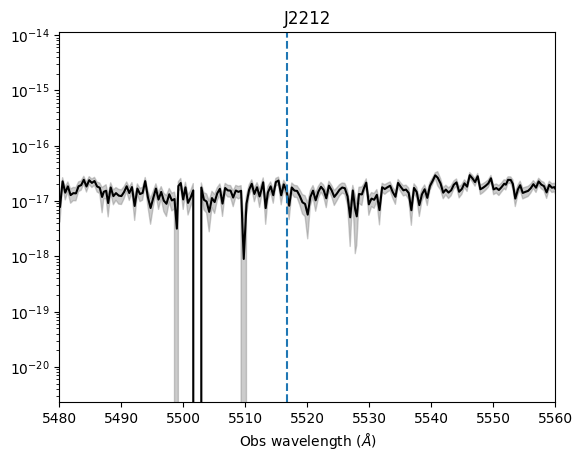

In [3]:
plt.plot(wave, flux, color='black')
plt.fill_between(wave, flux-err, flux+err, color='gray', alpha=0.4)
plt.xlim(5480, 5560)
#plt.ylim(1e-18, 1e-16)
plt.axvline((1 + z_BN[igal])*wave_cat['HeII4685'], ls='--')
plt.yscale('log')
plt.xlabel('Obs wavelength ($\AA$)')
plt.title('J2212')
#plt.savefig('/home/benjamin/Documents/analogs/HeIIJ2212.pdf', bbox_inches='tight')

---

# Two component model fit for [OIII] 4959

In [4]:
m = arc_slope23
n = arc_intercept23

sigma_arc_4959 = (m * wave_cat['[OIII]4959']*(1 + z_BN[igal])) + n

# [OIII]4959

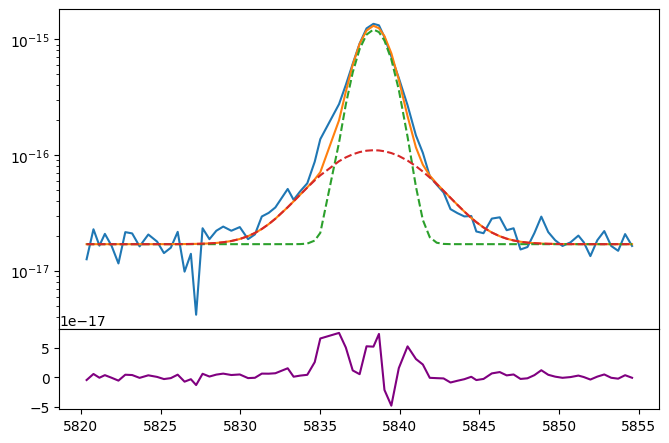

In [5]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 1.7e-17

oiiib_nar = gaussian(oiii_4959.wavelength, 300e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.0)
oiiib_brd = gaussian(oiii_4959.wavelength, 70e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=3.0)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [6]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=1.0, min=0.)
params_oiii_4959.add('sigma_brd', value=3.0, min=0.)
params_oiii_4959.add('Oiiib_nar', value=300e-17, min=0.)
params_oiii_4959.add('Oiiib_brd', value=70e-17, min=0.)
params_oiii_4959.add('bkg', value=1.7e-17, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [7]:
np.random.seed(2212)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 139.10it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [120.81025976  52.1730324  213.26792719 206.34685597 216.90788073
 215.11795278 147.55795922]


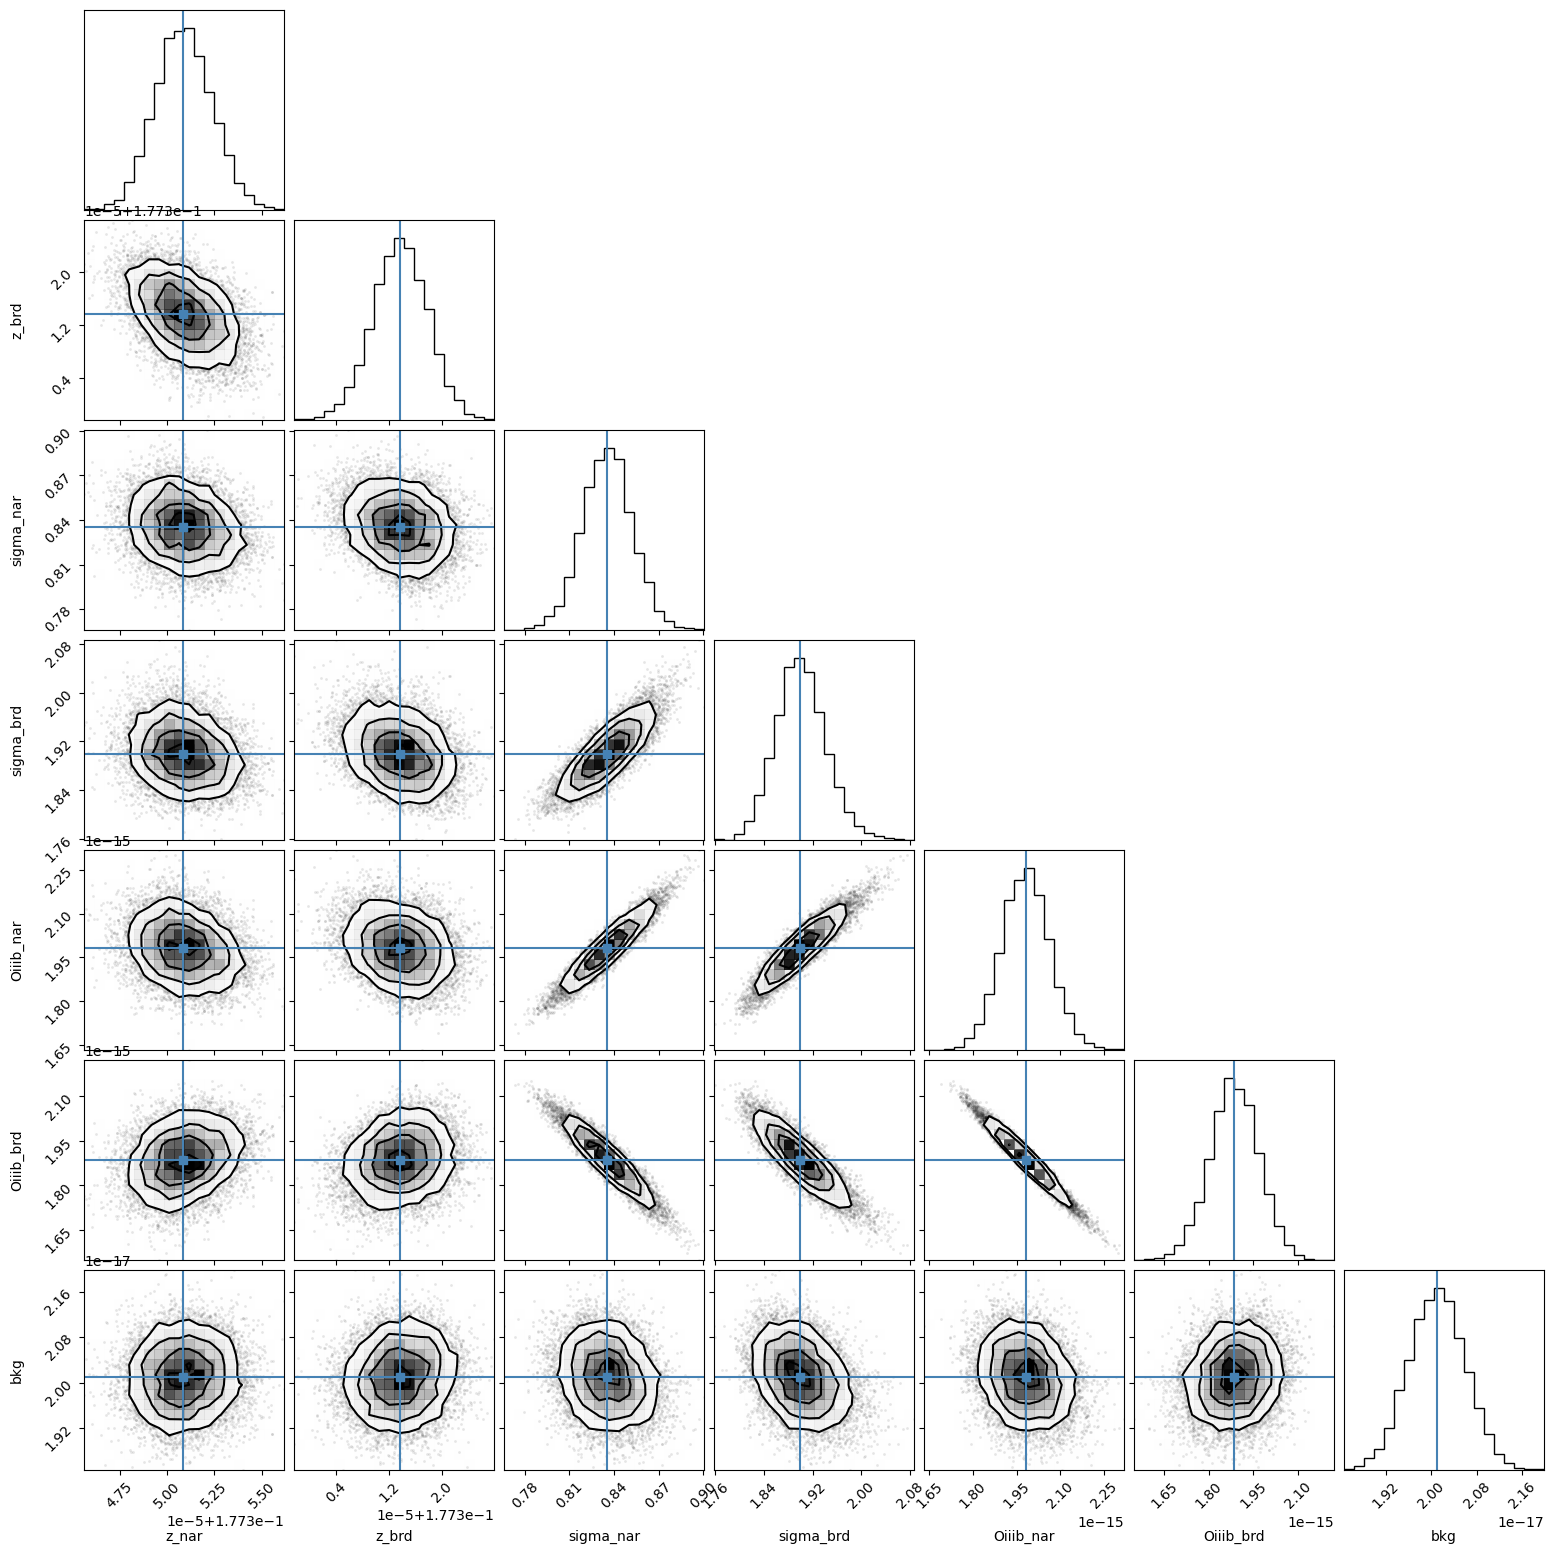

In [8]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [9]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735087,1.5110e-06,(0.00%),0.17735,-inf,inf,True
z_brd,0.17731371,4.1222e-06,(0.00%),0.17735,-inf,inf,True
sigma_nar,0.83561649,0.01653130,(1.98%),1.0,0.00000000,inf,True
sigma_brd,1.89954562,0.04050645,(2.13%),3.0,0.00000000,inf,True
Oiiib_nar,1.9816e-15,8.2063e-17,(4.14%),3e-15,0.00000000,inf,True
Oiiib_brd,1.8864e-15,8.1074e-17,(4.30%),7e-16,0.00000000,inf,True
bkg,2.0101e-17,4.9832e-19,(2.48%),1.7e-17,0.00000000,inf,True


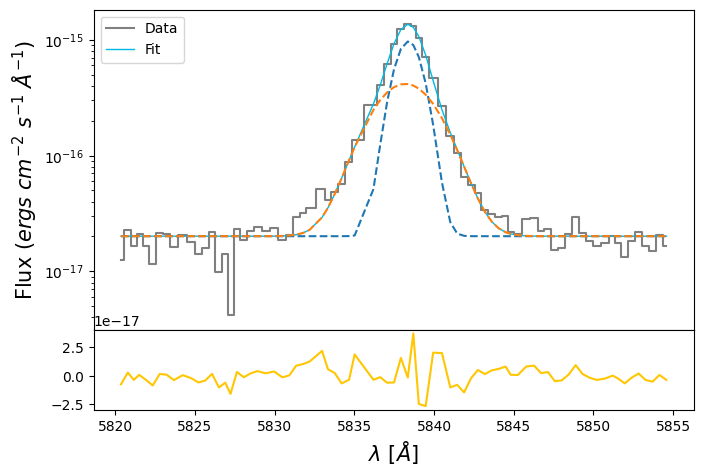

In [10]:
oiiib_nar_flux = out_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out_oiii_4959.flatchain.Oiiib_brd.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
bkg_oiii_4959_std = out_oiii_4959.flatchain.bkg.std()

z_nar_oiii_4959 = out_oiii_4959.flatchain.z_nar.mean()
z_nar_oiii_4959_std = out_oiii_4959.flatchain.z_nar.std()

z_brd_oiii_4959 = out_oiii_4959.flatchain.z_brd.mean()
z_brd_oiii_4959_std = out_oiii_4959.flatchain.z_brd.std()

sigma_nar_oiii_4959 = out_oiii_4959.flatchain.sigma_nar.mean()
sigma_nar_oiii_4959_std = out_oiii_4959.flatchain.sigma_nar.std()

sigma_brd_oiii_4959 = out_oiii_4959.flatchain.sigma_brd.mean()
sigma_brd_oiii_4959_std = out_oiii_4959.flatchain.sigma_brd.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [11]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = upy.sqrt((ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)**2) - (sigma_arc_4959**2))
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2))

In [12]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic,  wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [13]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.1774+/-0.0000


In [14]:
# Velocities
vel = {'galname': galname,
       'z_nar': z_nar_oiii_4959,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}

vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog.csv')

Existent catalog (.csv) file.
Existent data for J2212, overwriting...
Done.


---

# HeII 4686

In [15]:
sigma_arc_4685 = (m * wave_cat['HeII4685']*(1 + z_BN[igal])) + n

sigma_nar_4685 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4685**2))
sigma_brd_4685 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4685**2))

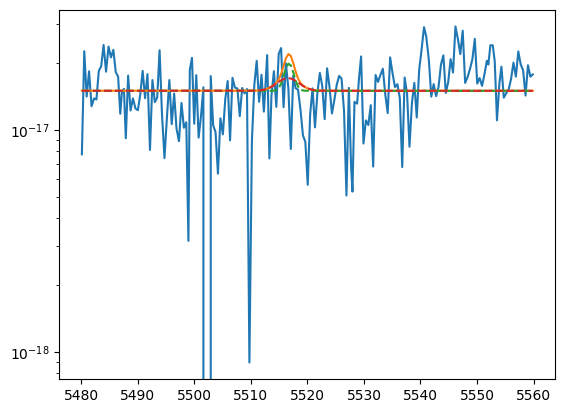

In [16]:
plt.plot(heii_4686.wavelength, heii_4686.flux)
bkg = 1.5e-17

heii4685_nar = gaussian(heii_4686.wavelength, 1e-17, wave_cat['HeII4685'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, 1e-17, wave_cat['HeII4685'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

plt.plot(heii_4686.wavelength, heii4685 + bkg)
plt.plot(heii_4686.wavelength, heii4685_nar + bkg, ls='--')
plt.plot(heii_4686.wavelength, heii4685_brd + bkg, ls='--')
plt.yscale('log')

In [17]:
params_4685 = Parameters()
params_4685.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_4685.add('z_ratio', value=z_ratio, vary=False)
params_4685.add('sigma_heii4685_nar', value=upy.nominal_values(sigma_nar_4685), vary=False)
params_4685.add('sigma_heii4685_brd', value=upy.nominal_values(sigma_brd_4685), vary=False)
params_4685.add('Heii4685_nar', value=1e-17, min=0.)
params_4685.add('Heii4685_brd', value=1e-17, min=0.)
params_4685.add('bkg', value=1.5e-17, min=0.)

def residual_heii4685(params_4685, x, data, uncertainty):
    
    z_nar = params_4685['z_nar']
    z_brd = params_4685['z_nar'] * params_4685['z_ratio']
    sigma_heii4685_nar = params_4685['sigma_heii4685_nar']
    sigma_heii4685_brd = params_4685['sigma_heii4685_brd']
    heii4685_nar_flux = params_4685['Heii4685_nar']
    heii4685_brd_flux = params_4685['Heii4685_brd']
    bkg = params_4685['bkg']
    
    x = heii_4686.wavelength
    model = gaussian(x, heii4685_nar_flux, wave_cat['HeII4685'], z_nar, sigma_heii4685_nar) + \
            gaussian(x, heii4685_brd_flux, wave_cat['HeII4685'], z_brd, sigma_heii4685_brd)
    return (model + bkg - heii_4686.flux) / heii_4686.noise

In [18]:
np.random.seed(2212)
out_heii4685 = minimize(residual_heii4685, params_4685, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 150.91it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [37.39768939 67.82743173 73.23475454 63.25894306]


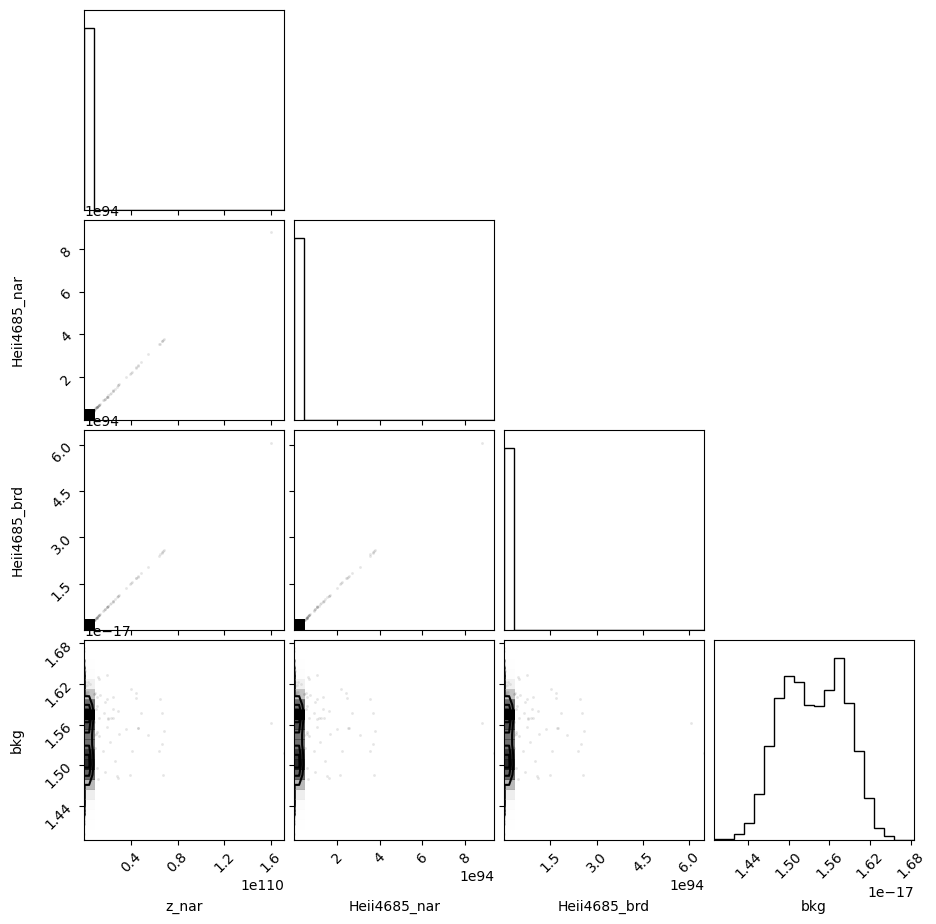

In [19]:
corner.corner(out_heii4685.flatchain, labels=out_heii4685.var_names);

In [20]:
out_heii4685.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,8.9670e+66,1.3458e+94,(150078408792844421358155726848.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_heii4685_nar,0.81362069,,,0.8136206875448154,-inf,inf,False
sigma_heii4685_brd,1.89173035,,,1.8917303543576758,-inf,inf,False
Heii4685_nar,7.6912e+51,6.3317e+78,(82323214614915697885073899520.00%),1e-17,0.00000000,inf,True
Heii4685_brd,3.0230e+51,5.1371e+78,(169934633894494577009295884288.00%),1e-17,0.00000000,inf,True
bkg,1.5367e-17,4.9596e-19,(3.23%),1.5e-17,0.00000000,inf,True


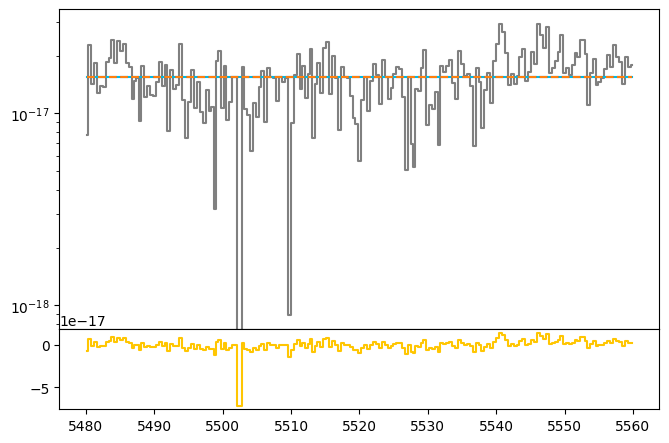

In [21]:
heii4685_nar_flux = out_heii4685.flatchain.Heii4685_nar.mean()
heii4685_nar_std = out_heii4685.flatchain.Heii4685_nar.std()

heii4685_brd_flux = out_heii4685.flatchain.Heii4685_brd.mean()
heii4685_brd_std = out_heii4685.flatchain.Heii4685_brd.std()

z_heii4685 = out_heii4685.flatchain.z_nar.mean()
z_heii4685_std = out_heii4685.flatchain.z_nar.std()

bkg_heii4685 = out_heii4685.flatchain.bkg.mean()
bkg_heii4685_std = out_heii4685.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(heii_4686.wavelength, heii_4686.flux, color='gray', label='Data', where='mid')

heii4685_nar = gaussian(heii_4686.wavelength, heii4685_nar_flux, wave_cat['HeII4685'], z_heii4685, upy.nominal_values(sigma_nar_4685))
heii4685_brd = gaussian(heii_4686.wavelength, heii4685_brd_flux, wave_cat['HeII4685'], z_heii4685 * z_ratio, upy.nominal_values(sigma_brd_4685))

heii4685 = heii4685_nar + heii4685_brd

ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685, color=c[0])
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_nar, ls='--')
ax.plot(heii_4686.wavelength, bkg_heii4685 + heii4685_brd, ls='--')
ax.set_yscale('log')
ax1.step(heii_4686.wavelength, heii_4686.flux - bkg_heii4685 - heii4685, color=c[3], where='mid')

In [22]:
# EW
EW_heii4685_nar = ufloat(heii4685_nar_flux, heii4685_nar_std) / ufloat(bkg_heii4685, bkg_heii4685_std)
EW_heii4685_brd = ufloat(heii4685_brd_flux, heii4685_brd_std) / ufloat(bkg_heii4685, bkg_heii4685_std)
EW_heii4685 = (ufloat(heii4685_nar_flux, heii4685_nar_std) + ufloat(heii4685_brd_flux, heii4685_brd_std)) / ufloat(bkg_heii4685, bkg_heii4685_std)

In [23]:
heii4685_tot_flux = ufloat(heii4685_nar_flux, heii4685_nar_std) + ufloat(heii4685_brd_flux, heii4685_brd_std)

# [NII]6548 + H$\alpha$ + [NII]6584

In [24]:
sigma_arc_ha = (m * wave_cat['Ha']*(1 + z_BN[igal])) + n

sigma_nar_ha = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_ha**2))
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

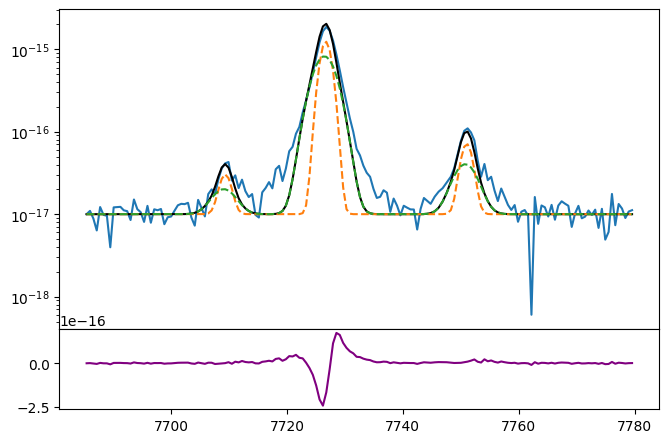

In [25]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 1e-17

ha_nar = gaussian(ha_nii.wavelength, 0.3e-14, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 0.4e-14, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 0.5e-16, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 0.5e-16, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 1.5e-16, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 1.5e-16, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
ax.set_yscale('log')

In [26]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=3.0e-15, min=0.)
params_ha_nii.add('Ha_brd', value=4.0e-15, min=0.)
params_ha_nii.add('Niia_nar', value=1.5e-16, min=0.)
params_ha_nii.add('Niia_brd', value=1.5e-16, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=1e-17, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [27]:
np.random.seed(2212)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:35<00:00, 71.40it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 60.90700376 105.62620206 107.8620433   86.62193953 100.69396927
  81.11989209  67.85777218]


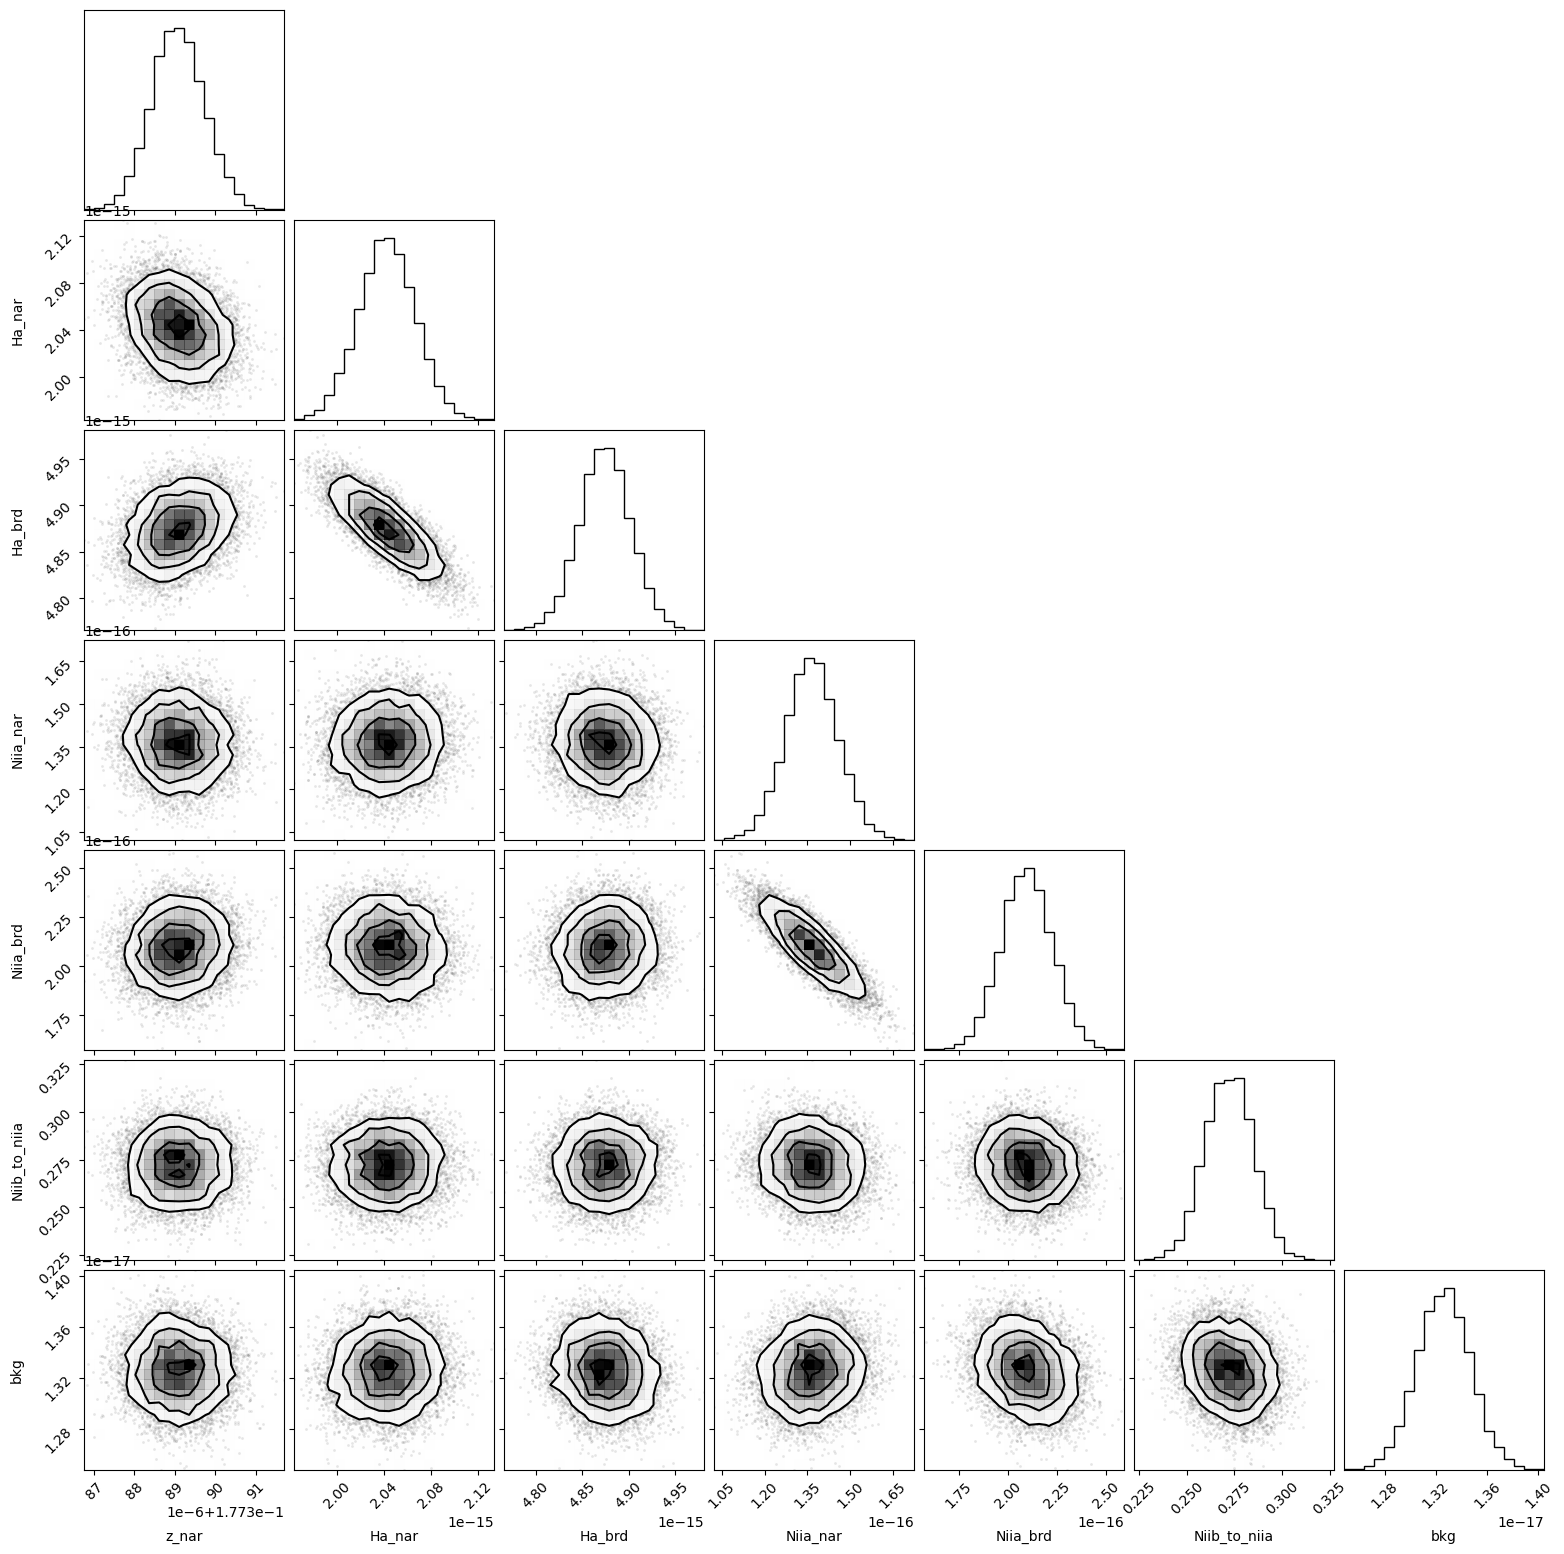

In [28]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [29]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17738907,6.5283e-07,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.97646780,,,0.9764677974304646,-inf,inf,False
sigma_brd,1.96727082,,,1.96727081760901,-inf,inf,False
Ha_nar,2.0424e-15,2.3841e-17,(1.17%),3e-15,0.00000000,inf,True
Ha_brd,4.8746e-15,2.7364e-17,(0.56%),4e-15,0.00000000,inf,True
Niia_nar,1.3648e-16,9.0991e-18,(6.67%),1.5e-16,0.00000000,inf,True
Niia_brd,2.0944e-16,1.3098e-17,(6.25%),1.5e-16,0.00000000,inf,True
Niib_to_niia,0.27222699,0.01266714,(4.65%),0.3333333333333333,0.00000000,1.00000000,True
bkg,1.3262e-17,2.0924e-19,(1.58%),1e-17,-inf,inf,True


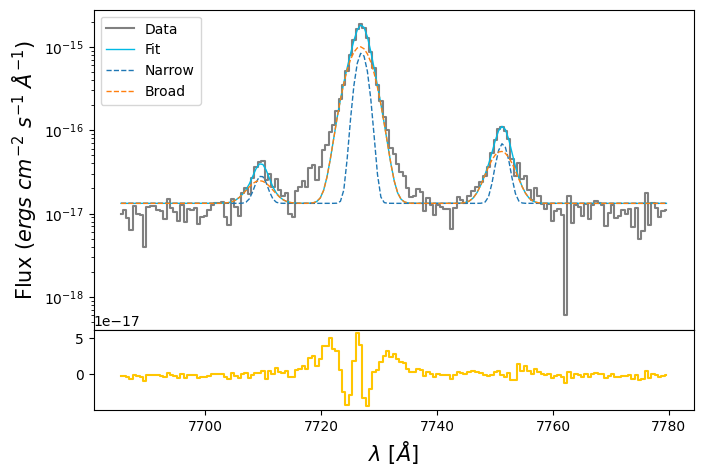

In [30]:
ha_nar_flux = out_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out_ha_nii.flatchain.Ha_nar.std()

ha_brd_flux = out_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out_ha_nii.flatchain.Ha_brd.std()

niia_nar_flux = out_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out_ha_nii.flatchain.Niia_nar.std()

niia_brd_flux = out_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out_ha_nii.flatchain.Niia_brd.std()

niib_nar_flux = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_nar_std = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).std()

niib_brd_flux = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd_std = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).std()

z_ha_nii = out_ha_nii.flatchain.z_nar.mean()
z_ha_nii_std = out_ha_nii.flatchain.z_nar.std()

bkg_ha_nii = out_ha_nii.flatchain.bkg.mean()
bkg_ha_nii_std = out_ha_nii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
#ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')

In [31]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

# [OII]7319 + [OII]7330

In [32]:
sigma_arc_7330 = (m * wave_cat['[OII]7330']*(1 + z_BN[igal])) + n

sigma_nar_7330 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7330**2))
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

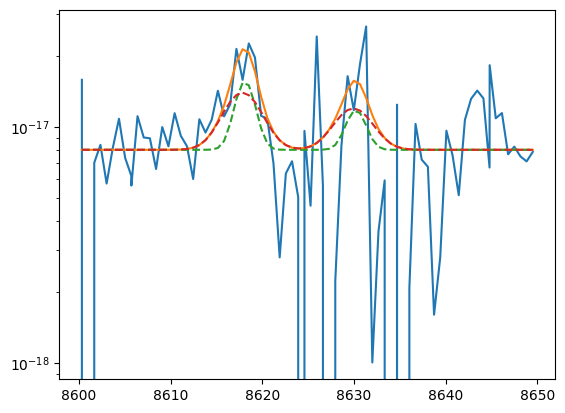

In [33]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 1e-17, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 2e-17, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 2e-17, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 3e-17, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 8e-18

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [34]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=1e-17, min=0.)
params_oii_7320.add('Oiia_brd', value=2e-17, min=0.)
params_oii_7320.add('Oiib_nar', value=2e-17, min=0.)
params_oii_7320.add('Oiib_brd', value=3e-17, min=0.)
params_oii_7320.add('bkg', value=8e-18, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [35]:
np.random.seed(2212)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.18241826 71.32260792 76.17416184 63.76222176 62.16513441 61.9542763 ]


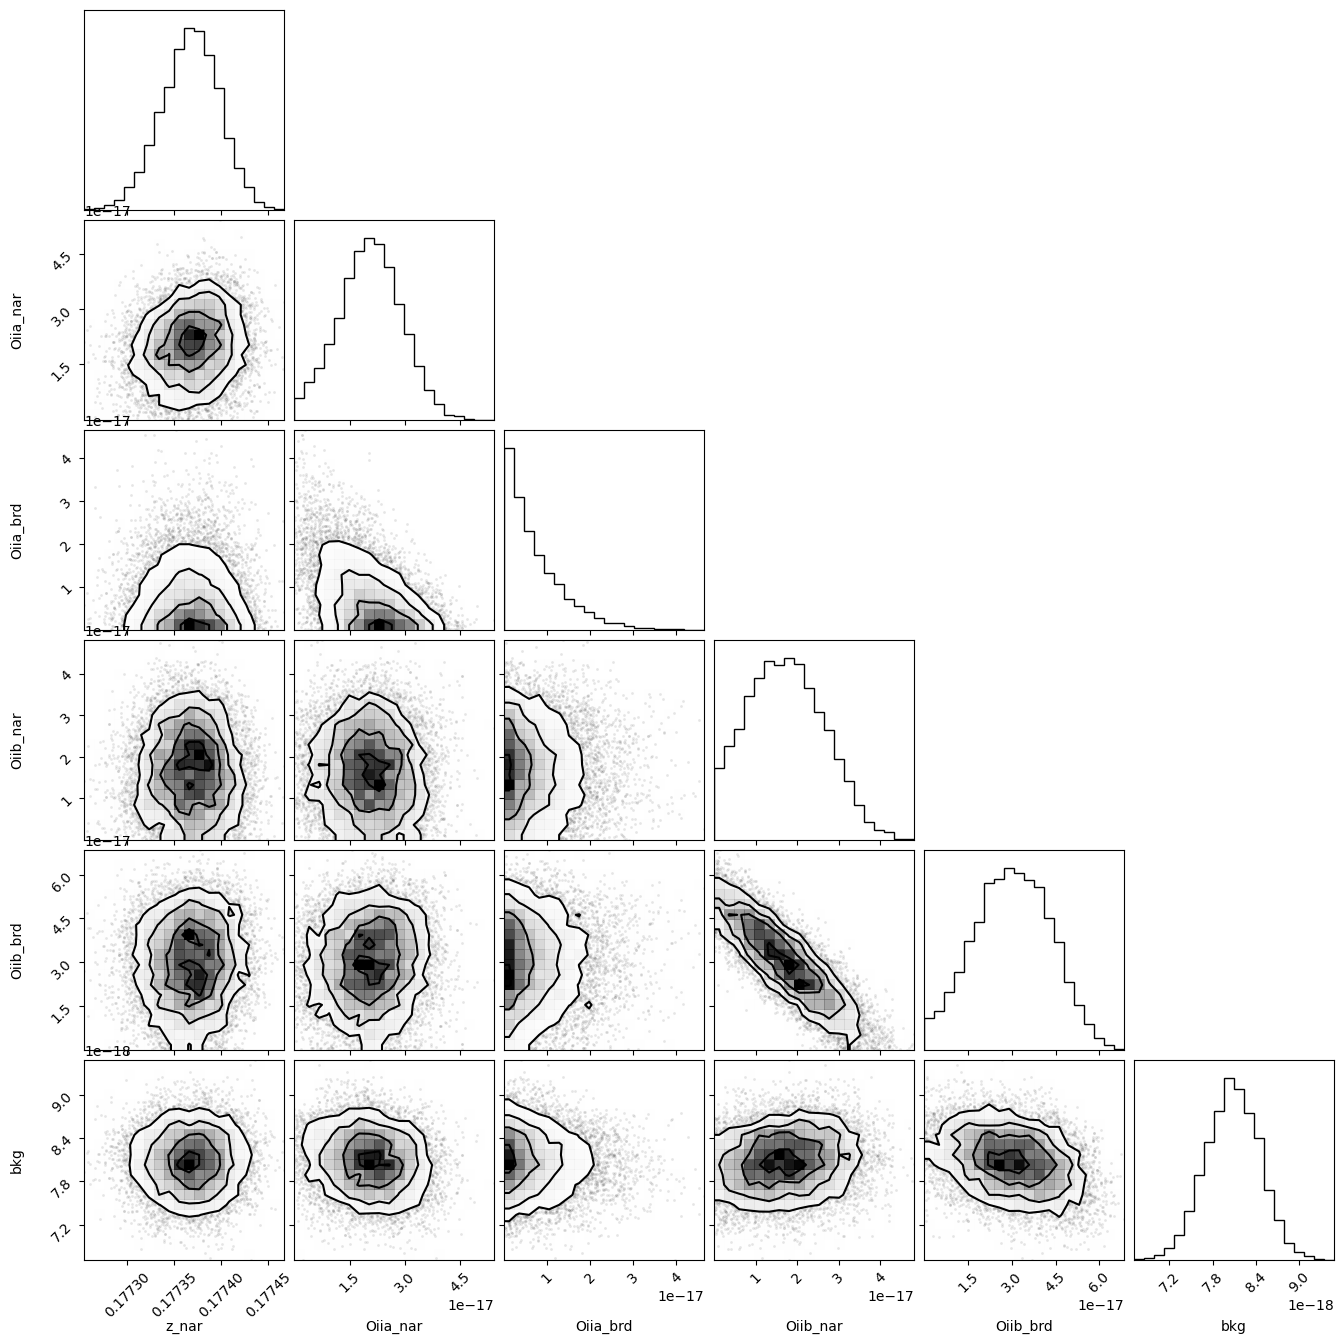

In [36]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

In [37]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17736834,3.0835e-05,(0.02%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,1.04967825,,,1.0496782481139981,-inf,inf,False
sigma_brd,2.00461705,,,2.004617054442317,-inf,inf,False
Oiia_nar,2.0600e-17,8.4598e-18,(41.07%),1e-17,0.00000000,inf,True
Oiia_brd,5.3747e-18,6.2381e-18,(116.06%),2e-17,0.00000000,inf,True
Oiib_nar,1.7028e-17,9.6613e-18,(56.74%),2e-17,0.00000000,inf,True
Oiib_brd,3.0282e-17,1.3574e-17,(44.82%),3e-17,0.00000000,inf,True
bkg,8.0826e-18,3.7491e-19,(4.64%),8e-18,0.00000000,inf,True


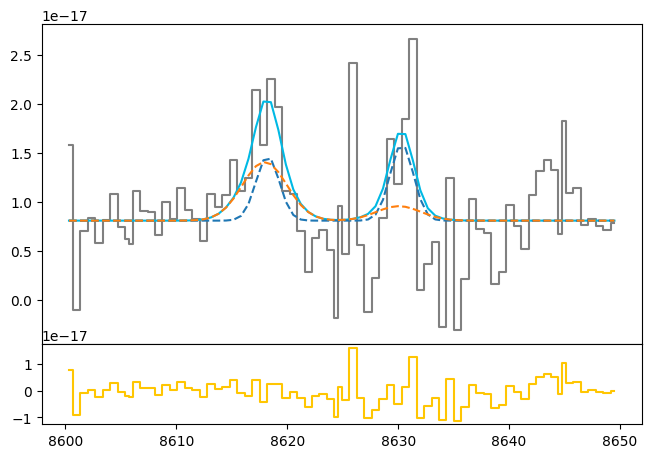

In [38]:
oiia_nar_flux = out_oii_7320.flatchain.Oiia_nar.mean()
oiia_nar_std = out_oii_7320.flatchain.Oiia_nar.std()

oiia_brd_flux = out_oii_7320.flatchain.Oiia_brd.mean()
oiia_brd_std = out_oii_7320.flatchain.Oiia_brd.std()

oiib_nar_flux = out_oii_7320.flatchain.Oiib_nar.mean()
oiib_nar_std = out_oii_7320.flatchain.Oiib_nar.std()

oiib_brd_flux = out_oii_7320.flatchain.Oiib_brd.mean()
oiib_brd_std = out_oii_7320.flatchain.Oiib_brd.std()

z_oii_7320 = out_oii_7320.flatchain.z_nar.mean()
z_oii_7320_std = out_oii_7320.flatchain.z_nar.std()

bkg_oii_7320 = out_oii_7320.flatchain.bkg.mean()
bkg_oii_7320_std = out_oii_7320.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')

In [39]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

# [SII]6716 + [SII]6730

In [40]:
sigma_arc_6730 = (m * wave_cat['[SII]6730']*(1 + z_BN[igal])) + n

sigma_nar_6730 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6730**2))
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

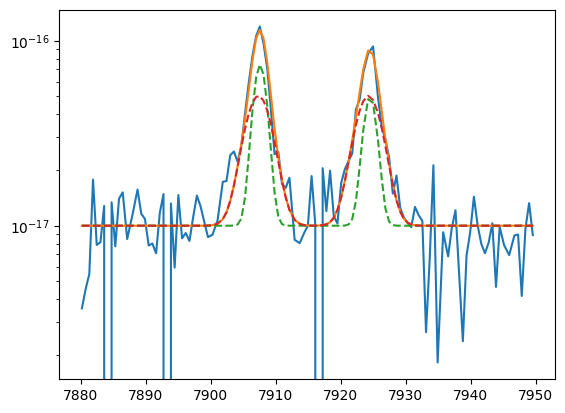

In [41]:
plt.plot(sii.wavelength, sii.flux)
bkg = 1e-17

siia_nar = gaussian(sii.wavelength, 1e-16, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 2e-16, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 1.6e-16, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 2e-16, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib + bkg)
plt.plot(sii.wavelength, siia_nar + siib_nar + bkg, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd + bkg, ls='--')
plt.yscale('log')

In [42]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=1.0e-16, min=0.)
params_sii.add('Siia_brd', value=2.0e-16, min=0.)
params_sii.add('Siib_nar', value=1.6e-16, min=0.)
params_sii.add('Siib_brd', value=2.0e-16, min=0.)
params_sii.add('bkg', value=1e-17, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_nar = params_sii['sigma_nar']
    sigma_brd = params_sii['sigma_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    bkg = params_sii['bkg']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_brd)
    model = model_siia + model_siib
    return (model + bkg - sii.flux) / sii.noise

In [43]:
np.random.seed(2212)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 97.23it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.03238337 52.79712202 54.66019284 52.25942442 51.34809822 54.73759048]


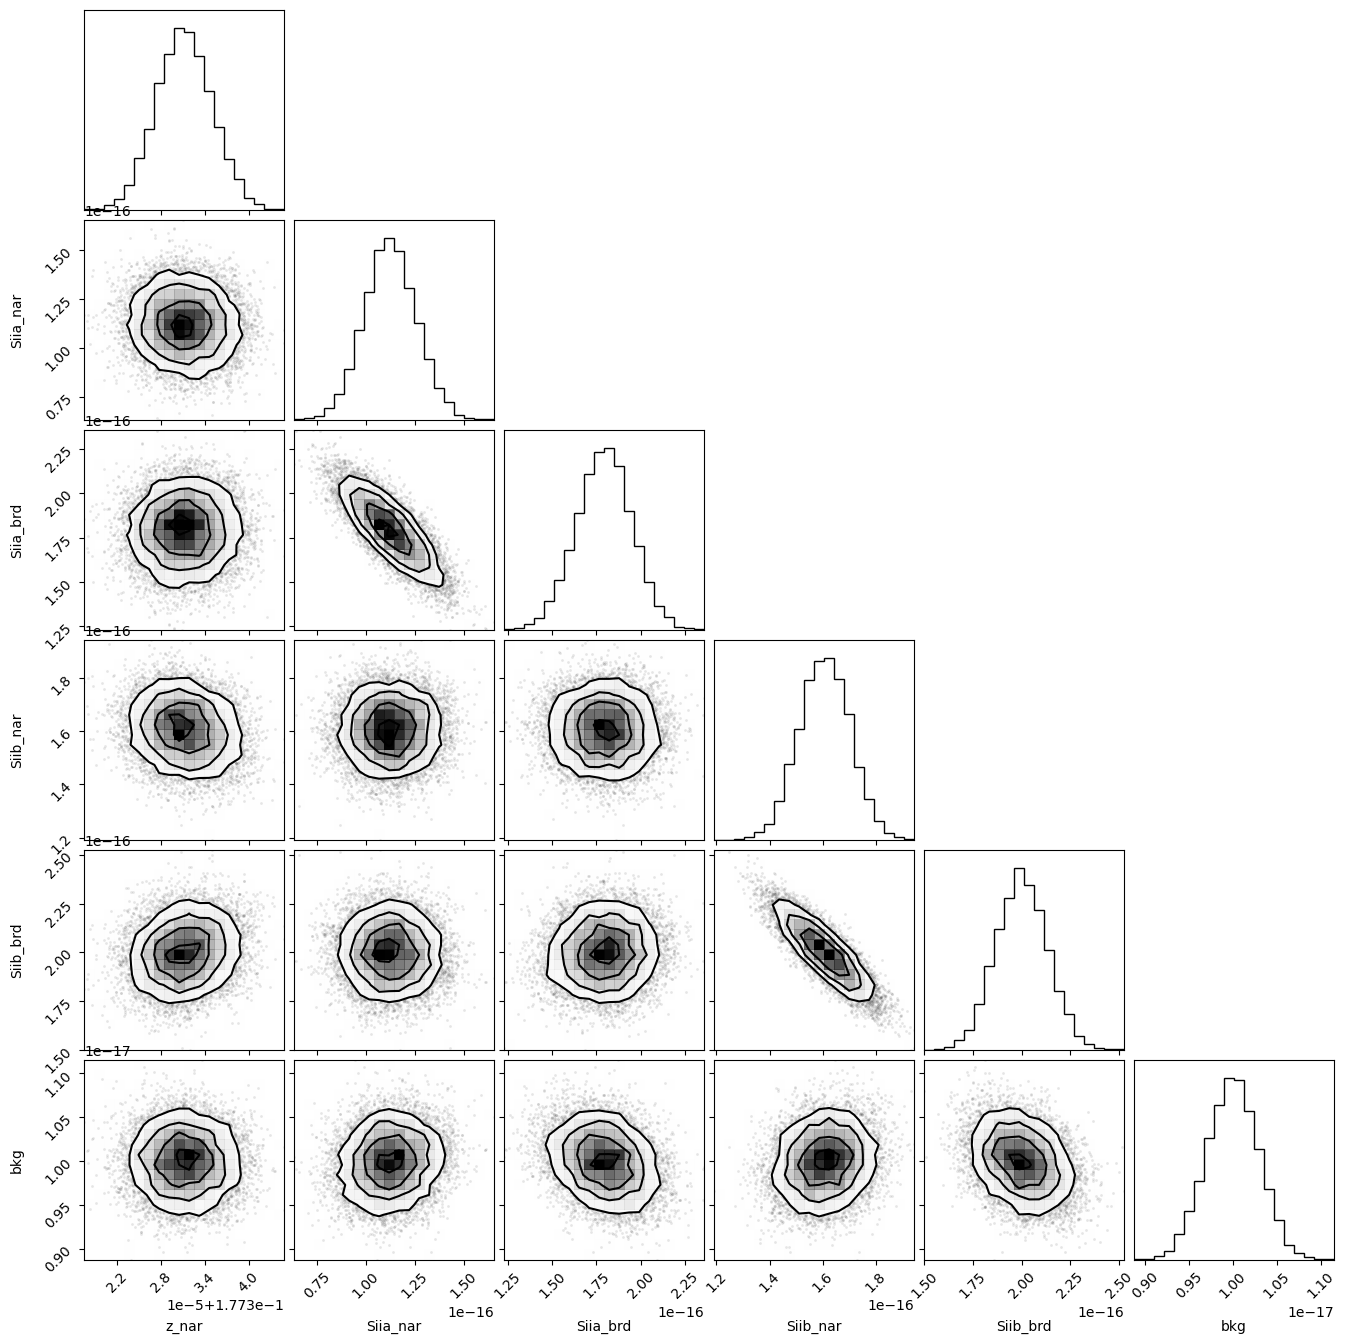

In [44]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

In [45]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17733119,3.8143e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.99223025,,,0.9922302507615515,-inf,inf,False
sigma_brd,1.97514202,,,1.9751420153810841,-inf,inf,False
Siia_nar,1.1233e-16,1.3286e-17,(11.83%),1e-16,0.00000000,inf,True
Siia_brd,1.7953e-16,1.5673e-17,(8.73%),2e-16,0.00000000,inf,True
Siib_nar,1.6079e-16,9.6083e-18,(5.98%),1.6e-16,0.00000000,inf,True
Siib_brd,1.9995e-16,1.3231e-17,(6.62%),2e-16,0.00000000,inf,True
bkg,9.9991e-18,2.9692e-19,(2.97%),1e-17,0.00000000,inf,True


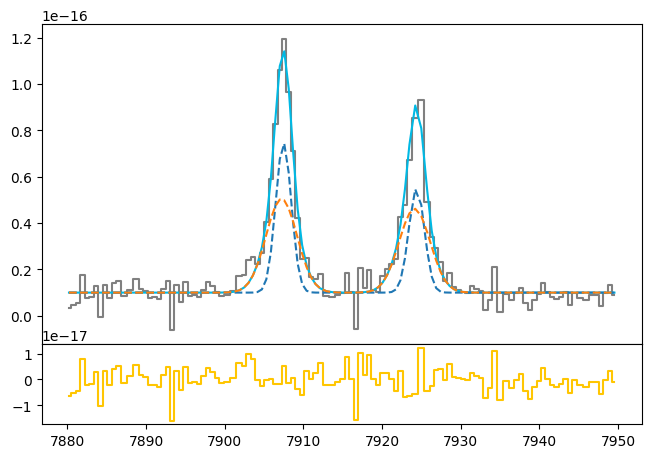

In [46]:
siia_nar_flux = out_sii.flatchain.Siia_nar.mean()
siia_nar_std = out_sii.flatchain.Siia_nar.std()

siia_brd_flux = out_sii.flatchain.Siia_brd.mean()
siia_brd_std = out_sii.flatchain.Siia_brd.std()

siib_nar_flux = out_sii.flatchain.Siib_nar.mean()
siib_nar_std = out_sii.flatchain.Siib_nar.std()

siib_brd_flux = out_sii.flatchain.Siib_brd.mean()
siib_brd_std = out_sii.flatchain.Siib_brd.std()

z_sii = out_sii.flatchain.z_nar.mean()
z_sii_std = out_sii.flatchain.z_nar.std()

bkg_sii = out_sii.flatchain.bkg.mean()
bkg_sii_std = out_sii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, bkg_sii + siia + siib, color=c[0])
ax.plot(sii.wavelength, bkg_sii + siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, bkg_sii + siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - bkg_sii - siia - siib, color=c[3], where='mid')


In [47]:
# EW
EW_SII_6730_nar = ufloat(siia_nar_flux, siia_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730_brd = ufloat(siia_brd_flux, siia_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6730 = (ufloat(siia_nar_flux, siia_nar_std) + ufloat(siia_brd_flux, siia_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

EW_SII_6716_nar = ufloat(siib_nar_flux, siib_nar_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716_brd = ufloat(siib_brd_flux, siib_brd_std) / ufloat(bkg_sii, bkg_sii_std)
EW_SII_6716 = (ufloat(siib_nar_flux, siib_nar_std) + ufloat(siib_brd_flux, siib_brd_std)) / ufloat(bkg_sii, bkg_sii_std)

# H$\beta$

In [48]:
sigma_arc_hb = (m * wave_cat['Hb']*(1 + z_BN[igal])) + n

sigma_nar_hb = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hb**2))
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

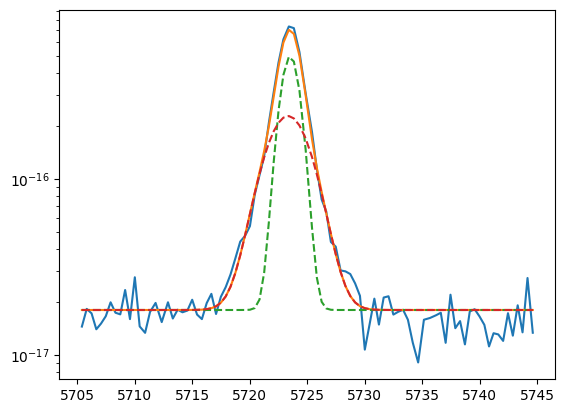

In [49]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 1.8e-17

hb_nar = gaussian(hbeta.wavelength, 1e-15, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 1.0e-15, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb + bkg)
plt.plot(hbeta.wavelength, hb_nar + bkg, ls='--')
plt.plot(hbeta.wavelength, hb_brd + bkg, ls='--')
plt.yscale('log')

In [50]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=1.0e-15, min=0.)
params_hb.add('Hb_brd', value=1.0e-15, min=0.)
params_hb.add('bkg', value=1.8e-17, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_nar = params_hb['sigma_nar']
    sigma_brd = params_hb['sigma_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    bkg = params_hb['bkg']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_brd)
    return (model + bkg - hbeta.flux) / hbeta.noise

In [51]:
np.random.seed(2212)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 131.61it/s]


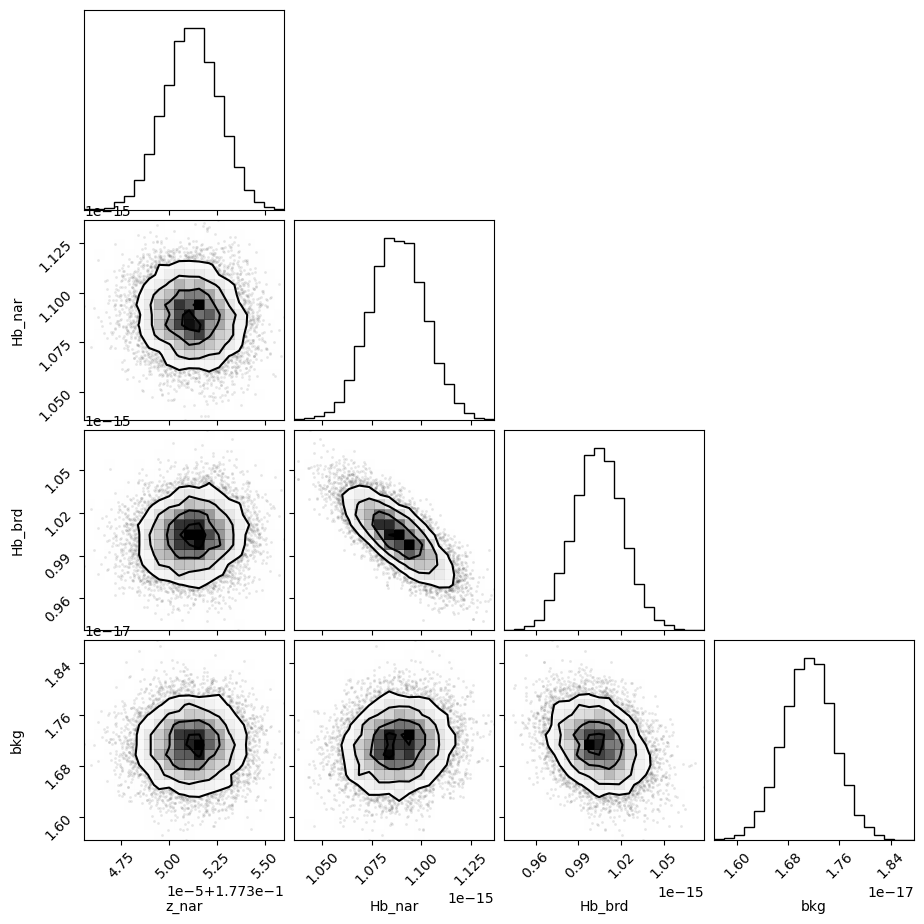

In [52]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

In [53]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735117,1.4366e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.82762421,,,0.827624208741242,-inf,inf,False
sigma_brd,1.89779528,,,1.8977952843475734,-inf,inf,False
Hb_nar,1.0879e-15,1.3877e-17,(1.28%),1e-15,0.00000000,inf,True
Hb_brd,1.0038e-15,1.7332e-17,(1.73%),1e-15,0.00000000,inf,True
bkg,1.7130e-17,3.9479e-19,(2.30%),1.8e-17,0.00000000,inf,True


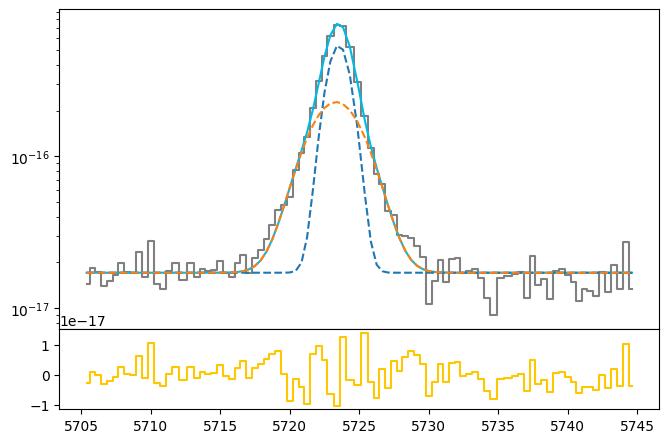

In [54]:
hb_nar_flux = out_hb.flatchain.Hb_nar.mean()
hb_nar_std = out_hb.flatchain.Hb_nar.std()

hb_brd_flux = out_hb.flatchain.Hb_brd.mean()
hb_brd_std = out_hb.flatchain.Hb_brd.std()

z_hb = out_hb.flatchain.z_nar.mean()
z_hb_std = out_hb.flatchain.z_nar.std()

bkg_hb = out_hb.flatchain.bkg.mean()
bkg_hb_std = out_hb.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, bkg_hb + hb, color=c[0])
ax.plot(hbeta.wavelength, bkg_hb + hb_nar, ls='--')
ax.plot(hbeta.wavelength, bkg_hb + hb_brd, ls='--')
ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - bkg_hb - hb, color=c[3], where='mid')

In [55]:
# EW
EW_Hb_nar = ufloat(hb_nar_flux, hb_nar_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb_brd = ufloat(hb_brd_flux, hb_brd_std) / ufloat(bkg_hb, bkg_hb_std)
EW_Hb = (ufloat(hb_nar_flux, hb_nar_std) + ufloat(hb_brd_flux, hb_brd_std)) / ufloat(bkg_hb, bkg_hb_std)

# H$\gamma$

In [56]:
sigma_arc_hg = (m * wave_cat['Hg']*(1 + z_BN[igal])) + n

sigma_nar_hg = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hg**2))
sigma_brd_hg = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hg**2))

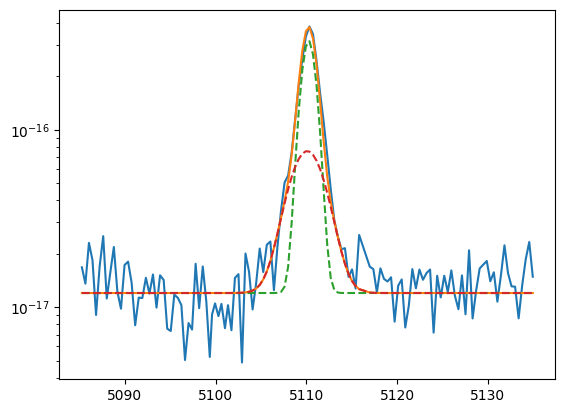

In [57]:
plt.plot(hgamma.wavelength, hgamma.flux)
bkg = 1.2e-17

hg_nar = gaussian(hgamma.wavelength, 6e-16, wave_cat['Hg'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, 3e-16, wave_cat['Hg'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

plt.plot(hgamma.wavelength, hg + bkg)
plt.plot(hgamma.wavelength, hg_nar + bkg, ls='--')
plt.plot(hgamma.wavelength, hg_brd + bkg, ls='--')
plt.yscale('log')

In [58]:
params_hg = Parameters()
params_hg.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hg.add('z_ratio', value=z_ratio, vary=False)
params_hg.add('sigma_nar', value=upy.nominal_values(sigma_nar_hg), vary=False)
params_hg.add('sigma_brd', value=upy.nominal_values(sigma_brd_hg), vary=False)
params_hg.add('Hg_nar', value=6.0e-16, min=0.)
params_hg.add('Hg_brd', value=3.0e-16, min=0.)
params_hg.add('bkg', value=1.2e-17, min=0.)

def residual_hg(params_hg, x, data, uncertainty):
    
    z_nar = params_hg['z_nar']
    z_brd = params_hg['z_nar'] * params_hg['z_ratio']
    sigma_nar = params_hg['sigma_nar']
    sigma_brd = params_hg['sigma_brd']
    hg_nar_flux = params_hg['Hg_nar']
    hg_brd_flux = params_hg['Hg_brd']
    bkg = params_hg['bkg']
    
    x = hgamma.wavelength
    model = gaussian(x, hg_nar_flux, wave_cat['Hg'], z_nar, sigma_nar) + \
            gaussian(x, hg_brd_flux, wave_cat['Hg'], z_brd, sigma_brd)
    return (model + bkg - hgamma.flux) / hgamma.noise

In [59]:
np.random.seed(2212)
out_hg = minimize(residual_hg, params_hg, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 128.84it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [37.06411435 52.45982527 51.30189826 43.08584054]


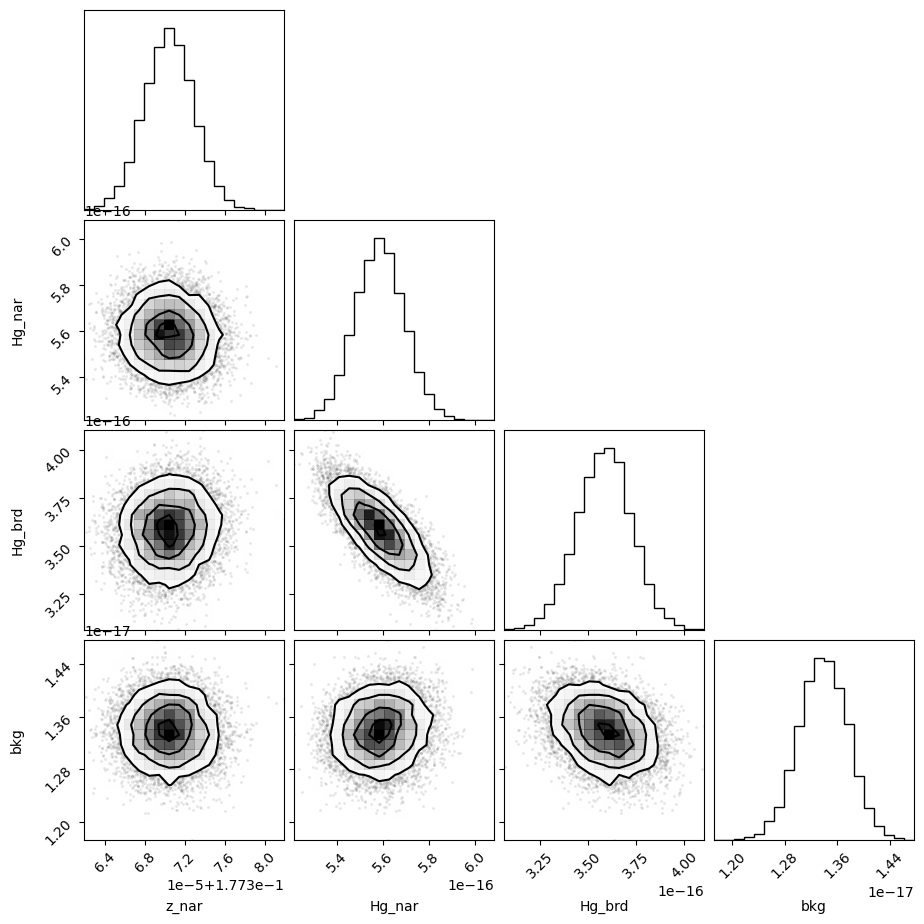

In [60]:
corner.corner(out_hg.flatchain, labels=out_hg.var_names);

In [61]:
out_hg.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17737044,2.4757e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.78701115,,,0.7870111532050036,-inf,inf,False
sigma_brd,1.88043922,,,1.8804392214762988,-inf,inf,False
Hg_nar,5.5868e-16,1.0724e-17,(1.92%),6e-16,0.00000000,inf,True
Hg_brd,3.5875e-16,1.3996e-17,(3.90%),3e-16,0.00000000,inf,True
bkg,1.3388e-17,3.7208e-19,(2.78%),1.2e-17,0.00000000,inf,True


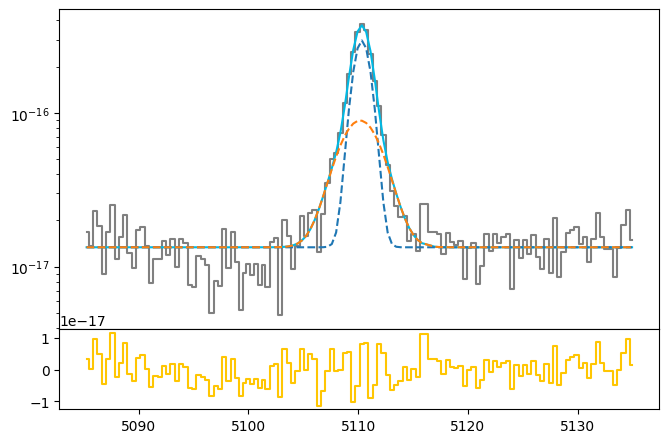

In [62]:
hg_nar_flux = out_hg.flatchain.Hg_nar.mean()
hg_nar_std = out_hg.flatchain.Hg_nar.std()

hg_brd_flux = out_hg.flatchain.Hg_brd.mean()
hg_brd_std = out_hg.flatchain.Hg_brd.std()

z_hg = out_hg.flatchain.z_nar.mean()
z_hg_std = out_hg.flatchain.z_nar.std()

bkg_hg = out_hg.flatchain.bkg.mean()
bkg_hg_std = out_hg.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hgamma.wavelength, hgamma.flux, color='gray', label='Data', where='mid')

hg_nar = gaussian(hgamma.wavelength, hg_nar_flux, wave_cat['Hg'],           z_hg, upy.nominal_values(sigma_nar_hg))
hg_brd = gaussian(hgamma.wavelength, hg_brd_flux, wave_cat['Hg'], z_hg * z_ratio, upy.nominal_values(sigma_brd_hg))

hg = hg_nar + hg_brd

ax.plot(hgamma.wavelength, bkg_hg + hg, color=c[0])
ax.plot(hgamma.wavelength, bkg_hg + hg_nar, ls='--')
ax.plot(hgamma.wavelength, bkg_hg + hg_brd, ls='--')
ax.set_yscale('log')
ax1.step(hgamma.wavelength, hgamma.flux - bkg_hg - hg, color=c[3], where='mid')

In [63]:
# EW
EW_Hg_nar = ufloat(hg_nar_flux, hg_nar_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg_brd = ufloat(hg_brd_flux, hg_brd_std) / ufloat(bkg_hg, bkg_hg_std)
EW_Hg = (ufloat(hg_nar_flux, hg_nar_std) + ufloat(hg_brd_flux, hg_brd_std)) / ufloat(bkg_hg, bkg_hg_std)

# H$\delta$

In [64]:
sigma_arc_hd = (m * wave_cat['Hd']*(1 + z_BN[igal])) + n

sigma_nar_hd = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hd**2))
sigma_brd_hd = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hd**2))

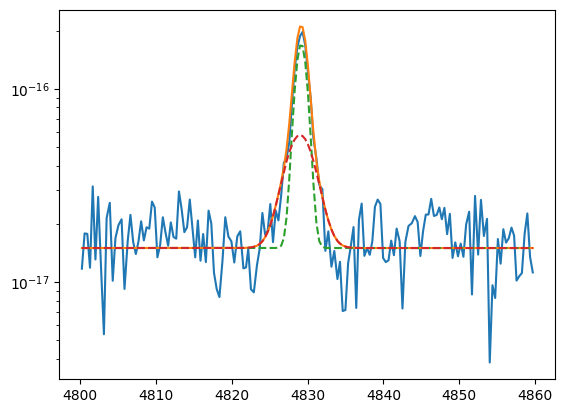

In [65]:
plt.plot(hdelta.wavelength, hdelta.flux)
bkg = 1.5e-17

hd_nar = gaussian(hdelta.wavelength, 3e-16, wave_cat['Hd'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hd))
hd_brd = gaussian(hdelta.wavelength, 2e-16, wave_cat['Hd'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hd))

hd = hd_nar + hd_brd

plt.plot(hdelta.wavelength, hd + bkg)
plt.plot(hdelta.wavelength, hd_nar + bkg, ls='--')
plt.plot(hdelta.wavelength, hd_brd + bkg, ls='--')
plt.yscale('log')

In [66]:
params_hd = Parameters()
params_hd.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hd.add('z_ratio', value=z_ratio, vary=False)
params_hd.add('sigma_nar', value=upy.nominal_values(sigma_nar_hd), vary=False)
params_hd.add('sigma_brd', value=upy.nominal_values(sigma_brd_hd), vary=False)
params_hd.add('Hd_nar', value=3.0e-16, min=0.)
params_hd.add('Hd_brd', value=2.0e-16, min=0.)
params_hd.add('bkg', value=1.5e-17, min=0.)

def residual_hd(params_hd, x, data, uncertainty):
    
    z_nar = params_hd['z_nar']
    z_brd = params_hd['z_nar'] * params_hd['z_ratio']
    sigma_nar = params_hd['sigma_nar']
    sigma_brd = params_hd['sigma_brd']
    hd_nar_flux = params_hd['Hd_nar']
    hd_brd_flux = params_hd['Hd_brd']
    bkg = params_hd['bkg']
    
    x = hdelta.wavelength
    model = gaussian(x, hd_nar_flux, wave_cat['Hd'], z_nar, sigma_nar) + \
            gaussian(x, hd_brd_flux, wave_cat['Hd'], z_brd, sigma_brd)
    return (model + bkg - hdelta.flux) / hdelta.noise

In [67]:
np.random.seed(2212)
out_hd = minimize(residual_hd, params_hd, args=(1, 1, 1),
                   method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.12it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [39.3467854  37.54205838 48.01684742 54.34270743]


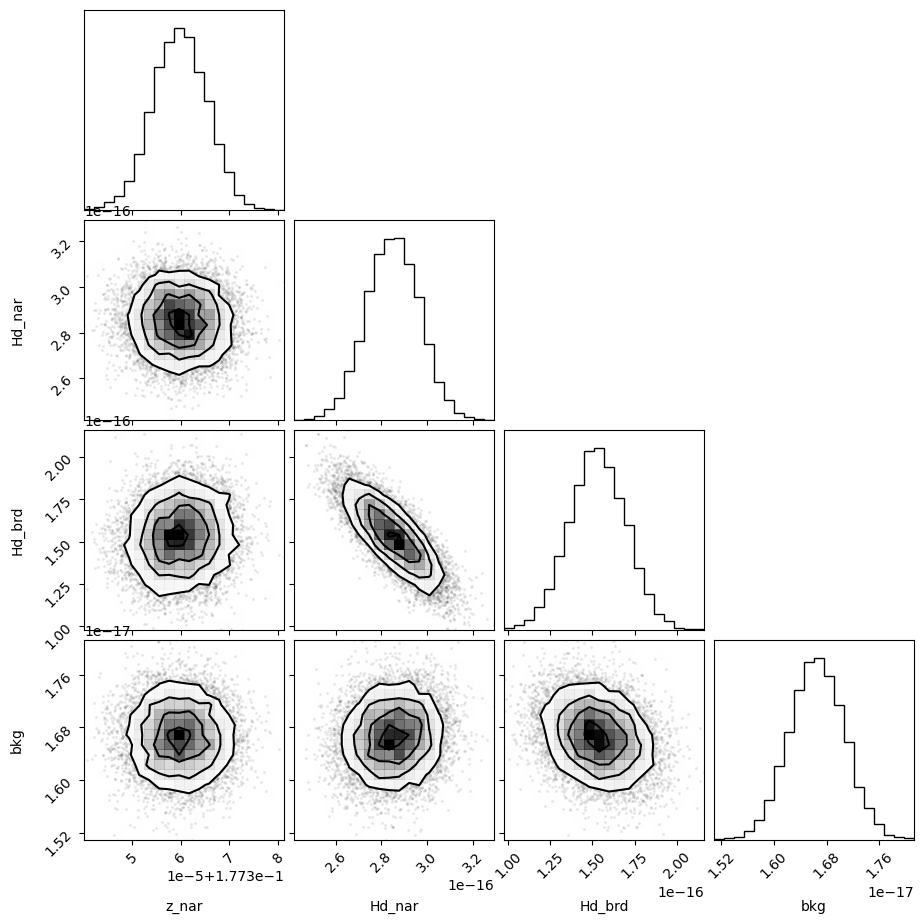

In [68]:
corner.corner(out_hd.flatchain, labels=out_hd.var_names);

In [69]:
out_hd.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735986,5.5283e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.76937240,,,0.7693724006160056,-inf,inf,False
sigma_brd,1.87312546,,,1.873125463290421,-inf,inf,False
Hd_nar,2.8522e-16,1.1381e-17,(3.99%),3e-16,0.00000000,inf,True
Hd_brd,1.5308e-16,1.6920e-17,(11.05%),2e-16,0.00000000,inf,True
bkg,1.6656e-17,4.1888e-19,(2.51%),1.5e-17,0.00000000,inf,True


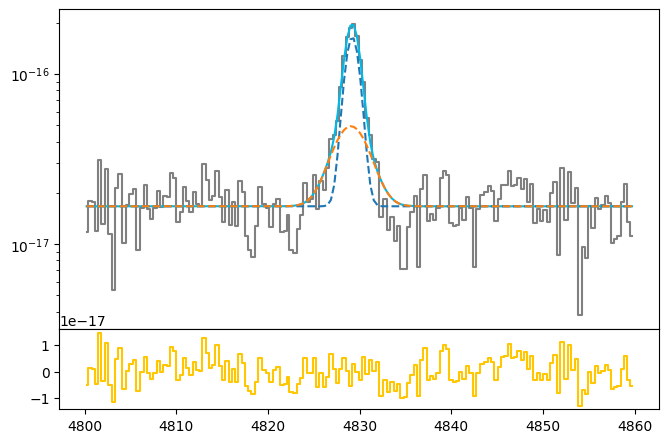

In [70]:
hd_nar_flux = out_hd.flatchain.Hd_nar.mean()
hd_nar_std = out_hd.flatchain.Hd_nar.std()

hd_brd_flux = out_hd.flatchain.Hd_brd.mean()
hd_brd_std = out_hd.flatchain.Hd_brd.std()

z_hd = out_hd.flatchain.z_nar.mean()
z_hd_std = out_hd.flatchain.z_nar.std()

bkg_hd = out_hd.flatchain.bkg.mean()
bkg_hd_std = out_hd.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hdelta.wavelength, hdelta.flux, color='gray', label='Data', where='mid')

hd_nar = gaussian(hdelta.wavelength, hd_nar_flux, wave_cat['Hd'],           z_hd, upy.nominal_values(sigma_nar_hd))
hd_brd = gaussian(hdelta.wavelength, hd_brd_flux, wave_cat['Hd'], z_hd * z_ratio, upy.nominal_values(sigma_brd_hd))

hd = hd_nar + hd_brd

ax.plot(hdelta.wavelength, bkg_hd + hd, color=c[0])
ax.plot(hdelta.wavelength, bkg_hd + hd_nar, ls='--')
ax.plot(hdelta.wavelength, bkg_hd + hd_brd, ls='--')
ax.set_yscale('log')
ax1.step(hdelta.wavelength, hdelta.flux - bkg_hd - hd, color=c[3], where='mid')

In [71]:
# EW
EW_Hd_nar = ufloat(hd_nar_flux, hd_nar_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd_brd = ufloat(hd_brd_flux, hd_brd_std) / ufloat(bkg_hd, bkg_hd_std)
EW_Hd = (ufloat(hd_nar_flux, hd_nar_std) + ufloat(hd_brd_flux, hd_brd_std)) / ufloat(bkg_hd, bkg_hd_std)

# [OII]3726 + [OII]3729

In [72]:
sigma_arc_3729 = (m * wave_cat['[OII]3729']*(1 + z_BN[igal])) + n

sigma_nar_3729 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3729**2))
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

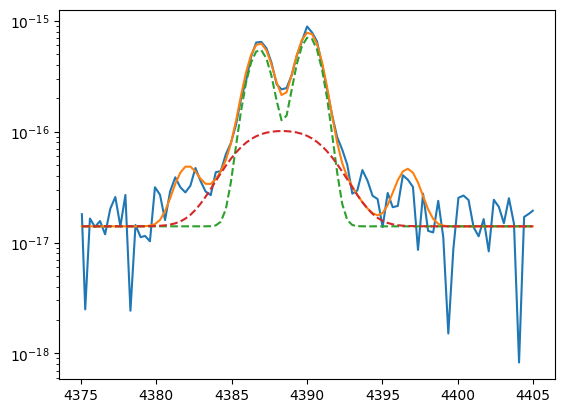

In [73]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 0.6e-16, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 1.3e-15, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 3.0e-16, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 1.0e-15, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 3.0e-16, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 0.6e-16, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 1.4e-17

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')

plt.yscale('log')

In [74]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=0.5e-16, min=0.)
params_oii_3727.add('Oiic_nar', value=1.4e-15, min=0.)
params_oii_3727.add('Oiic_brd', value=3.0e-16, min=0.)
params_oii_3727.add('Oiid_nar', value=1.0e-15, min=0.)
params_oii_3727.add('Oiid_brd', value=3.0e-16, min=0.)
params_oii_3727.add('H14', value=0.5e-16, min=0.)
params_oii_3727.add('bkg', value=1.4e-17, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [75]:
np.random.seed(2212)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|███████████████████████████████████████| 2500/2500 [00:31<00:00, 78.58it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [58.6192114  82.19036521 67.07939187 61.23101341 66.56870919 75.03331053
 79.15482534 79.1522428 ]


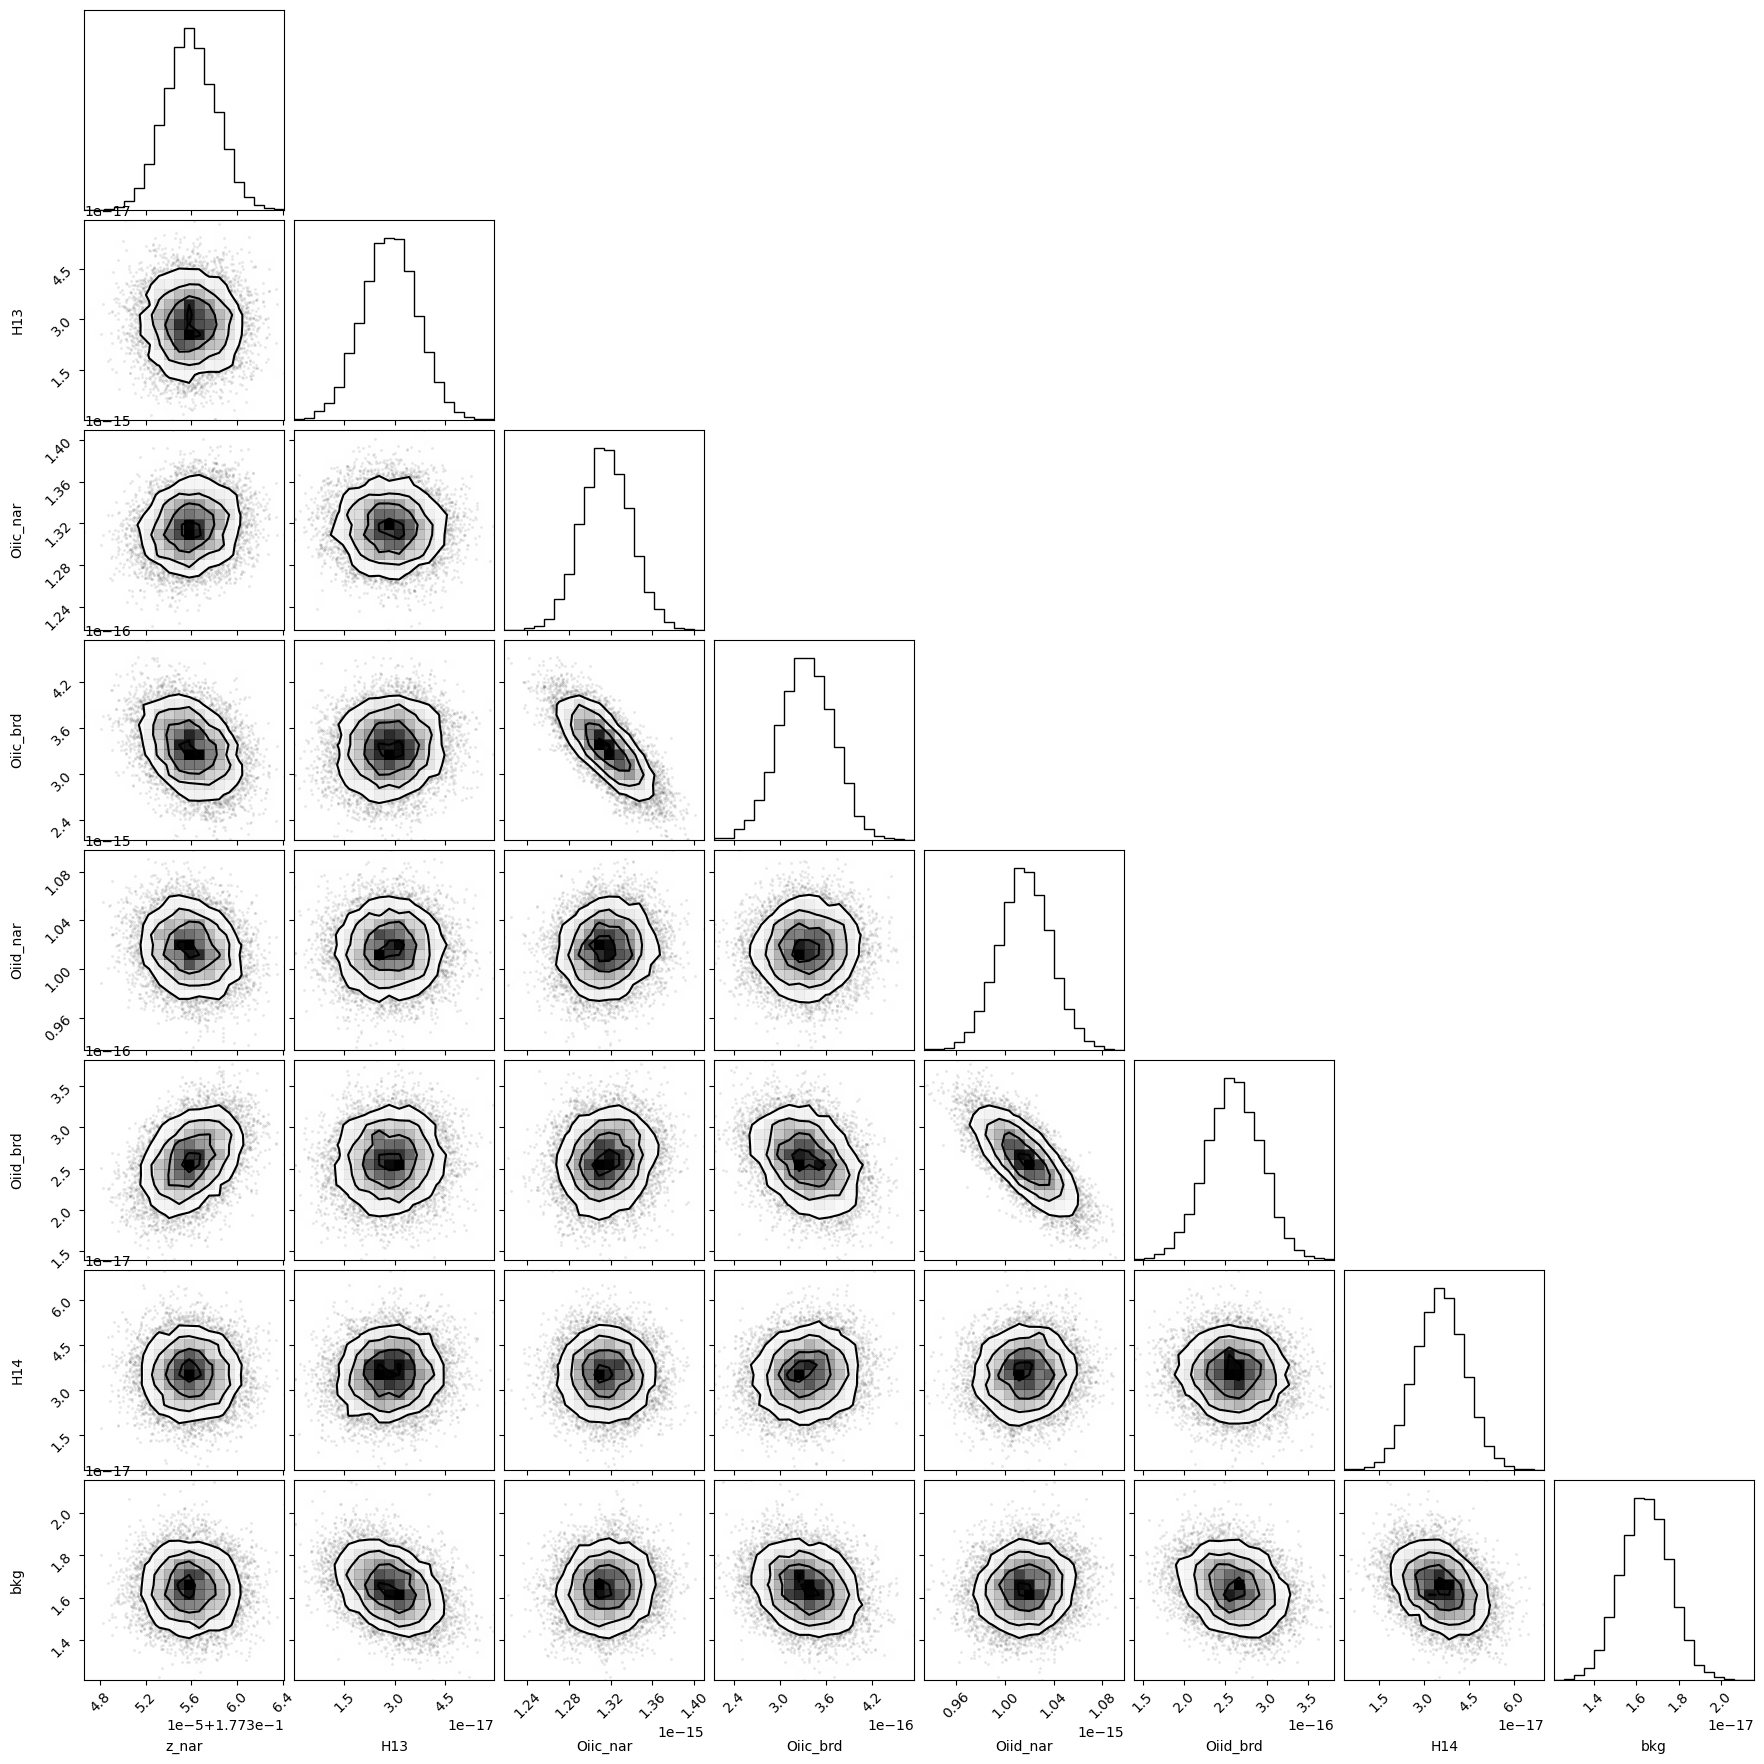

In [76]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

In [77]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735592,2.2509e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.74319292,,,0.7431929212368087,-inf,inf,False
sigma_brd,1.86252539,,,1.8625253900480985,-inf,inf,False
H13,2.8594e-17,8.1452e-18,(28.49%),5e-17,0.00000000,inf,True
Oiic_nar,1.3154e-15,2.3393e-17,(1.78%),1.4e-15,0.00000000,inf,True
Oiic_brd,3.3441e-16,3.5249e-17,(10.54%),3e-16,0.00000000,inf,True
Oiid_nar,1.0165e-15,2.1091e-17,(2.07%),1e-15,0.00000000,inf,True
Oiid_brd,2.6036e-16,3.3244e-17,(12.77%),3e-16,0.00000000,inf,True
H14,3.5510e-17,8.2271e-18,(23.17%),5e-17,0.00000000,inf,True


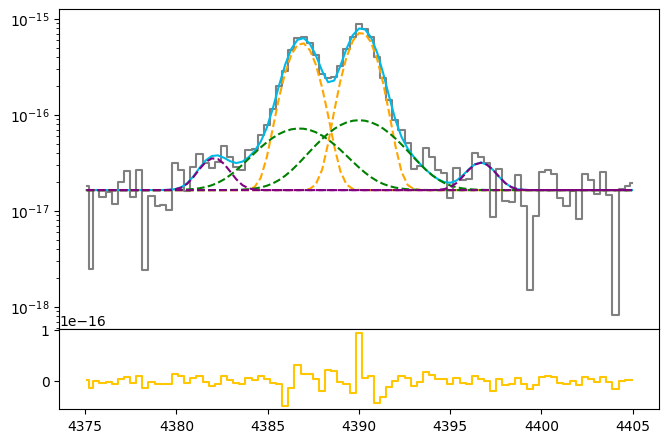

In [78]:
h13_flux = out_oii_3727.flatchain.H13.mean()
h13_std = out_oii_3727.flatchain.H13.std()

oiic_nar_flux = out_oii_3727.flatchain.Oiic_nar.mean()
oiic_nar_std = out_oii_3727.flatchain.Oiic_nar.std()

oiic_brd_flux = out_oii_3727.flatchain.Oiic_brd.mean()
oiic_brd_std = out_oii_3727.flatchain.Oiic_brd.std()

oiid_nar_flux = out_oii_3727.flatchain.Oiid_nar.mean()
oiid_nar_std = out_oii_3727.flatchain.Oiid_nar.std()

oiid_brd_flux = out_oii_3727.flatchain.Oiid_brd.mean()
oiid_brd_std = out_oii_3727.flatchain.Oiid_brd.std()

h14_flux = out_oii_3727.flatchain.H14.mean()
h14_std = out_oii_3727.flatchain.H14.std()

z_oii_3727 = out_oii_3727.flatchain.z_nar.mean()
z_oii_3727_std = out_oii_3727.flatchain.z_nar.std()

bkg_oii_3727 = out_oii_3727.flatchain.bkg.mean()
bkg_oii_3727_std = out_oii_3727.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14, color=c[3], where='mid')

In [79]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

# [OI]6300 + [SIII]6312

In [80]:
sigma_arc_6312 = (m * wave_cat['[SIII]6312']*(1 + z_BN[igal])) + n

sigma_nar_6312 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6312**2))
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

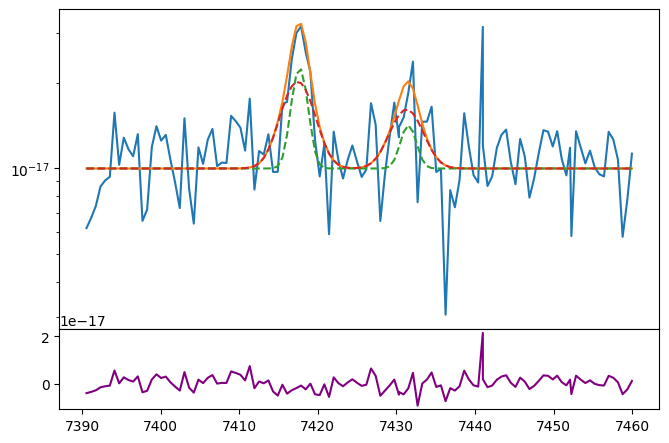

In [81]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 1e-17

oi_nar = gaussian(oi_siii.wavelength, 0.3e-16, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 0.5e-16, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 0.1e-16, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 0.3e-16, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, bkg + siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, bkg + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg + siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
ax.set_yscale('log')

In [82]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=0.3e-16, min=0.)
params_oi_siii.add('Oi_brd', value=0.5e-16, min=0.)
params_oi_siii.add('Siiic_nar', value=0.1e-16, min=0.)
params_oi_siii.add('Siiic_brd', value=0.3e-16, min=0.)
params_oi_siii.add('bkg', value=1e-17, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_nar = params_oi_siii['sigma_nar']
    sigma_brd = params_oi_siii['sigma_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    bkg = params_oi_siii['bkg']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_brd)
    
    return (model_siii + model_oi + bkg - oi_siii.flux) / oi_siii.noise

In [83]:
np.random.seed(2212)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 111.29it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [65.16850769 70.54140007 80.79656138 63.44923468 68.23041212 65.98720038]


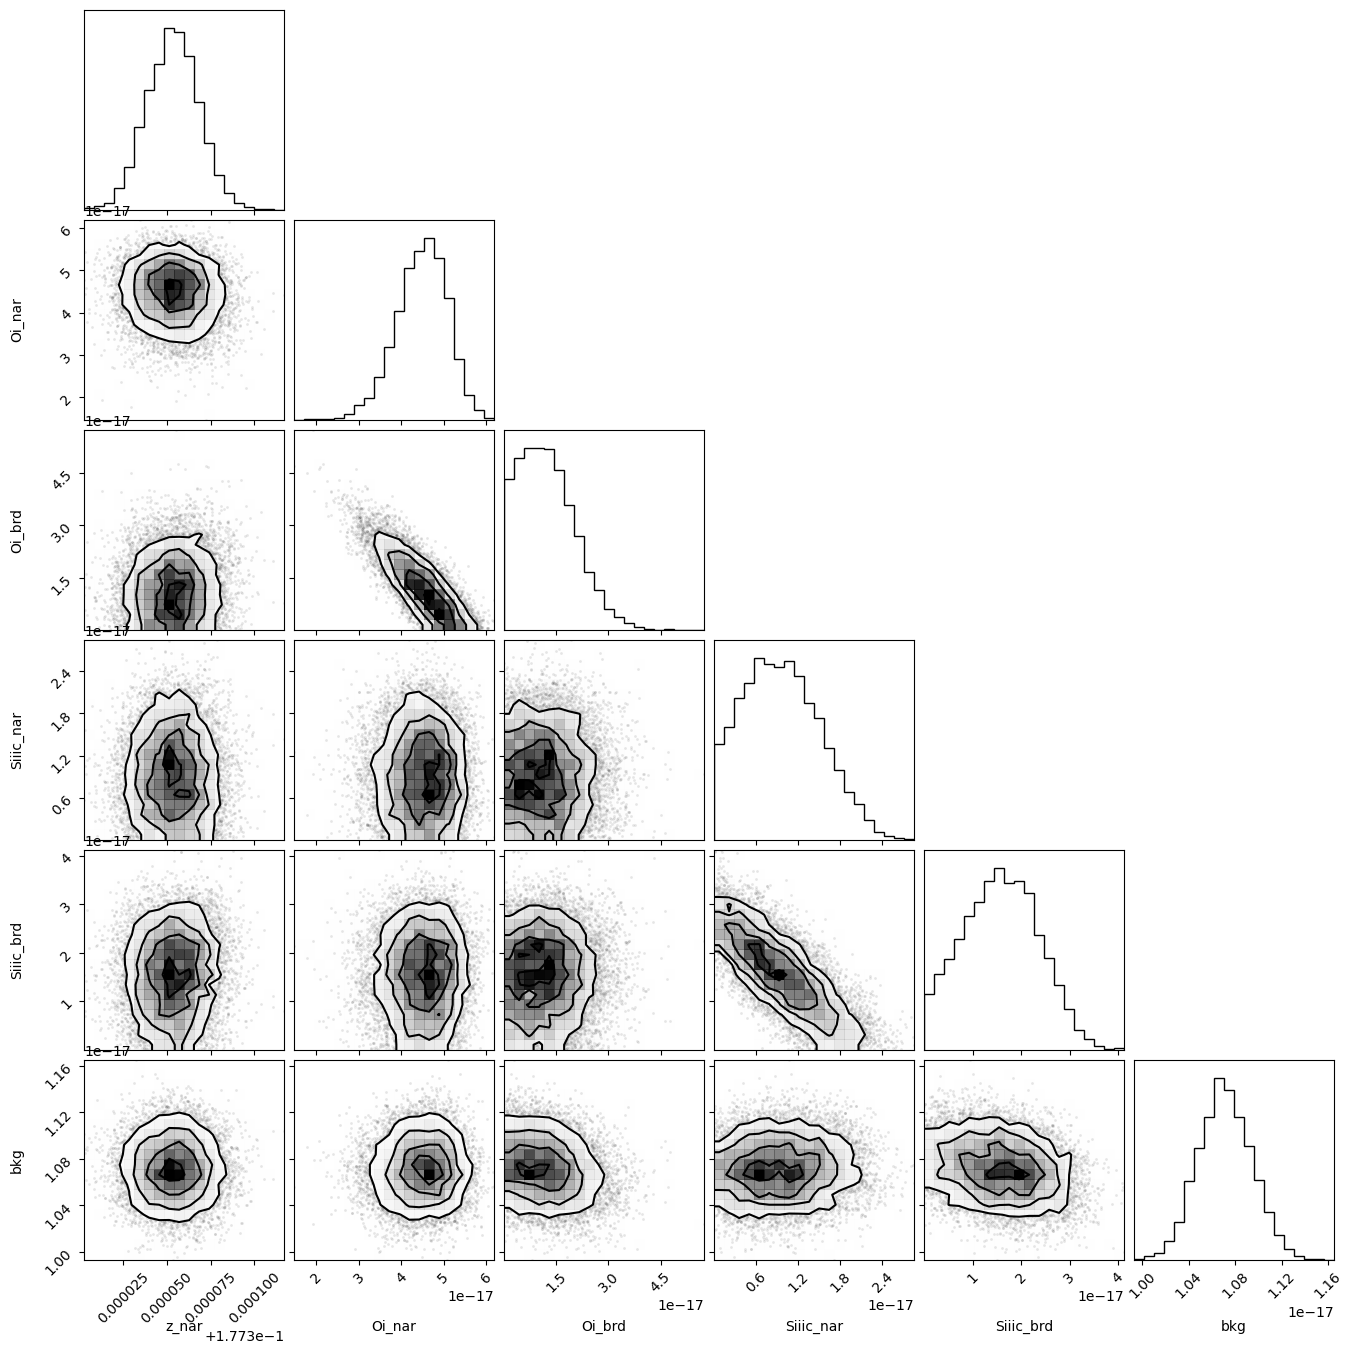

In [84]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [85]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735359,1.4672e-05,(0.01%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.95325344,,,0.9532534354787086,-inf,inf,False
sigma_brd,1.95585205,,,1.9558520451837045,-inf,inf,False
Oi_nar,4.5216e-17,5.9180e-18,(13.09%),3e-17,0.00000000,inf,True
Oi_brd,1.1656e-17,8.2748e-18,(70.99%),5e-17,0.00000000,inf,True
Siiic_nar,9.2852e-18,5.7198e-18,(61.60%),1e-17,0.00000000,inf,True
Siiic_brd,1.5807e-17,8.1648e-18,(51.65%),3e-17,0.00000000,inf,True
bkg,1.0709e-17,2.3239e-19,(2.17%),1e-17,0.00000000,inf,True


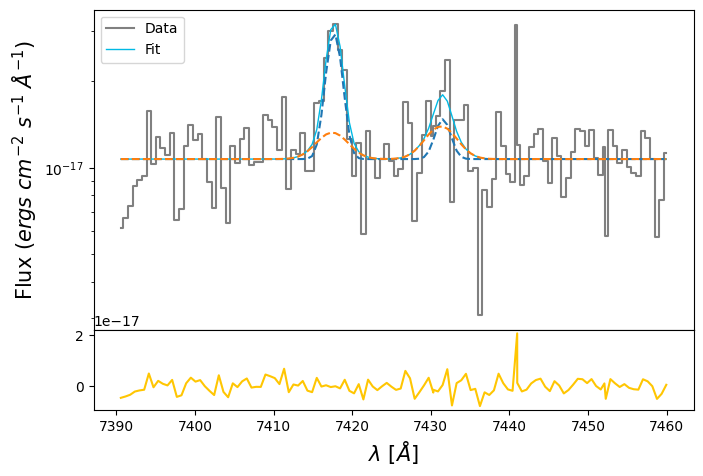

In [86]:
oi_nar_flux = out_oi_siii.flatchain.Oi_nar.mean()
oi_nar_std = out_oi_siii.flatchain.Oi_nar.std()

oi_brd_flux = out_oi_siii.flatchain.Oi_brd.mean()
oi_brd_std = out_oi_siii.flatchain.Oi_brd.std()

siiic_nar_flux = out_oi_siii.flatchain.Siiic_nar.mean()
siiic_nar_std = out_oi_siii.flatchain.Siiic_nar.std()

siiic_brd_flux = out_oi_siii.flatchain.Siiic_brd.mean()
siiic_brd_std = out_oi_siii.flatchain.Siiic_brd.std()

z_oi_siii = out_oi_siii.flatchain.z_nar.mean()
z_oi_siii_std = out_oi_siii.flatchain.z_nar.std()

bkg_oi_siii = out_oi_siii.flatchain.bkg.mean()
bkg_oi_siii_std = out_oi_siii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oi_nar = gaussian(oi_siii.wavelength, oi_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, oi_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oi = oi_nar + oi_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic + oi,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, bkg_oi_siii + siiic_brd + oi_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - bkg_oi_siii - siiic - oi,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [87]:
# EW
EW_OI_6300_nar = ufloat(oi_nar_flux, oi_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300_brd = ufloat(oi_brd_flux, oi_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_OI_6300 = (ufloat(oi_nar_flux, oi_nar_std) + ufloat(oi_brd_flux, oi_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

EW_SIII_6312_nar = ufloat(siiic_nar_flux, siiic_nar_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312_brd = ufloat(siiic_brd_flux, siiic_brd_std) / ufloat(bkg_oi_siii, bkg_oi_siii_std)
EW_SIII_6312 = (ufloat(siiic_nar_flux, siiic_nar_std) + ufloat(siiic_brd_flux, siiic_brd_std)) / ufloat(bkg_oi_siii, bkg_oi_siii_std)

# [OIII]5007 + HeI 5015

In [88]:
sigma_arc_5007 = (m * wave_cat['[OIII]5007']*(1 + z_BN[igal])) + n

sigma_nar_5007 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5007**2))
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

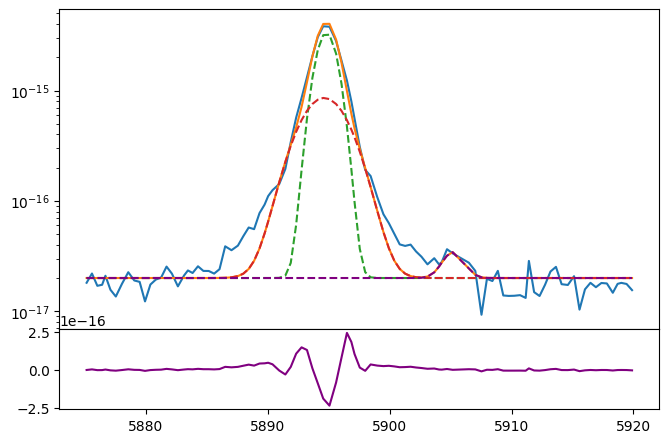

In [89]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 2e-17

oiiia_nar = gaussian(oiii_hei.wavelength, 7e-15, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 4e-15, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 3e-17, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=sigma_nar_oiii_4959)

ax.plot(oiii_hei.wavelength, bkg + oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, bkg + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg + hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiiia_nar - oiiia_brd - hei_5015, color='purple')
ax.set_yscale('log')

In [90]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_nar', value=upy.nominal_values(sigma_nar_5007), vary=False)
params_oiii_hei.add('sigma_brd', value=upy.nominal_values(sigma_brd_5007), vary=False)
params_oiii_hei.add('Hei', value=3e-17, min=0.)
params_oiii_hei.add('Oiiia_nar', value=7.0e-15, min=0.)
params_oiii_hei.add('Oiiia_brd', value=4.0e-15, min=0.)
params_oiii_hei.add('bkg', value=2e-17, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_nar = params_oiii_hei['sigma_nar']
    sigma_brd = params_oiii_hei['sigma_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_nar)
    
    return (model_oiii + model_hei + bkg - oiii_hei.flux) / oiii_hei.noise

In [91]:
np.random.seed(2212)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 111.12it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.32643577 47.21328323 88.64475057 83.50540317 52.37091861]


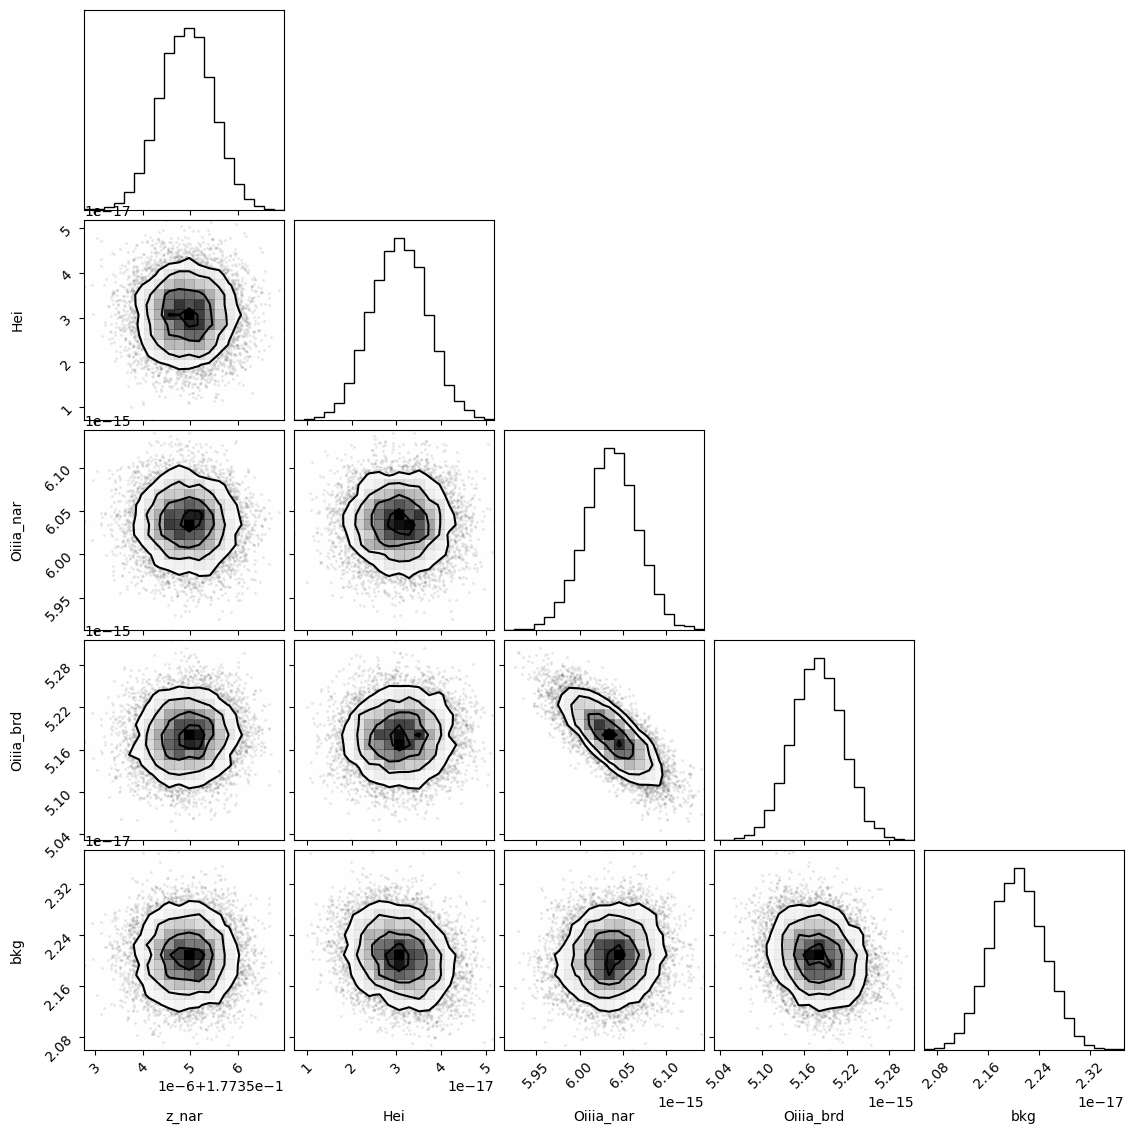

In [92]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [93]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735492,5.5494e-07,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.83944713,,,0.8394471305030831,-inf,inf,False
sigma_brd,1.90298098,,,1.9029809760760037,-inf,inf,False
Hei,3.0711e-17,6.2555e-18,(20.37%),3e-17,0.00000000,inf,True
Oiiia_nar,6.0368e-15,3.0131e-17,(0.50%),7e-15,0.00000000,inf,True
Oiiia_brd,5.1790e-15,3.5887e-17,(0.69%),4e-15,0.00000000,inf,True
bkg,2.2068e-17,4.2337e-19,(1.92%),2e-17,0.00000000,inf,True


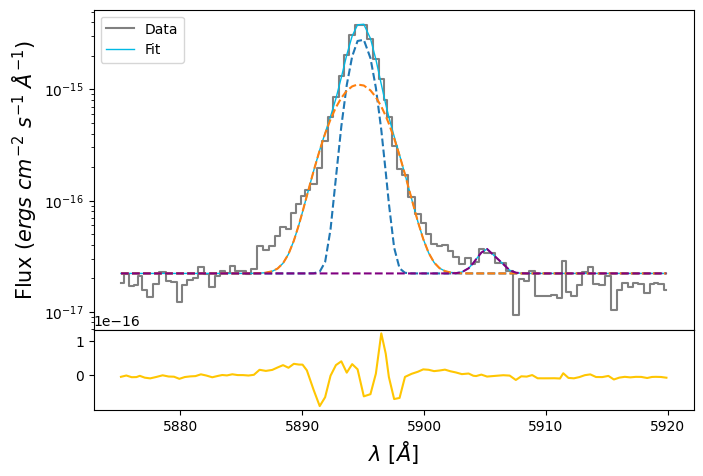

In [94]:
hei_flux = out_oiii_hei.flatchain.Hei.mean()
hei_std = out_oiii_hei.flatchain.Hei.std()

oiiia_nar_flux = out_oiii_hei.flatchain.Oiiia_nar.mean()
oiiia_nar_std = out_oiii_hei.flatchain.Oiiia_nar.std()

oiiia_brd_flux = out_oiii_hei.flatchain.Oiiia_brd.mean()
oiiia_brd_std = out_oiii_hei.flatchain.Oiiia_brd.std()

z_oiii_hei = out_oiii_hei.flatchain.z_nar.mean()
z_oiii_hei_std = out_oiii_hei.flatchain.z_nar.std()

bkg_oiii_hei = out_oiii_hei.flatchain.bkg.mean()
bkg_oiii_hei_std = out_oiii_hei.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, bkg_oiii_hei + hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [95]:
# EW
EW_OIII_5007_nar = ufloat(oiiia_nar_flux, oiiia_nar_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007_brd = ufloat(oiiia_brd_flux, oiiia_brd_std) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)
EW_OIII_5007 = (ufloat(oiiia_nar_flux, oiiia_nar_std) + ufloat(oiiia_brd_flux, oiiia_brd_std)) / ufloat(bkg_oiii_hei, bkg_oiii_hei_std)

# [OIII]4363

In [96]:
sigma_arc_4363 = (m * wave_cat['[OIII]4363']*(1 + z_BN[igal])) + n

sigma_nar_4363 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4363**2))
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

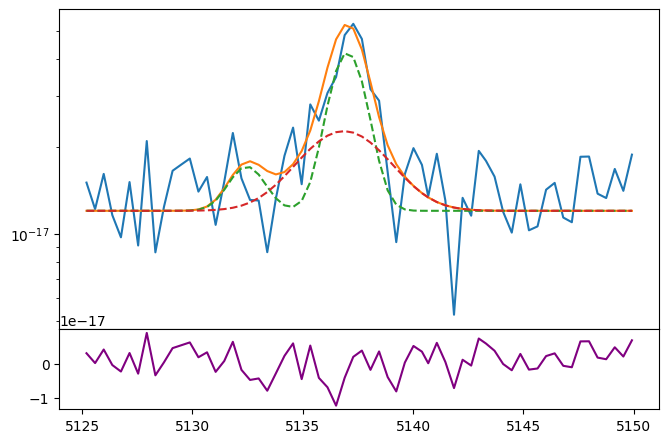

In [97]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)
bkg = 1.2e-17

feii_4360 = gaussian(oiii_4363.wavelength, 0.1e-16, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 6.0e-17, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 5e-17, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, bkg + oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, bkg + oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - bkg - oiiic_nar - oiiic_brd - feii_4360, color='purple')
ax.set_yscale('log')

In [98]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=1.0e-17, min=0.)
params_oiiic.add('Oiiic_nar', value=6.0e-17, min=0.)
params_oiiic.add('Oiiic_brd', value=5.0e-17, min=0.)
params_oiiic.add('bkg', value=1.2e-17, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_nar = params_oiiic['sigma_nar']
    sigma_brd = params_oiiic['sigma_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    bkg = params_oiiic['bkg']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4363.flux) / oiii_4363.noise

In [99]:
np.random.seed(2212)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 127.39it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.05122774 65.99023932 51.79215956 58.79644899 59.67777841]


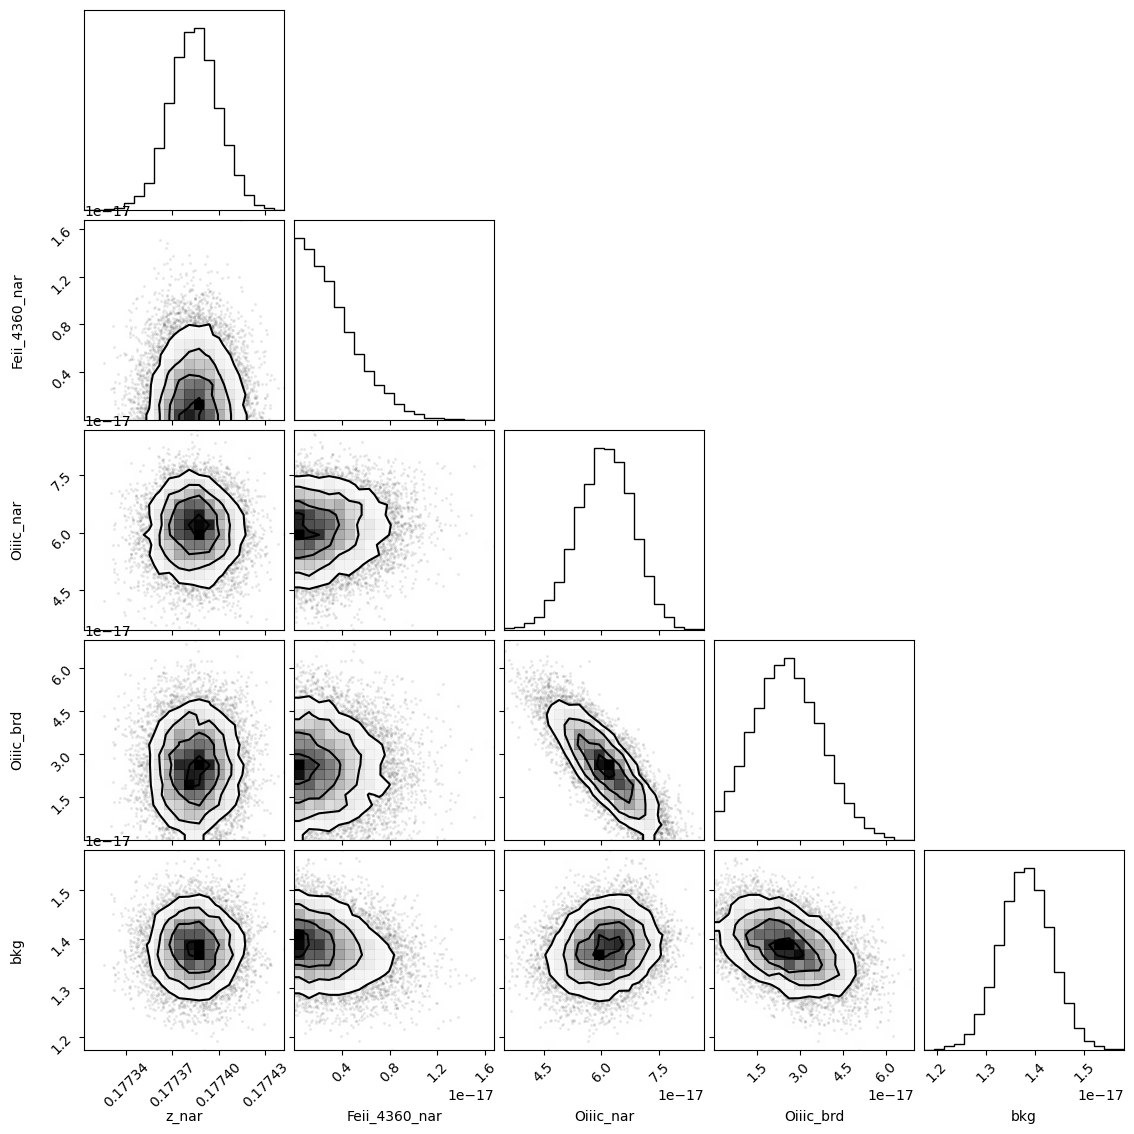

In [100]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [101]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17738420,1.5430e-05,(0.01%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.78872446,,,0.7887244559193638,-inf,inf,False
sigma_brd,1.88115693,,,1.8811569253421194,-inf,inf,False
Feii_4360_nar,2.6357e-18,2.4041e-18,(91.21%),1e-17,0.00000000,inf,True
Oiiic_nar,6.0985e-17,7.2490e-18,(11.89%),6e-17,0.00000000,inf,True
Oiiic_brd,2.5394e-17,1.1994e-17,(47.23%),5e-17,0.00000000,inf,True
bkg,1.3813e-17,5.2112e-19,(3.77%),1.2e-17,0.00000000,inf,True


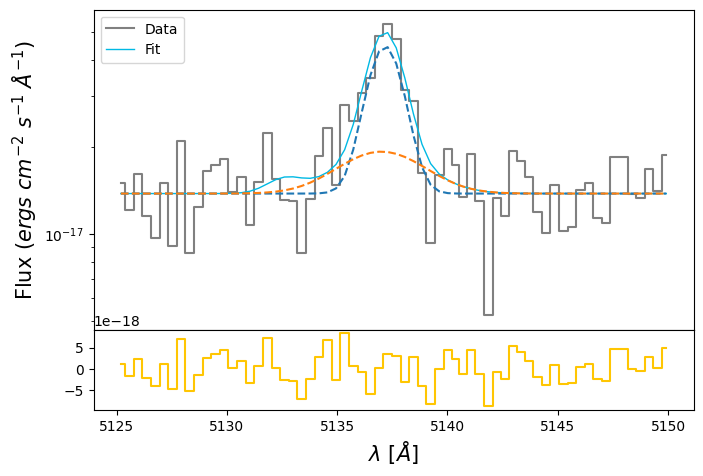

In [102]:
oiiic_nar_flux = out_oiiic.flatchain.Oiiic_nar.mean()
oiiic_nar_std = out_oiiic.flatchain.Oiiic_nar.std()

oiiic_brd_flux = out_oiiic.flatchain.Oiiic_brd.mean()
oiiic_brd_std = out_oiiic.flatchain.Oiiic_brd.std()

feii_4360_flux = out_oiiic.flatchain.Feii_4360_nar.mean()
feii_4360_std = out_oiiic.flatchain.Feii_4360_nar.std()

z_oiii = out_oiiic.flatchain.z_nar.mean()
z_oiii_std = out_oiiic.flatchain.z_nar.std()

bkg_oiiic = out_oiiic.flatchain.bkg.mean()
bkg_oiiic_std = out_oiiic.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_nar, ls='--')
ax.plot(oiii_4363.wavelength, bkg_oiiic + oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - bkg_oiiic - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [103]:
# EW
EW_OIII_4363_nar = ufloat(oiiic_nar_flux, oiiic_nar_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363_brd = ufloat(oiiic_brd_flux, oiiic_brd_std) / ufloat(bkg_oiiic, bkg_oiiic_std)
EW_OIII_4363 = (ufloat(oiiic_nar_flux, oiiic_nar_std) + ufloat(oiiic_brd_flux, oiiic_brd_std)) / ufloat(bkg_oiiic, bkg_oiiic_std)

# [ArIII]7135

In [104]:
sigma_arc_7135 = (m * wave_cat['[ArIII]7135']*(1 + z_BN[igal])) + n

sigma_nar_7135 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7135**2))
sigma_brd_7135 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7135**2))

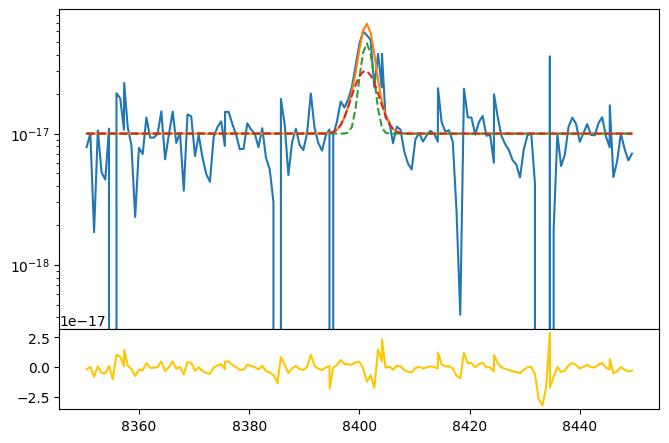

In [105]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ariii_7135.wavelength, ariii_7135.flux)
bkg = 1e-17

ariiia_nar = gaussian(ariii_7135.wavelength, 10e-17, wave_cat['[ArIII]7135'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, 10e-17, wave_cat['[ArIII]7135'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7135))

ax.plot(ariii_7135.wavelength, bkg + ariiia_nar + ariiia_brd)
ax.plot(ariii_7135.wavelength, bkg + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg + ariiia_brd, ls='--')
ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg - ariiia_nar - ariiia_brd, color=c[3])
ax.set_yscale('log')

In [106]:
params_ariii = Parameters()
params_ariii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ariii.add('z_ratio', value=z_ratio, vary=False)
params_ariii.add('sigma_nar', value=upy.nominal_values(sigma_nar_7135), vary=False)
params_ariii.add('sigma_brd', value=upy.nominal_values(sigma_brd_7135), vary=False)
params_ariii.add('Ariiia_nar', value=10e-17, min=0.)
params_ariii.add('Ariiia_brd', value=10e-17, min=0.)
params_ariii.add('bkg', value=1e-17, min=0.)


def residual_ariii(params_ariii, x, data, uncertainty):
    
    z_nar = params_ariii['z_nar']
    z_brd = params_ariii['z_nar'] * params_ariii['z_ratio']
    sigma_nar = params_ariii['sigma_nar']
    sigma_brd = params_ariii['sigma_brd']
    ariiia_nar = params_ariii['Ariiia_nar']
    ariiia_brd = params_ariii['Ariiia_brd']
    bkg = params_ariii['bkg']
    
    x = ariii_7135.wavelength
    model_ariii = gaussian(x, ariiia_nar, wave_cat['[ArIII]7135'], z_nar, sigma_nar) \
                + gaussian(x, ariiia_brd, wave_cat['[ArIII]7135'], z_brd, sigma_brd)
    
    return (model_ariii + bkg - ariii_7135.flux) / ariii_7135.noise

In [107]:
np.random.seed(2212)
out_ariii = minimize(residual_ariii, params_ariii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.57it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [44.88376577 52.53286654 53.65943675 44.67982452]


In [108]:
out_ariii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17734788,1.9138e-05,(0.01%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,1.03084882,,,1.030848819540056,-inf,inf,False
sigma_brd,1.99482190,,,1.9948218965973996,-inf,inf,False
Ariiia_nar,5.2868e-17,1.8117e-17,(34.27%),1e-16,0.00000000,inf,True
Ariiia_brd,1.6073e-16,2.3129e-17,(14.39%),1e-16,0.00000000,inf,True
bkg,9.2443e-18,2.5183e-19,(2.72%),1e-17,0.00000000,inf,True


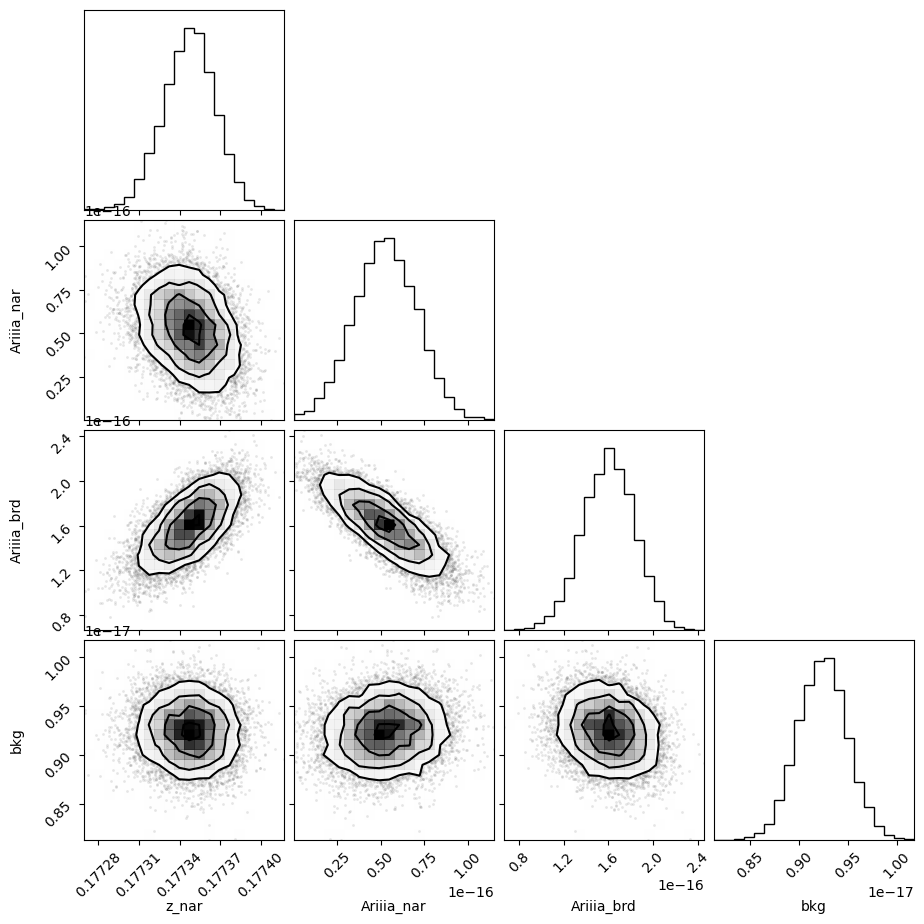

In [109]:
corner.corner(out_ariii.flatchain, labels=out_ariii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

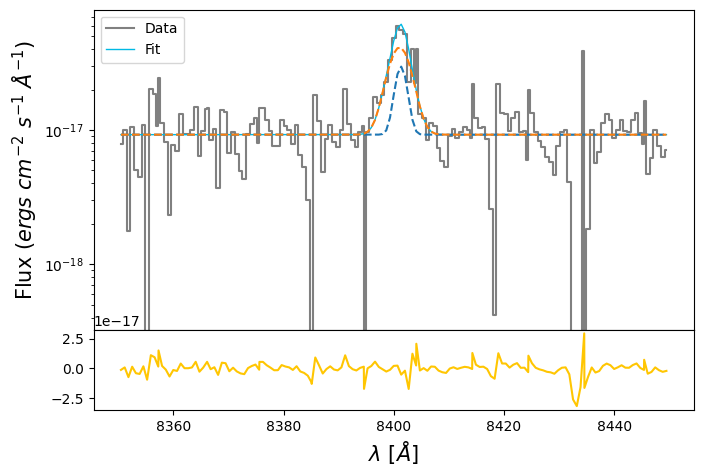

In [110]:
ariiia_nar_flux = out_ariii.flatchain.Ariiia_nar.mean()
ariiia_nar_std = out_ariii.flatchain.Ariiia_nar.std()

ariiia_brd_flux = out_ariii.flatchain.Ariiia_brd.mean()
ariiia_brd_std = out_ariii.flatchain.Ariiia_brd.std()

z_ariii = out_ariii.flatchain.z_nar.mean()
z_ariii_std = out_ariii.flatchain.z_nar.std()

bkg_ariii = out_ariii.flatchain.bkg.mean()
bkg_ariii_std = out_ariii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ariii_7135.wavelength, ariii_7135.flux,
            color='gray', label='Data', where='mid')

ariiia_nar = gaussian(ariii_7135.wavelength, ariiia_nar_flux, wave_cat['[ArIII]7135'], z_ariii, upy.nominal_values(sigma_nar_7135))
ariiia_brd = gaussian(ariii_7135.wavelength, ariiia_brd_flux, wave_cat['[ArIII]7135'], z_ariii * z_ratio, upy.nominal_values(sigma_brd_7135))

ariiia = ariiia_nar + ariiia_brd

ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia,
        lw=1, color=c[0], label='Fit')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_nar, ls='--')
ax.plot(ariii_7135.wavelength, bkg_ariii + ariiia_brd, ls='--')

ax1.plot(ariii_7135.wavelength, ariii_7135.flux - bkg_ariii - ariiia,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [111]:
# EW
EW_ArIII_7135_nar = ufloat(ariiia_nar_flux, ariiia_nar_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135_brd = ufloat(ariiia_brd_flux, ariiia_brd_std) / ufloat(bkg_ariii, bkg_ariii_std)
EW_ArIII_7135 = (ufloat(ariiia_nar_flux, ariiia_nar_std) + ufloat(ariiia_brd_flux, ariiia_brd_std)) / ufloat(bkg_ariii, bkg_ariii_std)

# [FeIII]4658

In [112]:
sigma_arc_4658 = (m * wave_cat['[FeIII]4658']*(1 + z_BN[igal])) + n

sigma_nar_4658 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4658**2))
sigma_brd_4658 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4658**2))

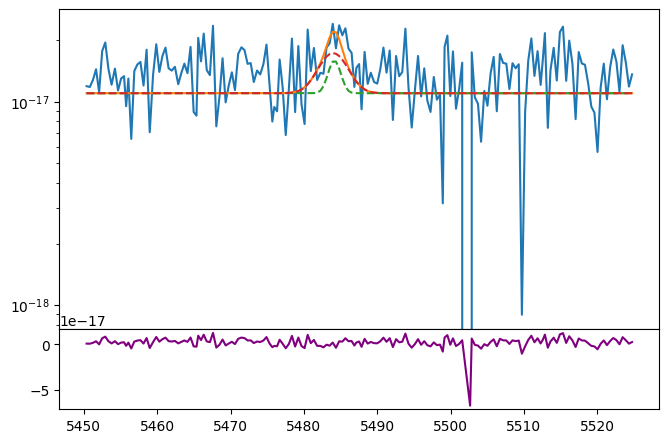

In [113]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(feiii_4658.wavelength, feiii_4658.flux)
bkg = 1.1e-17

feiiia_nar = gaussian(feiii_4658.wavelength, 1e-17, wave_cat['[FeIII]4658'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4658))
feiiia_brd = gaussian(feiii_4658.wavelength, 3e-17, wave_cat['[FeIII]4658'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4658))

ax.plot(feiii_4658.wavelength, bkg + feiiia_nar + feiiia_brd)
ax.plot(feiii_4658.wavelength, bkg + feiiia_nar, ls='--')
ax.plot(feiii_4658.wavelength, bkg + feiiia_brd, ls='--')
ax1.plot(feiii_4658.wavelength, feiii_4658.flux - bkg - feiiia_nar - feiiia_brd, color='purple')
ax.set_yscale('log')

In [114]:
params_feiiia = Parameters()

params_feiiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_feiiia.add('z_ratio', value=z_ratio, vary=False)
params_feiiia.add('sigma_nar', value=upy.nominal_values(sigma_nar_4658), vary=False)
params_feiiia.add('sigma_brd', value=upy.nominal_values(sigma_brd_4658), vary=False)
params_feiiia.add('Feiiia_nar', value=1e-17, min=0.)
params_feiiia.add('Feiiia_brd', value=3e-17, min=0.)
params_feiiia.add('bkg', value=1.1e-17, min=0.)


def residual_feiiia(params_feiiia, x, data, uncertainty):
    
    z_nar = params_feiiia['z_nar']
    z_brd = params_feiiia['z_nar'] * params_feiiia['z_ratio']
    sigma_nar = params_feiiia['sigma_nar']
    sigma_brd = params_feiiia['sigma_brd']
    feiiia_nar_flux = params_feiiia['Feiiia_nar']
    feiiia_brd_flux = params_feiiia['Feiiia_brd']
    bkg = params_feiiia['bkg']
    
    x = feiii_4658.wavelength
    model = gaussian(x, feiiia_nar_flux, wave_cat['[FeIII]4658'], z_nar, sigma_nar) + \
            gaussian(x, feiiia_brd_flux, wave_cat['[FeIII]4658'], z_brd, sigma_brd)
    
    return (model + bkg - feiii_4658.flux) / feiii_4658.noise

In [115]:
np.random.seed(2212)
out_feiiia = minimize(residual_feiiia, params_feiiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 136.82it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [41.10447807 46.86242385 49.26905473 58.88649203]


In [116]:
out_feiiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17748610,8.0033e-05,(0.05%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.81144316,,,0.811443155292978,-inf,inf,False
sigma_brd,1.89079483,,,1.8907948341026173,-inf,inf,False
Feiiia_nar,1.0817e-17,6.7161e-18,(62.09%),1e-17,0.00000000,inf,True
Feiiia_brd,1.7952e-17,1.0200e-17,(56.82%),3e-17,0.00000000,inf,True
bkg,1.3695e-17,2.9656e-19,(2.17%),1.1e-17,0.00000000,inf,True


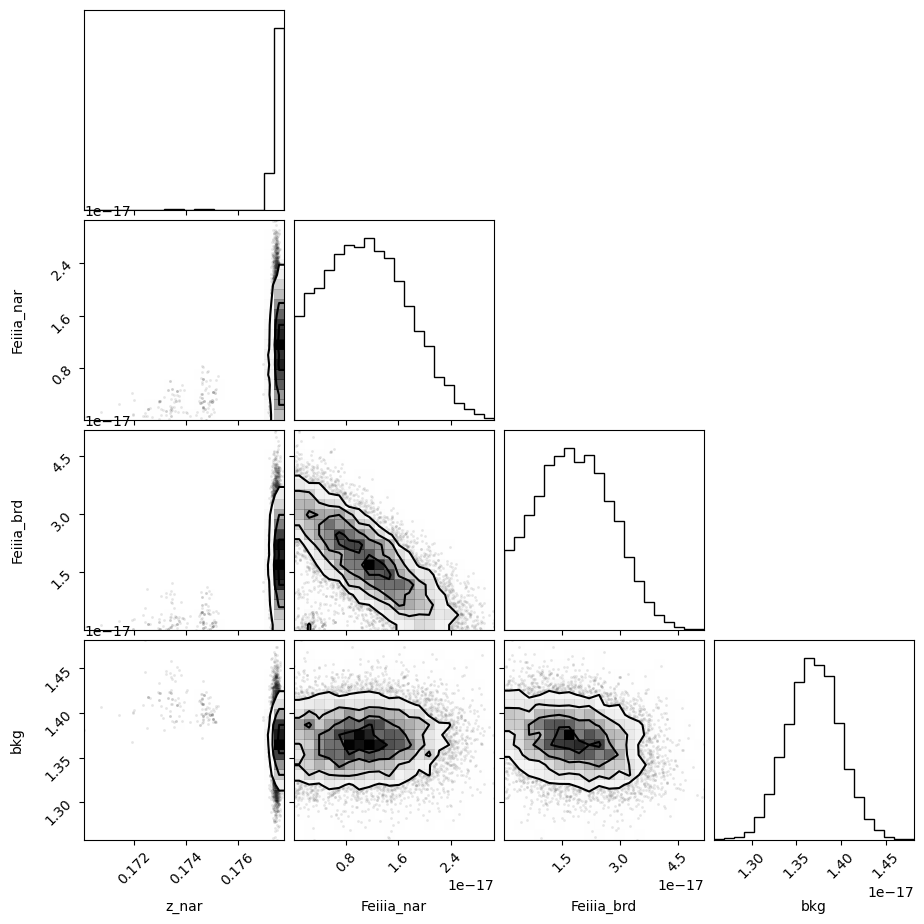

In [117]:
corner.corner(out_feiiia.flatchain, labels=out_feiiia.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

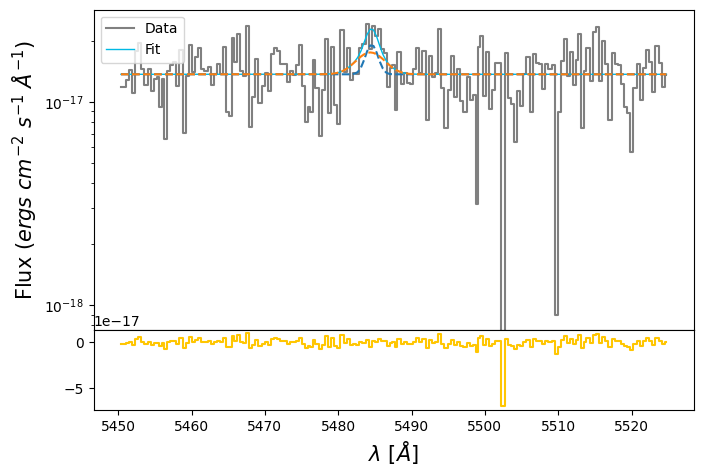

In [118]:
feiiia_nar_flux = out_feiiia.flatchain.Feiiia_nar.mean()
feiiia_nar_std = out_feiiia.flatchain.Feiiia_nar.std()

feiiia_brd_flux = out_feiiia.flatchain.Feiiia_brd.mean()
feiiia_brd_std = out_feiiia.flatchain.Feiiia_brd.std()

z_feiiia = out_feiiia.flatchain.z_nar.mean()
z_feiiia_std = out_feiiia.flatchain.z_nar.std()

bkg_feiiia = out_feiiia.flatchain.bkg.mean()
bkg_feiiia_std = out_feiiia.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(feiii_4658.wavelength, feiii_4658.flux,
            color='gray', label='Data', where='mid')

feiiia_nar = gaussian(feiii_4658.wavelength, feiiia_nar_flux, wave_cat['[FeIII]4658'], z_feiiia, upy.nominal_values(sigma_nar_4658))
feiiia_brd = gaussian(feiii_4658.wavelength, feiiia_brd_flux, wave_cat['[FeIII]4658'], z_feiiia * z_ratio, upy.nominal_values(sigma_brd_4658))
feiiia = feiiia_nar + feiiia_brd

ax.plot(feiii_4658.wavelength, bkg_feiiia + feiiia, lw=1, color=c[0], label='Fit')
ax.plot(feiii_4658.wavelength, bkg_feiiia + feiiia_nar, ls='--')
ax.plot(feiii_4658.wavelength, bkg_feiiia + feiiia_brd, ls='--')
ax1.step(feiii_4658.wavelength, feiii_4658.flux - bkg_feiiia - feiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [119]:
# EW
EW_FeIII_4658_nar = ufloat(feiiia_nar_flux, feiiia_nar_std) / ufloat(bkg_feiiia, bkg_feiiia_std)
EW_FeIII_4658_brd = ufloat(feiiia_brd_flux, feiiia_brd_std) / ufloat(bkg_feiiia, bkg_feiiia_std)
EW_FeIII_4658 = (ufloat(feiiia_nar_flux, feiiia_nar_std) + ufloat(feiiia_brd_flux, feiiia_brd_std)) / ufloat(bkg_feiiia, bkg_feiiia_std)

# [NeIII]3868

In [120]:
sigma_arc_3868 = (m * wave_cat['[NeIII]3868']*(1 + z_BN[igal])) + n

sigma_nar_3868 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3868**2))
sigma_brd_3868 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3868**2))

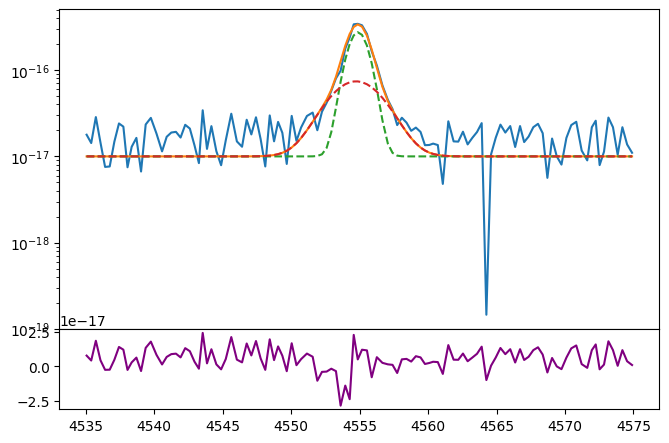

In [121]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(neiii_3868.wavelength, neiii_3868.flux)
bkg = 1e-17

neiiia_nar = gaussian(neiii_3868.wavelength, 50e-17, wave_cat['[NeIII]3868'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, 30e-17, wave_cat['[NeIII]3868'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3868))

ax.plot(neiii_3868.wavelength, bkg + neiiia_nar + neiiia_brd)
ax.plot(neiii_3868.wavelength, bkg + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg + neiiia_brd, ls='--')
ax1.plot(neiii_3868.wavelength, neiii_3868.flux - bkg - neiiia_nar - neiiia_brd, color='purple')
ax.set_yscale('log')

In [122]:
params_neiii_3868 = Parameters()
params_neiii_3868.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_neiii_3868.add('z_ratio', value=z_ratio, vary=False)
params_neiii_3868.add('sigma_nar', value=upy.nominal_values(sigma_nar_3868), vary=False)
params_neiii_3868.add('sigma_brd', value=upy.nominal_values(sigma_brd_3868), vary=False)
params_neiii_3868.add('Neiiia_nar', value=50e-17, min=0.)
params_neiii_3868.add('Neiiia_brd', value=30e-17, min=0.)
params_neiii_3868.add('bkg', value=1e-17, min=0.)


def residual_neiii_3868(params_neiii_3868, x, data, uncertainty):
    
    z_nar = params_neiii_3868['z_nar']
    z_brd = params_neiii_3868['z_nar'] * params_neiii_3868['z_ratio']
    sigma_nar = params_neiii_3868['sigma_nar']
    sigma_brd = params_neiii_3868['sigma_brd']
    neiiia_nar_flux = params_neiii_3868['Neiiia_nar']
    neiiia_brd_flux = params_neiii_3868['Neiiia_brd']
    bkg = params_neiii_3868['bkg']
    
    x = neiii_3868.wavelength
    model = gaussian(x, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_nar, sigma_nar) + \
            gaussian(x, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_brd, sigma_brd)
    
    return (model + bkg - neiii_3868.flux) / neiii_3868.noise

In [123]:
np.random.seed(2212)
out_neiii_3868 = minimize(residual_neiii_3868, params_neiii_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10, nwalkers=100)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 130.92it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [39.06133451 48.66060559 57.45761438 66.32408687]


In [124]:
out_neiii_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17736237,4.2874e-06,(0.00%),0.17735090032776832,-inf,inf,True
z_ratio,0.99979010,,,0.9997901030961868,-inf,inf,False
sigma_nar,0.75281355,,,0.752813550020819,-inf,inf,False
sigma_brd,1.86638510,,,1.8663851026763656,-inf,inf,False
Neiiia_nar,5.3758e-16,1.5666e-17,(2.91%),5e-16,0.00000000,inf,True
Neiiia_brd,2.0072e-16,2.2339e-17,(11.13%),3e-16,0.00000000,inf,True
bkg,1.6883e-17,6.9675e-19,(4.13%),1e-17,0.00000000,inf,True


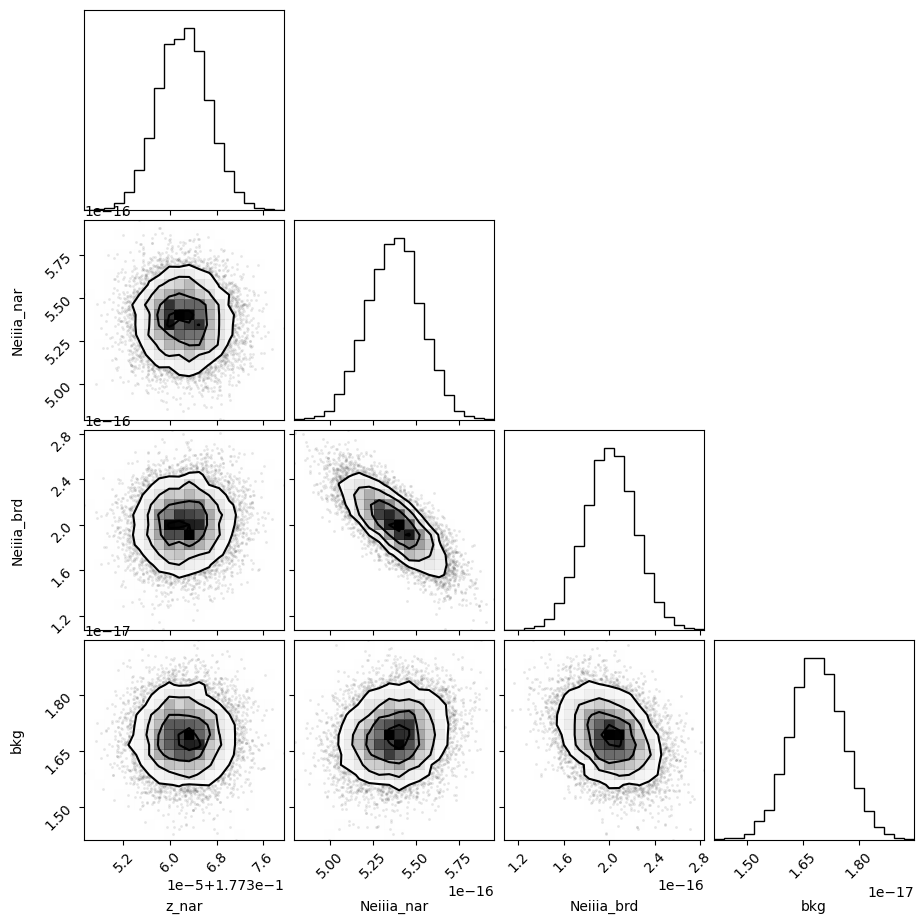

In [125]:
corner.corner(out_neiii_3868.flatchain, labels=out_neiii_3868.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

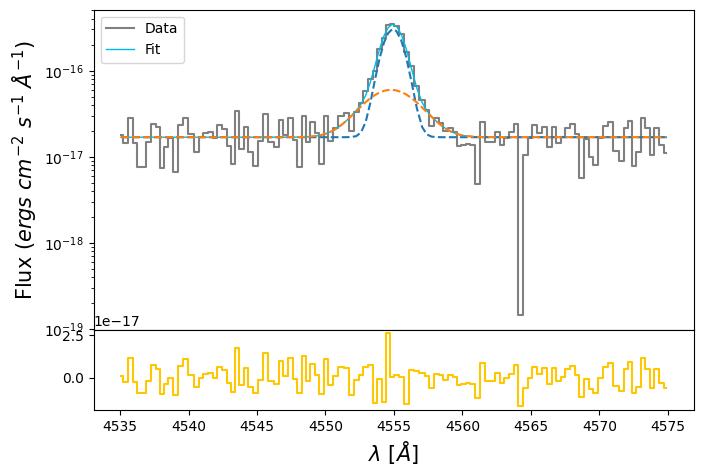

In [126]:
neiiia_nar_flux = out_neiii_3868.flatchain.Neiiia_nar.mean()
neiiia_nar_std = out_neiii_3868.flatchain.Neiiia_nar.std()

neiiia_brd_flux = out_neiii_3868.flatchain.Neiiia_brd.mean()
neiiia_brd_std = out_neiii_3868.flatchain.Neiiia_brd.std()

z_neiii = out_neiii_3868.flatchain.z_nar.mean()
z_neiii_std = out_neiii_3868.flatchain.z_nar.std()

bkg_neiiia = out_neiii_3868.flatchain.bkg.mean()
bkg_neiiia_std = out_neiii_3868.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(neiii_3868.wavelength, neiii_3868.flux,
            color='gray', label='Data', where='mid')

neiiia_nar = gaussian(neiii_3868.wavelength, neiiia_nar_flux, wave_cat['[NeIII]3868'], z_neiii, upy.nominal_values(sigma_nar_3868))
neiiia_brd = gaussian(neiii_3868.wavelength, neiiia_brd_flux, wave_cat['[NeIII]3868'], z_neiii * z_ratio, upy.nominal_values(sigma_brd_3868))
neiiia = neiiia_nar + neiiia_brd

ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia, lw=1, color=c[0], label='Fit')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_nar, ls='--')
ax.plot(neiii_3868.wavelength, bkg_neiiia + neiiia_brd, ls='--')
ax1.step(neiii_3868.wavelength, neiii_3868.flux - bkg_neiiia - neiiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')

In [127]:
# EW
EW_NeIII_3868_nar = ufloat(neiiia_nar_flux, neiiia_nar_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868_brd = ufloat(neiiia_brd_flux, neiiia_brd_std) / ufloat(bkg_neiiia, bkg_neiiia_std)
EW_NeIII_3868 = (ufloat(neiiia_nar_flux, neiiia_nar_std) + ufloat(neiiia_brd_flux, neiiia_brd_std)) / ufloat(bkg_neiiia, bkg_neiiia_std)

# Balmer decrements

In [128]:
from magE.functions import *
from magE.functions import calzetti2000 as k_cal

flux_ha_bal = ufloat(out_ha_nii.flatchain.Ha_nar.mean(), out_ha_nii.flatchain.Ha_nar.std()) \
            + ufloat(out_ha_nii.flatchain.Ha_brd.mean(), out_ha_nii.flatchain.Ha_brd.std())
flux_hb_bal = ufloat(out_hb.flatchain.Hb_nar.mean(), out_hb.flatchain.Hb_nar.std()) \
            + ufloat(out_hb.flatchain.Hb_brd.mean(), out_hb.flatchain.Hb_brd.std())
flux_hg_bal = ufloat(out_hg.flatchain.Hg_nar.mean(), out_hg.flatchain.Hg_nar.std()) \
            + ufloat(out_hg.flatchain.Hg_brd.mean(), out_hg.flatchain.Hg_brd.std())
flux_hd_bal = ufloat(out_hd.flatchain.Hd_nar.mean(), out_hd.flatchain.Hd_nar.std()) \
            + ufloat(out_hd.flatchain.Hd_brd.mean(), out_hd.flatchain.Hd_brd.std())

y_balmer = upy.log10([(flux_ha_bal / flux_hb_bal) / 2.86, 
                    (flux_hb_bal / flux_hb_bal) / 1.0,
                    (flux_hg_bal / flux_hb_bal) / 0.464,
                    (flux_hd_bal / flux_hb_bal) / 0.256])

x_balmer = np.array([k_cal(wave_cat['Ha']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hb']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hg']) - k_cal(wave_cat['Hb']),
                     k_cal(wave_cat['Hd']) - k_cal(wave_cat['Hb'])])

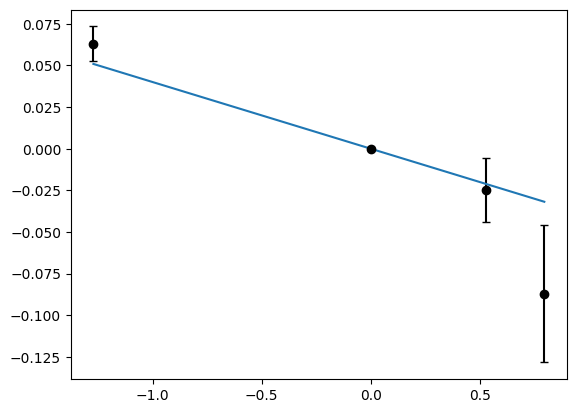

In [129]:
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), 2*upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, x_balmer * (-0.4 * 0.1))

In [130]:
mask_balmer = (y_balmer != 0)

params_balmer = Parameters()
params_balmer.add('slope', value=0.4 * 0.2)

def residuals_balmer(params_balmer, x, data, uncertainty):
    
    slope = params_balmer['slope']
    x = x_balmer[mask_balmer]
    
    model = x * (-slope)
    return (model - upy.nominal_values(y_balmer[mask_balmer])) / upy.std_devs(y_balmer[mask_balmer])

np.random.seed(2212)
out_balmer = minimize(residuals_balmer, params_balmer, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 146.59it/s]


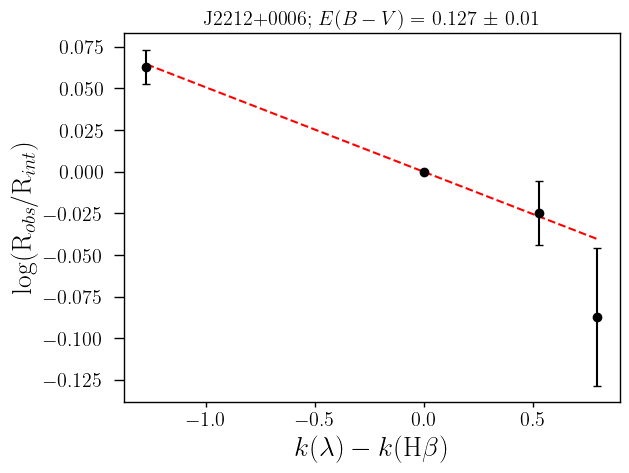

In [131]:
color_excess = ufloat(out_balmer.flatchain.slope.mean(), out_balmer.flatchain.slope.std()) / 0.4
E_BV = out_balmer.flatchain.slope.mean() / 0.4

texPlot('on')
plt.errorbar(x_balmer, upy.nominal_values(y_balmer), 2*upy.std_devs(y_balmer),
            ls='', color='black', marker='o', capsize=3)
plt.plot(x_balmer, - E_BV * 0.4 * x_balmer, ls='--', color='red')
plt.ylabel(r'log(R$_{obs}$/R$_{int}$)')
plt.xlabel(r'$k(\lambda) - k($H$\beta)$')
plt.title(r'J2212+0006; $E(B-V) = $ '+str(round(color_excess.nominal_value, 3))+' $\pm$ '+str(round(color_excess.std_dev, 3)))
plt.savefig('/home/benjamin/Documents/analogs/results/balmer_decrements/bal_dec_J2212.pdf', bbox_inches='tight')

In [132]:
decrement_dict = {'galname': galname,
                 'Ha/Hb': (flux_ha_bal / flux_hb_bal).nominal_value,
                 'Ha/Hb_err': (flux_ha_bal / flux_hb_bal).std_dev,
                 'Hg/Hb': (flux_hg_bal / flux_hb_bal).nominal_value,
                 'Hg/Hb_err': (flux_hg_bal / flux_hb_bal).std_dev,
                 'Hd/Hb': (flux_hd_bal / flux_hb_bal).nominal_value,
                 'Hd/Hb_err': (flux_hd_bal / flux_hb_bal).std_dev,
                 'E_BV': out_balmer.flatchain.slope.mean() / 0.4,
                 'E_BV_err': out_balmer.flatchain.slope.std() / 0.4
                 }
decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
save_catalog(galname, decrement_dict_pd, magePath + '/results/bal_decrements.csv')

Existent catalog (.csv) file.
Existent data for J2212, overwriting...
Done.


# Temperatures

In [133]:
feiiia_nar_chain = out_feiiia.flatchain.Feiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[FeIII]4658']))
feiiia_brd_chain = out_feiiia.flatchain.Feiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[FeIII]4658']))
feiiia_tot_chain = feiiia_nar_chain + feiiia_brd_chain

neiiia_nar_chain = out_neiii_3868.flatchain.Neiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[NeIII]3868']))
neiiia_brd_chain = out_neiii_3868.flatchain.Neiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[NeIII]3868']))
neiiia_tot_chain = neiiia_nar_chain + neiiia_brd_chain

ariiia_nar_chain = out_ariii.flatchain.Ariiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[ArIII]7135']))
ariiia_brd_chain = out_ariii.flatchain.Ariiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[ArIII]7135']))
ariiia_tot_chain = ariiia_nar_chain + ariiia_brd_chain

oiiia_nar_chain = out_oiii_hei.flatchain.Oiiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_brd_chain = out_oiii_hei.flatchain.Oiiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_tot_chain = oiiia_nar_chain + oiiia_brd_chain

oiiib_nar_chain = out_oiii_4959.flatchain.Oiiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_brd_chain = out_oiii_4959.flatchain.Oiiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_tot_chain = oiiib_nar_chain + oiiib_brd_chain

oiiic_nar_chain = out_oiiic.flatchain.Oiiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_brd_chain = out_oiiic.flatchain.Oiiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_tot_chain = oiiic_nar_chain + oiiic_brd_chain

siia_nar_chain = out_sii.flatchain.Siia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_brd_chain = out_sii.flatchain.Siia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_tot_chain = siia_nar_chain + siia_brd_chain

siib_nar_chain = out_sii.flatchain.Siib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_brd_chain = out_sii.flatchain.Siib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_tot_chain = siib_nar_chain + siib_brd_chain

oiia_nar_chain = out_oii_7320.flatchain.Oiia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_brd_chain = out_oii_7320.flatchain.Oiia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_tot_chain = oiia_nar_chain + oiia_brd_chain

oiib_nar_chain = out_oii_7320.flatchain.Oiib_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_brd_chain = out_oii_7320.flatchain.Oiib_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_tot_chain = oiib_nar_chain + oiib_brd_chain

oiic_nar_chain = out_oii_3727.flatchain.Oiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_brd_chain = out_oii_3727.flatchain.Oiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_tot_chain = oiic_nar_chain + oiic_brd_chain

oiid_nar_chain = out_oii_3727.flatchain.Oiid_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_brd_chain = out_oii_3727.flatchain.Oiid_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_tot_chain = oiid_nar_chain + oiid_brd_chain

siiic_nar_chain = out_oi_siii.flatchain.Siiic_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_brd_chain = out_oi_siii.flatchain.Siiic_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_tot_chain = siiic_nar_chain + siiic_brd_chain

oia_nar_chain = out_oi_siii.flatchain.Oi_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[OI]6300']))
oia_brd_chain = out_oi_siii.flatchain.Oi_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[OI]6300']))
oia_tot_chain = oia_nar_chain + oia_brd_chain

niia_nar_chain = out_ha_nii.flatchain.Niia_nar * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_brd_chain = out_ha_nii.flatchain.Niia_brd * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_tot_chain = niia_nar_chain + niia_brd_chain

niib_nar_chain = out_ha_nii.flatchain.Niia_nar * out_ha_nii.flatchain.Niib_to_niia * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_brd_chain = out_ha_nii.flatchain.Niia_brd * out_ha_nii.flatchain.Niib_to_niia * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_tot_chain = niib_nar_chain + niib_brd_chain

hd_nar_chain = out_hd.flatchain.Hd_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hd']))
hd_brd_chain = out_hd.flatchain.Hd_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hd']))
hd_tot_chain = hd_nar_chain + hd_brd_chain

hg_nar_chain = out_hg.flatchain.Hg_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hg']))
hg_brd_chain = out_hg.flatchain.Hg_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hg']))
hg_tot_chain = hg_nar_chain + hg_brd_chain

hb_nar_chain = out_hb.flatchain.Hb_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_brd_chain = out_hb.flatchain.Hb_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_tot_chain = hb_nar_chain + hb_brd_chain

ha_nar_chain = out_ha_nii.flatchain.Ha_nar * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_brd_chain = out_ha_nii.flatchain.Ha_brd * 10**(0.4 * E_BV * k_cal(wave_cat['Ha']))
ha_tot_chain = ha_nar_chain + ha_brd_chain

In [134]:
chains_dict = {'[OII]3726_nar': oiid_nar_chain.to_numpy(),
               '[OII]3726_brd': oiid_brd_chain.to_numpy(),
               '[OII]3726': oiid_tot_chain.to_numpy(),
               
               '[OII]3729_nar': oiic_nar_chain.to_numpy(),
               '[OII]3729_brd': oiic_brd_chain.to_numpy(),
               '[OII]3729': oiic_tot_chain.to_numpy(),
               
               '[NeIII]3868_nar': neiiia_nar_chain.to_numpy(),
               '[NeIII]3868_brd': neiiia_brd_chain.to_numpy(),
               '[NeIII]3868': neiiia_tot_chain.to_numpy(),
               
               'Hd_nar': hd_nar_chain.to_numpy(),
               'Hd_brd': hd_brd_chain.to_numpy(),
               'Hd': hd_tot_chain.to_numpy(),
               
               'Hg_nar': hg_nar_chain.to_numpy(),
               'Hg_brd': hg_brd_chain.to_numpy(),
               'Hg': hg_tot_chain.to_numpy(),
               
               '[OIII]4363_nar': oiiic_nar_chain.to_numpy(),
               '[OIII]4363_brd': oiiic_brd_chain.to_numpy(),
               '[OIII]4363': oiiic_tot_chain.to_numpy(),
               
               'HeI4471_nar': np.nan * np.ones(10000),
               'HeI4471_brd': np.nan * np.ones(10000),
               'HeI4471': np.nan * np.ones(10000),
               
               '[FeIII]4658_nar': feiiia_nar_chain.to_numpy(),
               '[FeIII]4658_brd': feiiia_brd_chain.to_numpy(),
               '[FeIII]4658': feiiia_tot_chain.to_numpy(),
               
               'HeII4686_nar': np.nan * np.ones(10000),
               'HeII4686_brd': np.nan * np.ones(10000),
               'HeII4686': np.nan * np.ones(10000),
               
               '[ArIV]4740_nar': np.nan * np.ones(10000),
               '[ArIV]4740_brd': np.nan * np.ones(10000),
               '[ArIV]4740': np.nan * np.ones(10000),
               
               'Hb_nar': hb_nar_chain.to_numpy(),
               'Hb_brd': hb_brd_chain.to_numpy(),
               'Hb': hb_tot_chain.to_numpy(),
               
               '[OIII]4959_nar': oiiib_nar_chain.to_numpy(),
               '[OIII]4959_brd': oiiib_brd_chain.to_numpy(),
               '[OIII]4959': oiiib_tot_chain.to_numpy(),
               
               '[OIII]5007_nar': oiiia_nar_chain.to_numpy(),
               '[OIII]5007_brd': oiiia_brd_chain.to_numpy(),
               '[OIII]5007': oiiia_tot_chain.to_numpy(),
               
               '[NII]5755_nar': np.nan * np.ones(10000),
               '[NII]5755_brd': np.nan * np.ones(10000),
               '[NII]5755': np.nan * np.ones(10000),
               
               'HeI5875_nar': np.nan * np.ones(10000),
               'HeI5875_brd': np.nan * np.ones(10000),
               'HeI5875': np.nan * np.ones(10000),
               
               '[OI]6300_nar': oia_nar_chain.to_numpy(),
               '[OI]6300_brd': oia_brd_chain.to_numpy(),
               '[OI]6300': oia_tot_chain.to_numpy(),
               
               '[SIII]6312_nar': siiic_nar_chain.to_numpy(),
               '[SIII]6312_brd': siiic_brd_chain.to_numpy(),
               '[SIII]6312': siiic_tot_chain.to_numpy(),
               
               '[NII]6548_nar': niib_nar_chain.to_numpy(),
               '[NII]6548_brd': niib_brd_chain.to_numpy(),
               '[NII]6548': niib_tot_chain.to_numpy(),
               
               'Ha_nar': ha_nar_chain.to_numpy(),
               'Ha_brd': ha_brd_chain.to_numpy(),
               'Ha': ha_tot_chain.to_numpy(),
               
               '[NII]6584_nar': niia_nar_chain.to_numpy(),
               '[NII]6584_brd': niia_brd_chain.to_numpy(),
               '[NII]6584': niia_tot_chain.to_numpy(),
               
               'HeI6678_nar': np.nan * np.ones(10000),
               'HeI6678_brd': np.nan * np.ones(10000),
               'HeI6678': np.nan * np.ones(10000),
               
               '[SII]6716_nar': siib_nar_chain.to_numpy(),
               '[SII]6716_brd': siib_brd_chain.to_numpy(),
               '[SII]6716': siib_tot_chain.to_numpy(),
               
               '[SII]6730_nar': siia_nar_chain.to_numpy(),
               '[SII]6730_brd': siia_brd_chain.to_numpy(),
               '[SII]6730': siia_tot_chain.to_numpy(),
               
               'HeI7065_nar': np.nan * np.ones(10000),
               'HeI7065_brd': np.nan * np.ones(10000),
               'HeI7065': np.nan * np.ones(10000),
               
               '[ArIII]7135_nar': ariiia_nar_chain.to_numpy(),
               '[ArIII]7135_brd': ariiia_brd_chain.to_numpy(),
               '[ArIII]7135': ariiia_tot_chain.to_numpy(),
               
               '[OII]7319_nar': oiib_nar_chain.to_numpy(),
               '[OII]7319_brd': oiib_brd_chain.to_numpy(),
               '[OII]7319': oiib_tot_chain.to_numpy(),
               
               '[OII]7330_nar': oiia_nar_chain.to_numpy(),
               '[OII]7330_brd': oiia_brd_chain.to_numpy(),
               '[OII]7330': oiia_tot_chain.to_numpy(),
               
               '[SIII]9069_nar': np.nan * np.ones(10000),
               '[SIII]9069_brd': np.nan * np.ones(10000),
               '[SIII]9069': np.nan * np.ones(10000),
               
               '[SIII]9532_nar': np.nan * np.ones(10000),
               '[SIII]9532_brd': np.nan * np.ones(10000),
               '[SIII]9532': np.nan * np.ones(10000)
}
chains_dict_pd = pd.DataFrame(data=chains_dict, index=None)
chains_dict_pd.to_csv('/home/benjamin/Documents/chains/chains_J2212.csv')
#save_catalog(galname, chains_dict_pd, '/home/benjamin/Documents/chains/chains_J0021.csv')

In [135]:
lines_dict = {'galname': galname,
              '[OII]3726': oiid_tot_chain.mean(),
              '[OII]3726_err': oiid_tot_chain.std(),
              '[OII]3729': oiic_tot_chain.mean(),
              '[OII]3729_err': oiic_tot_chain.std(),
              '[NeIII]3868': neiiia_tot_chain.mean(),
              '[NeIII]3868_err': neiiia_tot_chain.std(),
              'Hd': hd_tot_chain.mean(),
              'Hd_err': hd_tot_chain.std(),
              'Hg': hg_tot_chain.mean(),
              'Hg_err': hg_tot_chain.std(),
              '[OIII]4363': oiiic_tot_chain.mean(),
              '[OIII]4363_err': oiiic_tot_chain.std(),
              'HeI4471': None,
              'HeI4471_err': None,
              '[FeIII]4658': feiiia_tot_chain.mean(),
              '[FeIII]4658_err': feiiia_tot_chain.std(),
              'HeII4686': None,
              'HeII4686_err': None,
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              'Hb': hb_tot_chain.mean(),
              'Hb_err': hb_tot_chain.std(),
              '[OIII]4959': oiiib_tot_chain.mean(),
              '[OIII]4959_err': oiiib_tot_chain.std(),
              '[OIII]5007': oiiia_tot_chain.mean(),
              '[OIII]5007_err': oiiia_tot_chain.std(),
              '[NII]5575': None,
              '[NII]5575_err': None,
              'HeI5875': None,
              'HeI5875_err': None,
              '[OI]6300': oia_tot_chain.mean(),
              '[OI]6300_err': oia_tot_chain.std(),
              '[SIII]6312': siiic_tot_chain.mean(),
              '[SIII]6312_err': siiic_tot_chain.std(),
              '[NII]6548': niib_tot_chain.mean(),
              '[NII]6548_err': niib_tot_chain.std(),
              'Ha': ha_tot_chain.mean(),
              'Ha_err': ha_tot_chain.std(),
              '[NII]6584': niia_tot_chain.mean(),
              '[NII]6584_err': niia_tot_chain.std(),
              'HeI6678': None,
              'HeI6678_err': None,
              '[SII]6716': siib_tot_chain.mean(),
              '[SII]6716_err': siib_tot_chain.std(),
              '[SII]6730': siia_tot_chain.mean(),
              '[SII]6730_err': siia_tot_chain.std(),
              'HeI7065': None,
              'HeI7065_err': None,
              '[ArIII]7135': ariiia_tot_chain.mean(),
              '[ArIII]7135_err': ariiia_tot_chain.std(),
              '[OII]7319': oiib_tot_chain.mean(),
              '[OII]7319_err': oiib_tot_chain.std(),
              '[OII]7330': oiia_tot_chain.mean(),
              '[OII]7330_err': oiia_tot_chain.std(),
              '[SIII]9069': None,
              '[SIII]9069_err': None,
              '[SIII]9532': None,
              '[SIII]9532_err': None
              
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/em_lines_final.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


In [128]:
lines_dict = {'galname': galname,
              '[OII]3726': EW_OII_3726.nominal_value,
              '[OII]3726_err': EW_OII_3726.std_dev,
              '[OII]3729': EW_OII_3729.nominal_value,
              '[OII]3729_err': EW_OII_3729.std_dev,
              '[NeIII]3868': EW_NeIII_3868.nominal_value,
              '[NeIII]3868_err': EW_NeIII_3868.std_dev,
              'Hd': EW_Hd.nominal_value,
              'Hd_err': EW_Hd.std_dev,
              'Hg': EW_Hg.nominal_value,
              'Hg_err': EW_Hg.std_dev,
              '[OIII]4363': EW_OIII_4363.nominal_value,
              '[OIII]4363_err': EW_OIII_4363.std_dev,
              'HeI4471': None,
              'HeI4471_err': None,
              '[FeIII]4658': EW_FeIII_4658.nominal_value,
              '[FeIII]4658_err': EW_FeIII_4658.std_dev,
              'HeII4686': None,
              'HeII4686_err': None,
              '[ArIV]4740': None,
              '[ArIV]4740_err': None,
              'Hb': EW_Hb.nominal_value,
              'Hb_err': EW_Hb.std_dev,
              '[OIII]4959': EW_OIII_4959.nominal_value,
              '[OIII]4959_err': EW_OIII_4959.std_dev,
              '[OIII]5007': EW_OIII_5007.nominal_value,
              '[OIII]5007_err': EW_OIII_5007.std_dev,
              '[NII]5755': None,
              '[NII]5755_err': None,
              'HeI5875': None,
              'HeI5875_err': None,
              '[OI]6300': EW_OI_6300.nominal_value,
              '[OI]6300_err': EW_OI_6300.std_dev,
              '[SIII]6312': EW_SIII_6312.nominal_value,
              '[SIII]6312_err': EW_SIII_6312.std_dev,
              '[NII]6548': EW_NII_6548.nominal_value,
              '[NII]6548_err': EW_NII_6548.std_dev,
              'Ha': EW_Ha.nominal_value,
              'Ha_err': EW_Ha.std_dev,
              '[NII]6584': EW_NII_6584.nominal_value,
              '[NII]6584_err': EW_NII_6584.std_dev,
              'HeI6678': None,
              'HeI6678_err': None,
              '[SII]6716': EW_SII_6716.nominal_value,
              '[SII]6716_err': EW_SII_6716.std_dev,
              '[SII]6730': EW_SII_6730.nominal_value,
              '[SII]6730_err': EW_SII_6730.std_dev,
              'HeI7065': None,
              'HeI7065_err': None,
              '[ArIII]7135': EW_ArIII_7135.nominal_value,
              '[ArIII]7135_err': EW_ArIII_7135.std_dev,
              '[OII]7319': EW_OII_7319.nominal_value,
              '[OII]7319_err': EW_OII_7319.std_dev,
              '[OII]7330': EW_OII_7330.nominal_value,
              '[OII]7330_err': EW_OII_7330.std_dev,
              '[SIII]9069': None,
              '[SIII]9069_err': None,
              '[SIII]9532': None,
              '[SIII]9532_err': None
}
lines_dict_pd = pd.DataFrame(data=lines_dict, index=[0])
save_catalog(galname, lines_dict_pd, magePath + '/results/ew_lines_final.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


# Start here

In [10]:
# Reading decrements info

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import pandas as pd
from magE.constutils import *
from magE.functions import *
from magE.plotutils import *
from magE.functions import calzetti2000 as k_cal

galname = 'J2212'

# Extinction
ext_cat = pd.read_csv(magePath+'results/bal_decrements.csv')
index = np.argmax(ext_cat['galname'] == galname)
E_BV = ext_cat['E_BV'][index]

if E_BV < 0:
    E_BV = 0

In [11]:
E_BV

0.1268461977914105

In [12]:
# Reading the chains
chains = pd.read_csv('/home/benjamin/Documents/chains/chains_J2212.csv')

In [13]:
# High ionization temperature T[OIII]
T_OIII = TO3(chains['[OIII]5007'], chains['[OIII]4959'], chains['[OIII]4363'])
O2plus_H = 10**(double_log_OH(chains['[OIII]5007'], chains['[OIII]4959'], chains['Hb'], T_OIII) - 12)

In [14]:
# Density n([SII])
el_density = ne(chains['[SII]6730'], chains['[SII]6716'], T_OIII)

In [15]:
# Low ionization temperature T[OII]
IO2_R = 9.36 * (T_OIII**0.44) * O2plus_H * chains['Hb']
T_OII = TO2(chains['[OII]7330'], chains['[OII]7319'], chains['[OII]3726'], chains['[OII]3729'], el_density, IO2_R)

# Garnett
T_OII_G92 = ((0.7 * (T_OIII * 10)) + 0.3) / 10

# This work
T_OII_tw = (slope_o3o2_final * T_OIII) + intercept_o3o2_final

In [16]:
# PyNeb T[NII]
#import pyneb as pn
#N2 = pn.Atom('N', 2)
#R_N2 = (chains['[NII]6584'] + chains['[NII]6548']) / chains['[NII]5755']
#T_NII = N2.getTemDen(R_N2, den=el_density, to_eval = "(L(6584) + L(6548)) / L(5755)") / 10000

Text(0.5, 0, 'T[OII]$_{tot}$ (10$^{4}$ K)')

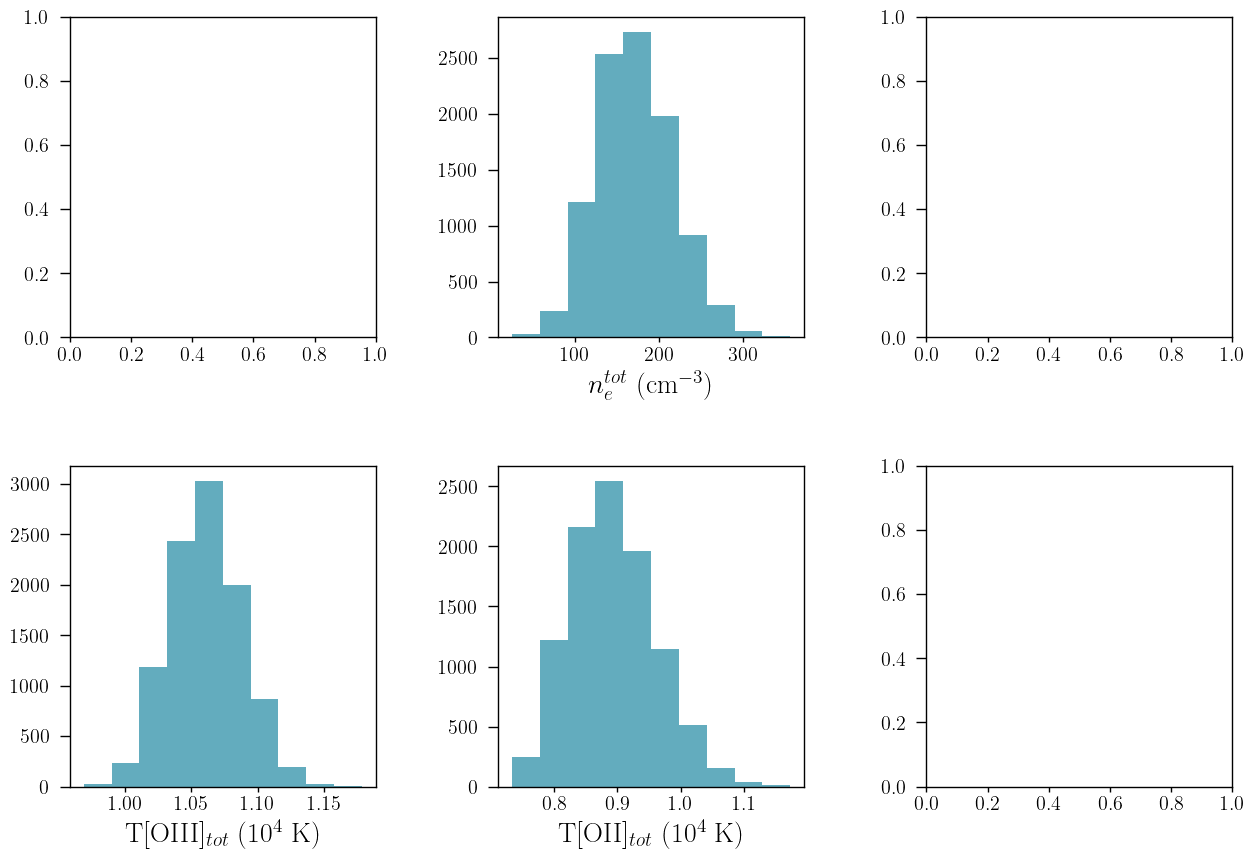

In [17]:
texPlot('on')
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

#axs[0, 0].scatter(t_OIII_nar, t_OIII_brd, s=1, color=cr[2])
#axs[0, 0].set_xlabel(r'T[OIII]$_{narrow}$ (10$^{4}$ K)')
#axs[0, 0].set_ylabel(r'T[OIII]$_{broad}$ (10$^{4}$ K)')

axs[1, 0].hist(T_OIII, color=cr[2])
axs[1, 0].set_xlabel(r'T[OIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 1].hist(el_density, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{tot}$ (cm$^{-3}$)')

axs[1, 1].hist(T_OII, color=cr[2])
axs[1, 1].set_xlabel(r'T[OII]$_{tot}$ (10$^{4}$ K)')

#axs[1, 2].hist(T_SIII, color=cr[2])
#axs[1, 2].set_xlabel(r'T[SIII]$_{tot}$ (10$^{4}$ K)')
#
#axs[0, 2].hist(T_NII, color=cr[2])
#axs[0, 2].set_xlabel(r'T[NII]$_{tot}$ (10$^{4}$ K)')

In [18]:
temden_dict = {'galname': galname,
               'tOIII': np.percentile(T_OIII, 50),
               'tOIII_16': np.percentile(T_OIII, 16),
               'tOIII_84': np.percentile(T_OIII, 84),
               'tOII': np.percentile(T_OII, 50),
               'tOII_16': np.percentile(T_OII, 16),
               'tOII_84': np.percentile(T_OII, 84),
               'ne': np.percentile(el_density, 50),
               'ne_16': np.percentile(el_density, 16),
               'ne_84': np.percentile(el_density, 84),
               'tNII': None,
               'tNII_16': None,
               'tNII_84': None,
               'tSIII': None,
               'tSIII_16': None,
               'tSIII_84': None,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured_final.csv')

Existent catalog (.csv) file.
Existent data for J2212, overwriting...
Done.


In [19]:
temden_dict = {'galname': galname,
               'tOIII': np.nanpercentile(T_OIII, 50),
               'tOIII_16': np.nanpercentile(T_OIII, 16),
               'tOIII_84': np.nanpercentile(T_OIII, 84),
               'tOII': np.nanpercentile(T_OII, 50),
               'tOII_16': np.nanpercentile(T_OII, 16),
               'tOII_84': np.nanpercentile(T_OII, 84),
               'tOII_G92': np.nanpercentile(T_OII_G92, 50),
               'tOII_G92_16': np.nanpercentile(T_OII_G92, 16),
               'tOII_G92_84': np.nanpercentile(T_OII_G92, 84),
               'tOII_tw': np.nanpercentile(T_OII_tw, 50),
               'tOII_tw_16': np.nanpercentile(T_OII_tw, 16),
               'tOII_tw_84': np.nanpercentile(T_OII_tw, 84)
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated_final.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


# Abundances

In [20]:
# OXYGEN MEASURED

log_Oplus_H_tot = single_log_OH(chains['[OII]3729'], chains['[OII]3726'], chains['Hb'], T_OII, el_density)
log_O2plus_H_tot = double_log_OH(chains['[OIII]5007'], chains['[OIII]4959'], chains['Hb'], T_OIII)

O2plus_H_tot = 10**(log_O2plus_H_tot - 12)
Oplus_H_tot = 10**(log_Oplus_H_tot - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) #* ICF_Oxygen
log_OH_tot = upy.log10(O_H_tot) + 12

In [21]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(chains['[OIII]5007'], chains['[OIII]4959'], chains['Hb'], T_OIII)
log_Oplus_H_G92 = single_log_OH(chains['[OII]3729'], chains['[OII]3726'], chains['Hb'], T_OII_G92, el_density)

O2plus_H_G92 = 10**(log_O2plus_H_G92 - 12)
Oplus_H_G92 = 10**(log_Oplus_H_G92 - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) #* ICF_Oxygen
log_OH_G92 = upy.log10(O_H_G92) + 12

In [22]:
# OXYGEN THIS WORK

log_O2plus_H_tw = double_log_OH(chains['[OIII]5007'], chains['[OIII]4959'], chains['Hb'], T_OIII)
log_Oplus_H_tw = single_log_OH(chains['[OII]3729'], chains['[OII]3726'], chains['Hb'], T_OII_tw, el_density)

O2plus_H_tw = 10**(log_O2plus_H_tw - 12)
Oplus_H_tw = 10**(log_Oplus_H_tw - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tw = (O2plus_H_tw + Oplus_H_tw) #* ICF_Oxygen
log_OH_tw = upy.log10(O_H_tw) + 12

In [23]:
# SULFUR

#log_Splus_H_tot = single_log_S(chains['[SII]6730'], chains['[SII]6716'], chains['Hb'], T_OII)
#log_S2plus_H_tot = double_log_S(chains['[SIII]9532'], chains['[SIII]9069'], chains['Hb'], T_SIII)
#
#S2plus_H_tot = 10**(log_S2plus_H_tot - 12)
#Splus_H_tot = 10**(log_Splus_H_tot - 12)
#
#ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)
#
#S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
#log_SH_tot = upy.log10(S_H_tot) + 12

In [24]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(chains['[NII]6584'], chains['[NII]6548'], chains['Hb'], T_OII)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = upy.log10(N_H_tot) + 12

In [25]:
# Nitrogen-to-Oxygen ratio

log_NO_tot = log_NO(chains['[NII]6584'], chains['[OII]3729'], chains['[OII]3726'], T_OII)

In [26]:
# NEON

log_Ne2plus_H_tot = log_Ne_12(chains['[NeIII]3868'], chains['Hb'], T_OIII)

Ne2plus_H_tot = 10**(log_Ne2plus_H_tot - 12)

ICF_Neon = ICF_Ne(O2plus_H_tot, Oplus_H_tot)

Ne_H_tot = Ne2plus_H_tot * ICF_Neon
log_NeH_tot = upy.log10(Ne_H_tot) + 12

In [27]:
# ARGON

#log_Ar2plus_H_tot = double_log_Ar(chains['[ArIII]7135'], chains['Hb'], T_SIII)
#log_Ar3plus_H_tot = triple_log_Ar(chains['[ArIV]4740'], chains['Hb'], T_OIII)
#
#Ar2plus_H_tot = 10**(log_Ar2plus_H_tot - 12)
#Ar3plus_H_tot = 10**(log_Ar3plus_H_tot - 12)
#
#ICF_Argon = ICF_double_triple_Ar(O2plus_H_tot, Oplus_H_tot)
#
#Ar_H_tot = (Ar2plus_H_tot + Ar3plus_H_tot) * ICF_Argon
#log_ArH_tot = upy.log10(Ar_H_tot) + 12

In [28]:
# IRON

log_Fe2plus_H_tot = log_Fe_12(chains['[FeIII]4658'], chains['Hb'], T_OIII)

Fe2plus_H_tot = 10**(log_Fe2plus_H_tot - 12)

ICF_Iron = ICF_Fe(O2plus_H_tot, Oplus_H_tot)

Fe_H_tot = Fe2plus_H_tot * ICF_Iron
log_FeH_tot = upy.log10(Fe_H_tot) + 12

In [29]:
# ionization parameter

q = log_q(chains['[OIII]5007'], chains['[OII]3726'], log_OH_tot)
U = log_q(chains['[OIII]5007'], chains['[OII]3726'], log_OH_tot, U=True)

Text(0.5, 0, 'log(U)')

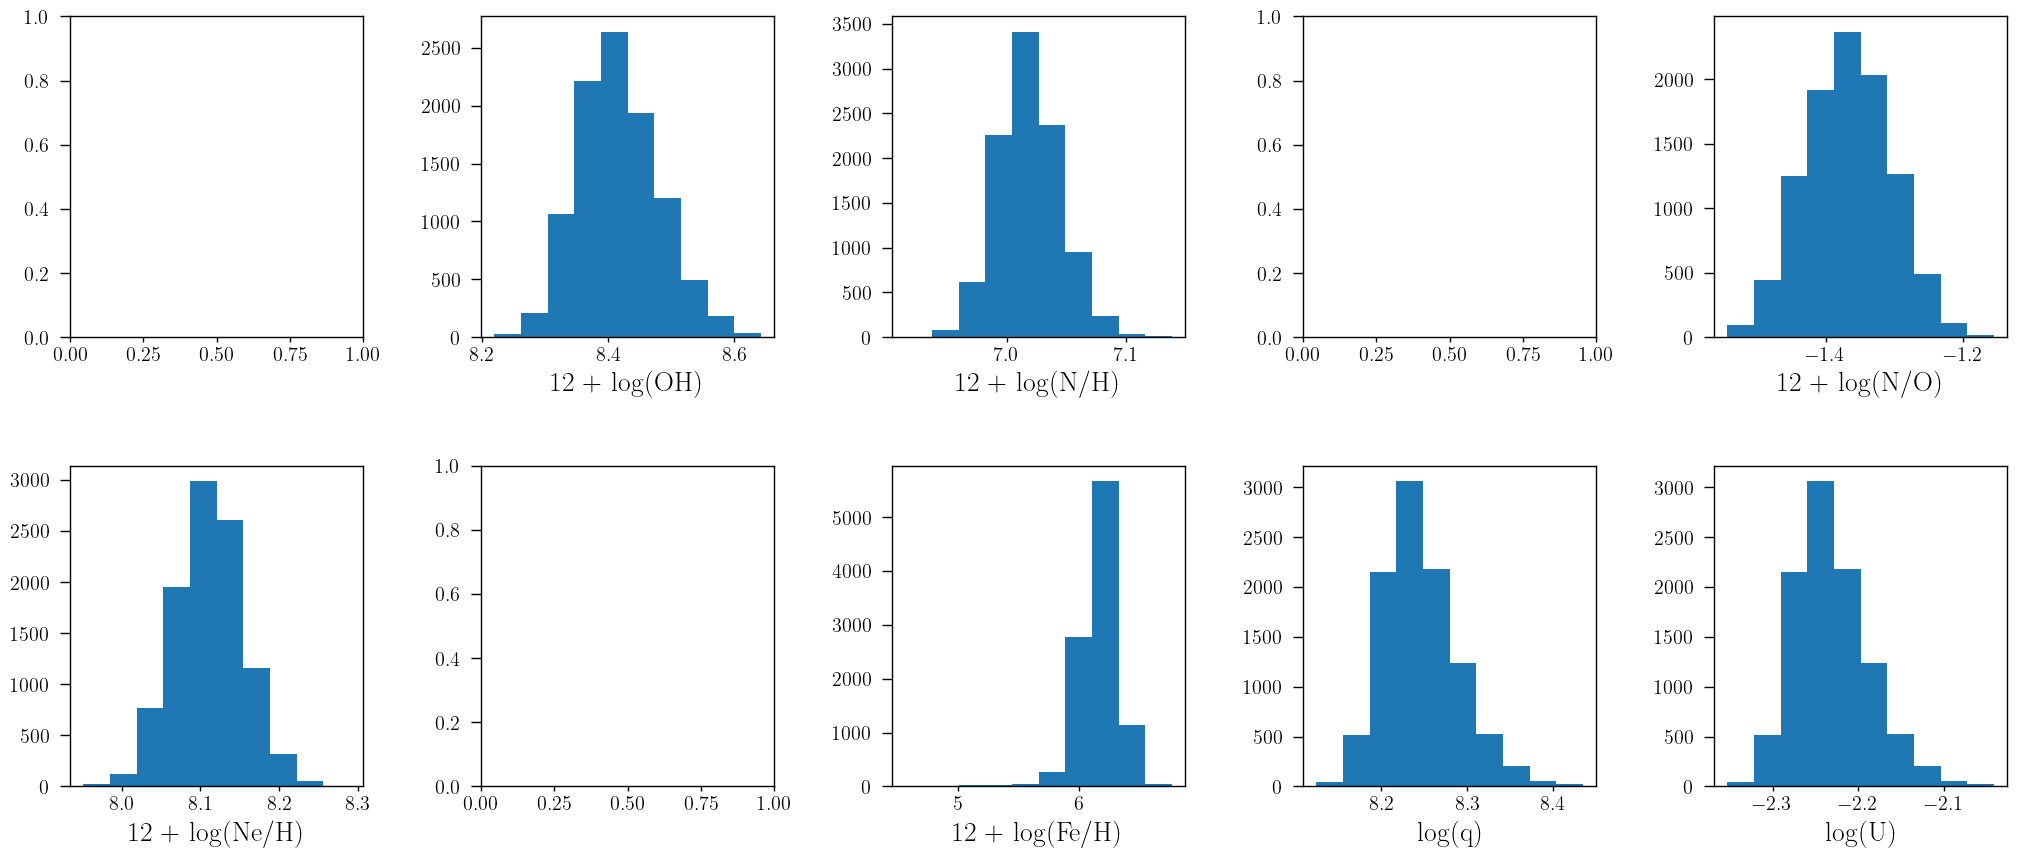

In [30]:
texPlot('on')
fig, axs = plt.subplots(2, 5)
fig.set_size_inches((25, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

#axs[0, 0].hist(y)
#axs[0, 0].set_xlabel('He/H')
axs[0, 1].hist(log_OH_tot)
axs[0, 1].set_xlabel('12 + log(OH)')
axs[0, 2].hist(log_NH_tot)
axs[0, 2].set_xlabel('12 + log(N/H)')
#axs[0, 3].hist(log_SH_tot)
#axs[0, 3].set_xlabel('12 + log(S/H)')
axs[0, 4].hist(log_NO_tot)
axs[0, 4].set_xlabel('12 + log(N/O)')

axs[1, 0].hist(log_NeH_tot)
axs[1, 0].set_xlabel('12 + log(Ne/H)')
#axs[1, 1].hist(log_ArH_tot)
#axs[1, 1].set_xlabel('12 + log(Ar/H)')
axs[1, 2].hist(log_FeH_tot)
axs[1, 2].set_xlabel('12 + log(Fe/H)')
axs[1, 3].hist(q)
axs[1, 3].set_xlabel('log(q)')
axs[1, 4].hist(U)
axs[1, 4].set_xlabel('log(U)')

In [31]:
abundance_dict = {'galname': galname,
                  'He/H': None,
                  'He/H_16': None,
                  'He/H_84': None,
                  'log_OH': np.nanpercentile(log_OH_tot, 50),
                  'log_OH_16': np.nanpercentile(log_OH_tot, 16),
                  'log_OH_84': np.nanpercentile(log_OH_tot, 84),
                  'log_SH': None,
                  'log_SH_16': None,
                  'log_SH_84': None,
                  'log_NH': np.nanpercentile(log_NH_tot, 50),
                  'log_NH_16': np.nanpercentile(log_NH_tot, 16),
                  'log_NH_84': np.nanpercentile(log_NH_tot, 84),
                  'log_NO': np.nanpercentile(log_NO_tot, 50),
                  'log_NO_16': np.nanpercentile(log_NO_tot, 16),
                  'log_NO_84': np.nanpercentile(log_NO_tot, 84),
                  'log_NeH': np.nanpercentile(log_NeH_tot, 50),
                  'log_NeH_16': np.nanpercentile(log_NeH_tot, 16),
                  'log_NeH_84': np.nanpercentile(log_NeH_tot, 84),
                  'log_ArH': None,
                  'log_ArH_16': None,
                  'log_ArH_84': None,
                  'log_FeH': np.nanpercentile(log_FeH_tot, 50),
                  'log_FeH_16': np.nanpercentile(log_FeH_tot, 16),
                  'log_FeH_84': np.nanpercentile(log_FeH_tot, 84),
                  'log_q': np.nanpercentile(q, 50),
                  'log_q_16': np.nanpercentile(q, 16),
                  'log_q_84': np.nanpercentile(q, 84),
                  'log_U': np.nanpercentile(U, 50),
                  'log_U_16': np.nanpercentile(U, 16),
                  'log_U_84': np.nanpercentile(U, 84)
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured_final.csv')

Existent catalog (.csv) file.
Existent data for J2212, overwriting...
Done.


In [32]:
abundance_dict = {'galname': galname,
                  'log_OH_G92': np.nanpercentile(log_OH_G92, 50),
                  'log_OH_G92_16': np.nanpercentile(log_OH_G92, 16),
                  'log_OH_G92_84': np.nanpercentile(log_OH_G92, 84),
                  'log_OH_tw': np.nanpercentile(log_OH_tw, 50),
                  'log_OH_tw_16': np.nanpercentile(log_OH_tw, 16),
                  'log_OH_tw_84': np.nanpercentile(log_OH_tw, 84)
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated_final.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


# ---------------------------------------------------------------------------------------

In [4]:
t_OIII_nar = TO3(chains['[OIII]5007_nar'].to_numpy(), chains['[OIII]4959_nar'].to_numpy(), chains['[OIII]4363_nar'].to_numpy())
t_OIII_brd = TO3(chains['[OIII]5007_brd'].to_numpy(), chains['[OIII]4959_brd'].to_numpy(), chains['[OIII]4363_brd'].to_numpy())
t_OIII_tot = TO3(chains['[OIII]5007'].to_numpy()    , chains['[OIII]4959'].to_numpy()    , chains['[OIII]4363'].to_numpy())

O2_H_nar = 10**(double_log_OH(chains['[OIII]5007_nar'].to_numpy(), chains['[OIII]4959_nar'].to_numpy(), chains['Hb_nar'].to_numpy(), t_OIII_nar) - 12)
O2_H_brd = 10**(double_log_OH(chains['[OIII]5007_brd'].to_numpy(), chains['[OIII]4959_brd'].to_numpy(), chains['Hb_brd'].to_numpy(), t_OIII_brd) - 12)
O2_H_tot = 10**(double_log_OH(chains['[OIII]5007'].to_numpy()    , chains['[OIII]4959'].to_numpy()    , chains['Hb'].to_numpy()    , t_OIII_tot) - 12)

IO2_R_nar = 9.36 * (t_OIII_nar**0.44) * O2_H_nar * chains['Hb_nar'].to_numpy()
IO2_R_brd = 9.36 * (t_OIII_brd**0.44) * O2_H_brd * chains['Hb_brd'].to_numpy()
IO2_R_tot = 9.36 * (t_OIII_tot**0.44) * O2_H_tot * chains['Hb'].to_numpy()    

den_nar = ne(chains['[SII]6730_nar'].to_numpy(), chains['[SII]6716_nar'].to_numpy(), t_OIII_nar)
den_brd = ne(chains['[SII]6730_brd'].to_numpy(), chains['[SII]6716_brd'].to_numpy(), t_OIII_brd)
den_tot = ne(chains['[SII]6730'].to_numpy()    , chains['[SII]6716'].to_numpy()    , t_OIII_tot)

t_OII_nar = TO2(chains['[OII]7330_nar'].to_numpy(), chains['[OII]7319_nar'].to_numpy(), chains['[OII]3729_nar'].to_numpy(), chains['[OII]3726_nar'].to_numpy(), den_nar, IO2_R_nar)
t_OII_brd = TO2(chains['[OII]7330_brd'].to_numpy(), chains['[OII]7319_brd'].to_numpy(), chains['[OII]3729_brd'].to_numpy(), chains['[OII]3726_brd'].to_numpy(), den_brd, IO2_R_brd)
t_OII_tot = TO2(chains['[OII]7330'].to_numpy()    , chains['[OII]7319'].to_numpy()    , chains['[OII]3729'].to_numpy()    , chains['[OII]3726'].to_numpy()    , den_tot, IO2_R_tot)

# Garnett
t_OII_tot_garnett = ((0.7 * (t_OIII_tot * 10)) + 0.3) / 10

# PM17 DENSITY DEPENDENT
#t_OII_tot_PM = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))

# Linear
t_OII_tot_lin = (slope_o3o2 * t_OIII_tot) + intercept_o3o2

# Non-linear
#t_OII_tot_nlin = (2.4 / ((t_OIII_tot**-1) + 1.5))

# Polynomial
#t_OII_tot_poly = (-6.6 * t_OIII_tot) + (15.1 * (t_OIII_tot**2)) + (-8.3 * (t_OIII_tot**3)) + (0.69 * (t_OIII_tot**5))

# Square root
#t_OII_tot_sqrt = 0.3 + (0.66 * np.sqrt(t_OIII_tot))

/home/benjamin/Documents/analogs/magE/functions.py:807: RuntimeWarning: invalid value encountered in log10
  s1 = 6.1868 + (1.2491 / th) - (0.5816 * np.log10(th))
/tmp/ipykernel_329837/530866999.py:10: RuntimeWarning: invalid value encountered in power
  IO2_R_brd = 9.36 * (t_OIII_brd**0.44) * O2_H_brd * chains['Hb_brd'].to_numpy()


Text(0.5, 0, 'T[OII]$_{tot}$ (10$^{4}$ K)')

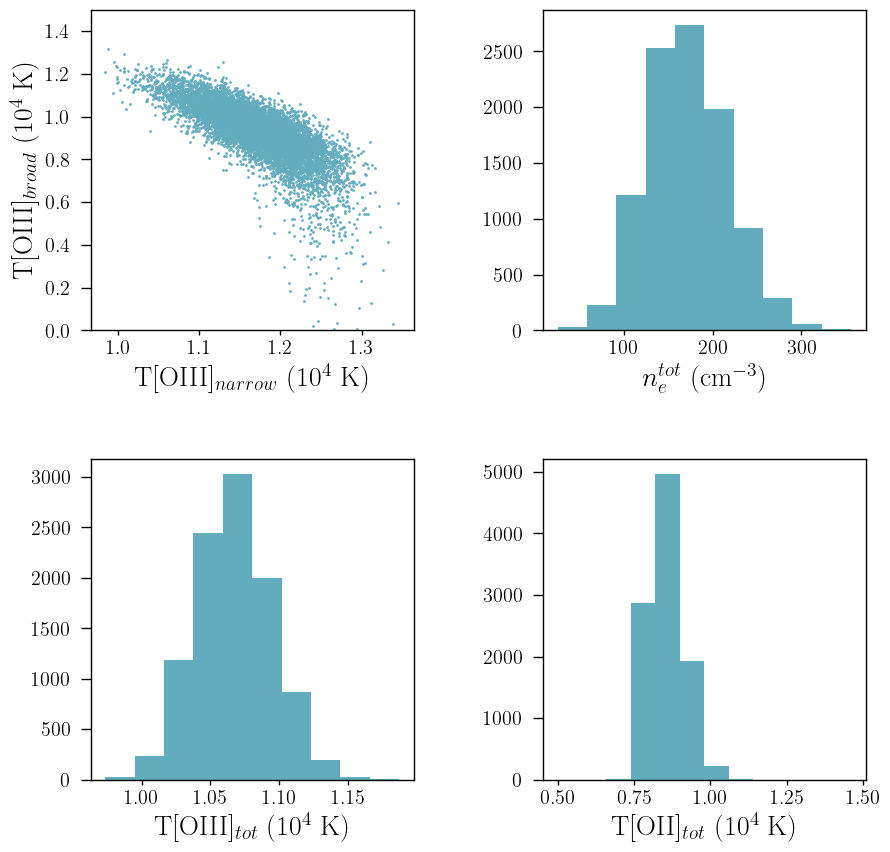

In [5]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].scatter(t_OIII_nar, t_OIII_brd, s=1, color=cr[2])
axs[0, 0].set_xlabel(r'T[OIII]$_{narrow}$ (10$^{4}$ K)')
axs[0, 0].set_ylabel(r'T[OIII]$_{broad}$ (10$^{4}$ K)')
axs[0, 0].set_ylim(0, 1.5)

axs[1, 0].hist(t_OIII_tot, color=cr[2])
axs[1, 0].set_xlabel(r'T[OIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 1].hist(den_tot, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{tot}$ (cm$^{-3}$)')

axs[1, 1].hist(t_OII_tot, color=cr[2], bins=np.arange(0.5, 1.5, 0.08))
axs[1, 1].set_xlabel(r'T[OII]$_{tot}$ (10$^{4}$ K)')

# Using Temperature relations derived by me

In [6]:
t_OIII_nar_mean = np.nanpercentile(t_OIII_nar, 50)
t_OIII_nar_16 = np.nanpercentile(t_OIII_nar, 16)
t_OIII_nar_84 = np.nanpercentile(t_OIII_nar, 84)

t_OIII_brd_mean = np.nanpercentile(t_OIII_brd, 50)
t_OIII_brd_16 = np.nanpercentile(t_OIII_brd, 16)
t_OIII_brd_84 = np.nanpercentile(t_OIII_brd, 84)

t_OIII_tot_mean = np.nanpercentile(t_OIII_tot, 50)
t_OIII_tot_16 = np.nanpercentile(t_OIII_tot, 16)
t_OIII_tot_84 = np.nanpercentile(t_OIII_tot, 84)

# Measured by me
t_OII = np.nanpercentile(t_OII_tot, 50)
t_OII_16 = np.nanpercentile(t_OII_tot, 16)
t_OII_84 = np.nanpercentile(t_OII_tot, 84)

# Photoionization models
t_OII_garnett = ((0.7 * (t_OIII_tot_mean * 10)) + 0.3) / 10
t_OII_garnett_16 = ((0.7 * (t_OIII_tot_16 * 10)) + 0.3) / 10
t_OII_garnett_84 = ((0.7 * (t_OIII_tot_84 * 10)) + 0.3) / 10

# Using PM
#t_OII_PM = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_mean**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))
#t_OII_PM_16 = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_16**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))
#t_OII_PM_84 = (1.2 + (0.002 * 300) + (4.2 / 300)) / ((t_OIII_tot_84**-1) + 0.08 + (0.003 * 300) + (2.5 / 300))

# Linear
t_OII_lin = (slope_o3o2 * t_OIII_tot_mean) + intercept_o3o2
t_OII_lin_16 = (slope_o3o2 * t_OIII_tot_16) + intercept_o3o2
t_OII_lin_84 = (slope_o3o2 * t_OIII_tot_84) + intercept_o3o2

# Non-linear
#t_OII_nlin = (2.4 / ((t_OIII_tot_mean**-1) + 1.5))
#t_OII_nlin_16 = (2.4 / ((t_OIII_tot_16**-1) + 1.5))
#t_OII_nlin_84 = (2.4 / ((t_OIII_tot_84**-1) + 1.5))

# Polynomial
#t_OII_poly = (-6.6 * t_OIII_tot_mean) + (15.1 * (t_OIII_tot_mean**2)) + (-8.3 * (t_OIII_tot_mean**3)) + (0.69 * (t_OIII_tot_mean**5))
#t_OII_poly_16 = (-6.6 * t_OIII_tot_16) + (15.1 * (t_OIII_tot_16**2)) + (-8.3 * (t_OIII_tot_16**3)) + (0.69 * (t_OIII_tot_16**5))
#t_OII_poly_84 = (-6.6 * t_OIII_tot_84) + (15.1 * (t_OIII_tot_84**2)) + (-8.3 * (t_OIII_tot_84**3)) + (0.69 * (t_OIII_tot_84**5))

# Square-root
t_OII_sqrt = 0.3 + (0.66 * np.sqrt(t_OIII_tot_mean))
t_OII_sqrt_16 = 0.3 + (0.66 * np.sqrt(t_OIII_tot_16))
t_OII_sqrt_84 = 0.3 + (0.66 * np.sqrt(t_OIII_tot_84))

density = np.nanpercentile(den_tot, 50)
density_16 = np.nanpercentile(den_tot, 16)
density_84 = np.nanpercentile(den_tot, 84)

In [132]:
temden_dict = {'galname': galname,
               'tOIII_nar': t_OIII_nar_mean,
               'tOIII_nar_16': t_OIII_nar_16,
               'tOIII_nar_84': t_OIII_nar_84,
               'tOIII_brd': t_OIII_brd_mean,
               'tOIII_brd_16': t_OIII_brd_16,
               'tOIII_brd_84': t_OIII_brd_84,
               'tOIII_tot': t_OIII_tot_mean,
               'tOIII_tot_16': t_OIII_tot_16,
               'tOIII_tot_84': t_OIII_tot_84,
               'tOII': t_OII,
               'tOII_16': t_OII_16,
               'tOII_84': t_OII_84,
               'tOII_G92': t_OII_garnett,
               'tOII_G92_16': t_OII_garnett_16,
               'tOII_G92_84': t_OII_garnett_84,
               #'tOII_PM': t_OII_PM,
               #'tOII_PM_16': t_OII_PM_16,
               #'tOII_PM_84': t_OII_PM_84,
               #'tOII_lin': t_OII_lin,
               #'tOII_lin_16': t_OII_lin_16,
               #'tOII_lin_84': t_OII_lin_84,
               #'tOII_nlin': t_OII_nlin,
               #'tOII_nlin_16': t_OII_nlin_16,
               #'tOII_nlin_84': t_OII_nlin_84,
               #'tOII_poly': t_OII_poly,
               #'tOII_poly_16': t_OII_poly_16,
               #'tOII_poly_84': t_OII_poly_84,
               #'tOII_sqrt': t_OII_sqrt,
               #'tOII_sqrt_16': t_OII_sqrt_16,
               #'tOII_sqrt_84': t_OII_sqrt_84,
               'ne': density,
               'ne_16': density_16,
               'ne_84': density_84,
               'tNII': None,
               'tNII_16': None,
               'tNII_84': None,
               'tSIII': None,
               'tSIII_16': None,
               'tSIII_84': None,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_measured.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


In [7]:
temden_dict = {'galname': galname,
               'tOIII_tot': t_OIII_tot_mean,
               'tOIII_tot_16': t_OIII_tot_16,
               'tOIII_tot_84': t_OIII_tot_84,
               'tOII': t_OII,
               'tOII_16': t_OII_16,
               'tOII_84': t_OII_84,
               'tOII_G92': t_OII_garnett,
               'tOII_G92_16': t_OII_garnett_16,
               'tOII_G92_84': t_OII_garnett_84,
               'tOII_lin': t_OII_lin,
               'tOII_lin_16': t_OII_lin_16,
               'tOII_lin_84': t_OII_lin_84
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_estimated.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


# Abundances

### No HeII4686 line detected

In [8]:
# OXYGEN MEASURED

log_O2plus_H_tot = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_tot = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot, den_tot)

O2plus_H_tot = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_tot = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot, den_tot) - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_tot = (O2plus_H_tot + Oplus_H_tot) #* ICF_Oxygen
log_OH_tot = np.log10(O_H_tot) + 12

In [9]:
# OXYGEN GARNETT

log_O2plus_H_G92 = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_G92 = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_garnett, den_tot)

O2plus_H_G92 = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_G92 = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_garnett, den_tot) - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_G92 = (O2plus_H_G92 + Oplus_H_G92) #* ICF_Oxygen
log_OH_G92 = np.log10(O_H_G92) + 12

In [10]:
# OXYGEN lin

log_O2plus_H_lin = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
log_Oplus_H_lin = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_lin, den_tot)

O2plus_H_lin = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
Oplus_H_lin = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_lin, den_tot) - 12)

#ICF_Oxygen = 1 + (y2_plus / y_plus)

O_H_lin = (O2plus_H_lin + Oplus_H_lin) #* ICF_Oxygen
log_OH_lin = np.log10(O_H_lin) + 12

In [13]:
# OXYGEN PM

#log_O2plus_H_PM = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
#log_Oplus_H_PM = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_PM, den_tot)
#
#O2plus_H_PM = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
#Oplus_H_PM = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_PM, den_tot) - 12)
#
##ICF_Oxygen = 1 + (y2_plus / y_plus)
#
#O_H_PM = (O2plus_H_PM + Oplus_H_PM) #* ICF_Oxygen
#log_OH_PM = np.log10(O_H_PM) + 12

In [15]:
# OXYGEN nlin

#log_O2plus_H_nlin = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
#log_Oplus_H_nlin = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_nlin, den_tot)
#
#O2plus_H_nlin = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
#Oplus_H_nlin = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_nlin, den_tot) - 12)
#
##ICF_Oxygen = 1 + (y2_plus / y_plus)
#
#O_H_nlin = (O2plus_H_nlin + Oplus_H_nlin) #* ICF_Oxygen
#log_OH_nlin = np.log10(O_H_nlin) + 12

In [16]:
# OXYGEN poly

#log_O2plus_H_poly = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
#log_Oplus_H_poly = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_poly, den_tot)
#
#O2plus_H_poly = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
#Oplus_H_poly = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_poly, den_tot) - 12)
#
##ICF_Oxygen = 1 + (y2_plus / y_plus)
#
#O_H_poly = (O2plus_H_poly + Oplus_H_poly) #* ICF_Oxygen
#log_OH_poly = np.log10(O_H_poly) + 12

In [17]:
# OXYGEN sqrt

#log_O2plus_H_sqrt = double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot)
#log_Oplus_H_sqrt = single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_sqrt, den_tot)
#
#O2plus_H_sqrt = 10**(double_log_OH(chains['[OIII]5007'].to_numpy(), chains['[OIII]4959'].to_numpy(), chains['Hb'].to_numpy(), t_OIII_tot) - 12)
#Oplus_H_sqrt = 10**(single_log_OH(chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot_sqrt, den_tot) - 12)
#
##ICF_Oxygen = 1 + (y2_plus / y_plus)
#
#O_H_sqrt = (O2plus_H_sqrt + Oplus_H_sqrt) #* ICF_Oxygen
#log_OH_sqrt = np.log10(O_H_sqrt) + 12

In [136]:
# SULFUR

#log_S2plus_H_tot = double_log_S_noline(chains['[SIII]6312'].to_numpy(), chains['Hb'].to_numpy(), t_SIII_tot_temprel)
#log_Splus_H_tot = single_log_S(chains['[SII]6730'].to_numpy(), chains['[SII]6716'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot)
#
#S2plus_H_tot = 10**(double_log_S_noline(chains['[SIII]6312'].to_numpy(), chains['Hb'].to_numpy(), t_SIII_tot_temprel) - 12)
#Splus_H_tot = 10**(single_log_S(chains['[SII]6730'].to_numpy(), chains['[SII]6716'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot) - 12)
#
#ICF_Sulfur = ICF_S(O2plus_H_tot, Oplus_H_tot, alpha=3.27)
#
#S_H_tot = (S2plus_H_tot + Splus_H_tot) * ICF_Sulfur
#log_SH_tot = np.log10(S_H_tot) + 12

In [11]:
# NITROGEN

log_Nplus_H_tot = log_NH_12(chains['[NII]6584'].to_numpy(), chains['[NII]6548'].to_numpy(), chains['Hb'].to_numpy(), t_OII_tot)

Nplus_H_tot = 10**(log_Nplus_H_tot - 12)

ICF_Nitrogen = O_H_tot / Oplus_H_tot 

N_H_tot = Nplus_H_tot * ICF_Nitrogen
log_NH_tot = np.log10(N_H_tot) + 12

In [12]:
# Nitrogen-to-Oxygen ratio
log_NO_tot = log_NO(chains['[NII]6584'].to_numpy(), chains['[OII]3729'].to_numpy(), chains['[OII]3726'].to_numpy(), t_OII_tot)

Text(0.5, 0, '12 + log(N/O)')

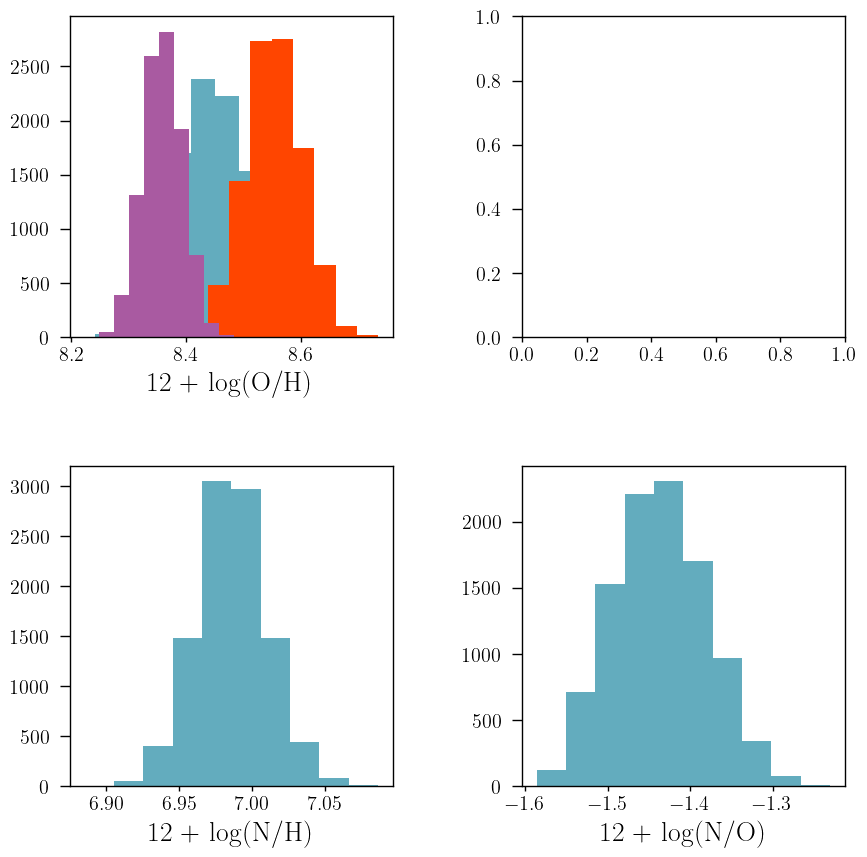

In [13]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].hist(log_OH_tot, color=cr[2])
axs[0, 0].hist(log_OH_G92, color='Orangered')
#axs[0, 0].hist(log_OH_PM, color='Pink')
axs[0, 0].hist(log_OH_lin, color=cz[1])
#axs[0, 0].hist(log_OH_nlin, color='Green')
#axs[0, 0].hist(log_OH_poly, color='Blue')
#axs[0, 0].hist(log_OH_sqrt, color='Gray')
axs[0, 0].set_xlabel(r'12 + log(O/H)')

#axs[0, 1].hist(log_SH_tot, color=cr[2])
#axs[0, 1].set_xlabel(r'12 + log(S/H)')

axs[1, 0].hist(log_NH_tot, color=cr[2])
axs[1, 0].set_xlabel(r'12 + log(N/H)')

axs[1, 1].hist(log_NO_tot, color=cr[2])
axs[1, 1].set_xlabel(r'12 + log(N/O)')


In [14]:
#He_tot_mean = np.nanpercentile(y, 50)
#He_tot_16 = np.nanpercentile(y, 16)
#He_tot_84 = np.nanpercentile(y, 84)

log_OH_tot_mean = np.nanpercentile(log_OH_tot, 50)
log_OH_tot_16 = np.nanpercentile(log_OH_tot, 16)
log_OH_tot_84 = np.nanpercentile(log_OH_tot, 84)

log_OH_G92_mean = np.nanpercentile(log_OH_G92, 50)
log_OH_G92_16 = np.nanpercentile(log_OH_G92, 16)
log_OH_G92_84 = np.nanpercentile(log_OH_G92, 84)

#log_OH_PM_mean = np.nanpercentile(log_OH_PM, 50)
#log_OH_PM_16 = np.nanpercentile(log_OH_PM, 16)
#log_OH_PM_84 = np.nanpercentile(log_OH_PM, 84)

log_OH_lin_mean = np.nanpercentile(log_OH_lin, 50)
log_OH_lin_16 = np.nanpercentile(log_OH_lin, 16)
log_OH_lin_84 = np.nanpercentile(log_OH_lin, 84)

#log_OH_nlin_mean = np.nanpercentile(log_OH_nlin, 50)
#log_OH_nlin_16 = np.nanpercentile(log_OH_nlin, 16)
#log_OH_nlin_84 = np.nanpercentile(log_OH_nlin, 84)

#log_OH_poly_mean = np.nanpercentile(log_OH_poly, 50)
#log_OH_poly_16 = np.nanpercentile(log_OH_poly, 16)
#log_OH_poly_84 = np.nanpercentile(log_OH_poly, 84)

#log_OH_sqrt_mean = np.nanpercentile(log_OH_sqrt, 50)
#log_OH_sqrt_16 = np.nanpercentile(log_OH_sqrt, 16)
#log_OH_sqrt_84 = np.nanpercentile(log_OH_sqrt, 84)

#log_SH_tot_mean = np.nanpercentile(log_SH_tot, 50)
#log_SH_tot_16 = np.nanpercentile(log_SH_tot, 16)
#log_SH_tot_84 = np.nanpercentile(log_SH_tot, 84)

log_NH_tot_mean = np.nanpercentile(log_NH_tot, 50)
log_NH_tot_16 = np.nanpercentile(log_NH_tot, 16)
log_NH_tot_84 = np.nanpercentile(log_NH_tot, 84)

log_NO_tot_mean = np.nanpercentile(log_NO_tot, 50)
log_NO_tot_16 = np.nanpercentile(log_NO_tot, 16)
log_NO_tot_84 = np.nanpercentile(log_NO_tot, 84)

In [143]:
abundance_dict = {'galname': galname,
               'He/H': None,
               'He/H_16': None,
               'He/H_84': None,
               'log_OH': log_OH_tot_mean,
               'log_OH_16': log_OH_tot_16,
               'log_OH_84': log_OH_tot_84,
               'log_OH_G92': log_OH_G92_mean,
               'log_OH_G92_16': log_OH_G92_16,
               'log_OH_G92_84': log_OH_G92_84,
               #'log_OH_PM': log_OH_PM_mean,
               #'log_OH_PM_16': log_OH_PM_16,
               #'log_OH_PM_84': log_OH_PM_84,
               #'log_OH_lin': log_OH_lin_mean,
               #'log_OH_lin_16': log_OH_lin_16,
               #'log_OH_lin_84': log_OH_lin_84,
               #'log_OH_nlin': log_OH_nlin_mean,
               #'log_OH_nlin_16': log_OH_nlin_16,
               #'log_OH_nlin_84': log_OH_nlin_84,
               #'log_OH_poly': log_OH_poly_mean,
               #'log_OH_poly_16': log_OH_poly_16,
               #'log_OH_poly_84': log_OH_poly_84,
               #'log_OH_sqrt': log_OH_sqrt_mean,
               #'log_OH_sqrt_16': log_OH_sqrt_16,
               #'log_OH_sqrt_84': log_OH_sqrt_84,
               #'log_SH': log_SH_tot_mean,
               #'log_SH_16': log_SH_tot_16,
               #'log_SH_84': log_SH_tot_84,
               'log_NH': log_NH_tot_mean,
               'log_NH_16': log_NH_tot_16,
               'log_NH_84': log_NH_tot_84,
               'log_NO': log_NO_tot_mean,
               'log_NO_16': log_NO_tot_16,
               'log_NO_84': log_NO_tot_84,
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_measured.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


In [15]:
abundance_dict = {'galname': galname,
               'log_OH': log_OH_tot_mean,
               'log_OH_16': log_OH_tot_16,
               'log_OH_84': log_OH_tot_84,
               'log_OH_G92': log_OH_G92_mean,
               'log_OH_G92_16': log_OH_G92_16,
               'log_OH_G92_84': log_OH_G92_84,
               'log_OH_lin': log_OH_lin_mean,
               'log_OH_lin_16': log_OH_lin_16,
               'log_OH_lin_84': log_OH_lin_84
}
abundance_dict_pd = pd.DataFrame(data=abundance_dict, index=[0])
save_catalog(galname, abundance_dict_pd, magePath + '/results/metals/abundance_estimated.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.


# Test for Starlight

(3000.0, 9000.0)

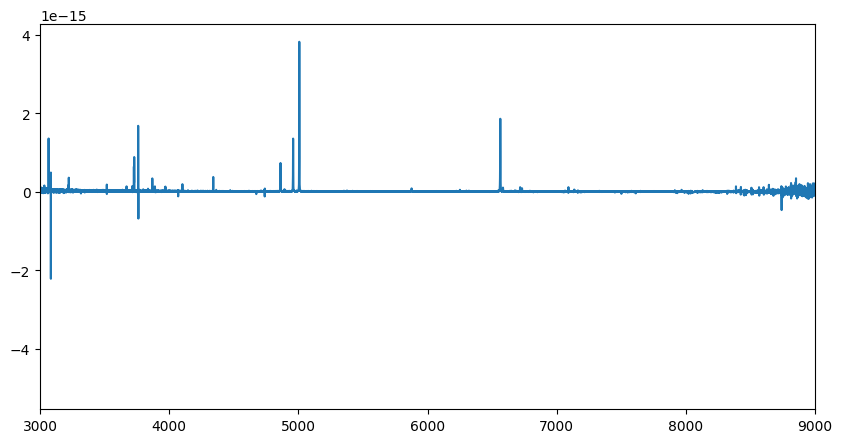

In [18]:
rf_wave = wave / (1 + z_nar_oiii_4959)
plt.figure(figsize=(10, 5))
plt.plot(rf_wave, flux)
plt.xlim(3000, 9000)

In [19]:
import spectres

rf_new_wave = np.arange(3000, 9000, 1)
new_flux, new_err = spectres.spectres(rf_new_wave, rf_wave, flux, err)

mask_flux = (new_flux > 0)

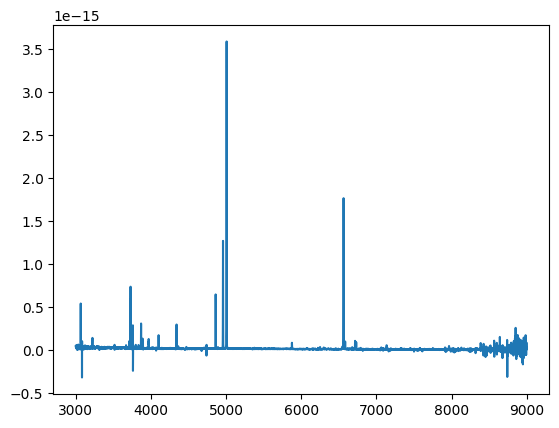

In [20]:
plt.plot(rf_new_wave, new_flux)

In [21]:
mask = False
mask_count = 0
mask_list = []
for line in wave_cat:
    if (wave_cat[line] > 3000) & (wave_cat[line] < 9000):
        sigma_line = (m * (wave_cat[line] * (1 + z_nar_oiii_4959))) + n
        sigma3 = 3 * np.sqrt(((upy.nominal_values(sigma_brd_intrinsic)**2) + (sigma_line**2)))
        lim_sup = wave_cat[line] + sigma3
        lim_inf = wave_cat[line] - sigma3
        mask_list.append([round(lim_inf), round(lim_sup)])
        mask_count += 1
        mask += (rf_new_wave > lim_inf) & (rf_new_wave < lim_sup)

In [22]:
with open('J2212_mask.cxt', 'a', newline='\n') as f:
    f.write(str(mask_count)+'\n')
    for masks in mask_list:
        f.write(str(masks[0])+' '+str(masks[1])+' '+'0\n')

In [27]:
from scipy.signal import medfilt
gpixs = np.where(abs(new_flux[~mask]-medfilt(new_flux[~mask],31))<1e-16)[0]

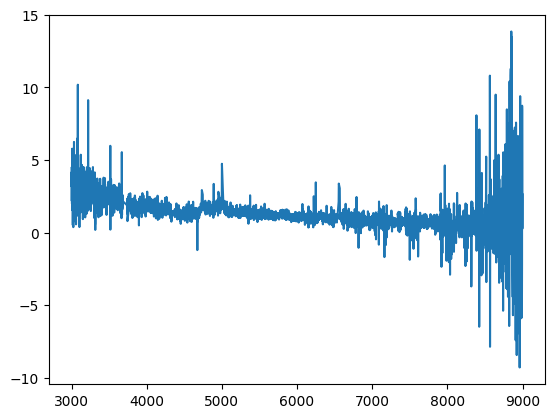

In [28]:
plt.plot(rf_new_wave[~mask][gpixs], new_flux[~mask][gpixs]/1e-17)
#plt.xlim(6500, 7000)
#plt.ylim(1e-16, 3e-16)

In [30]:
from astropy.io import ascii
for i in range(len(rf_new_wave)):
    if i in gpixs:
        flag = 0
    else:
        flag = 99
    spec_str = str(rf_new_wave[i])+' '+str(new_flux[i]/1e-17)+' '+str(new_err[i]/1e-17)+' '+str(flag)+'\n'
    with open('J2212.cxt', 'a', newline='\n') as f:
        f.write(spec_str)

In [31]:
FWHM(sigma_nar_oiii_4959, wave_cat['[OIII]4959'])

118.90581695051276

# After fitting

In [35]:
with open('/home/benjamin/Documents/STARLIGHTv04/J2212/J2212.cxt.sc4.C99.im.CAL.BS', 'r') as bf:
    # limits of lines to read
    line_lims = [531, 6532]
    # To store lines
    lines = []
    for i, line in enumerate(bf):
        # read lines inside limits
        if (i >= line_lims[0]) & (i <= line_lims[1]):
            lines.append(line.strip())
        elif i > 6532:
            # don't read after line 7 to save time
            break
print(lines)

['3000.00    3.45735   2.73867    0.810', '3001.00    2.49018   2.72323    0.843', '3002.00    2.46700   2.71412    0.860', '3003.00    3.24307   2.71062    0.868', '3004.00    1.69160   2.70941    0.955', '3005.00    3.12497   2.70868    0.965', '3006.00    1.54015   2.70801    0.990', '3007.00    2.94545   2.70734    0.966', '3008.00    4.22001   2.70667    0.944', '3009.00    4.48912   2.70600    0.974', '3010.00    2.20989   2.70533    0.925', '3011.00    1.19788   2.70466    0.714', '3012.00    4.03741   2.70399    0.976', '3013.00    2.66183   2.70332    1.023', '3014.00    1.30655   2.70265    1.060', '3015.00    2.52018   2.70198    1.082', '3016.00    2.44585   2.70127    1.092', '3017.00    0.40193   2.70014    1.109', '3018.00    1.08308   2.69709    1.138', '3019.00    2.69435   2.68938    1.490', '3020.00    0.53334   2.67649   -1.000', '3021.00    0.72299   2.66361   -1.000', '3022.00    0.90952   2.65591   -1.000', '3023.00    0.85462   2.65288   -1.000', '3024.00    0.2

In [36]:
wl = []
input_flux = []
best_model = []
for element in lines:
    wl.append(float(element.split()[0]))
    input_flux.append(float(element.split()[1]))
    best_model.append(float(element.split()[2]))

(0.0, 5.0)

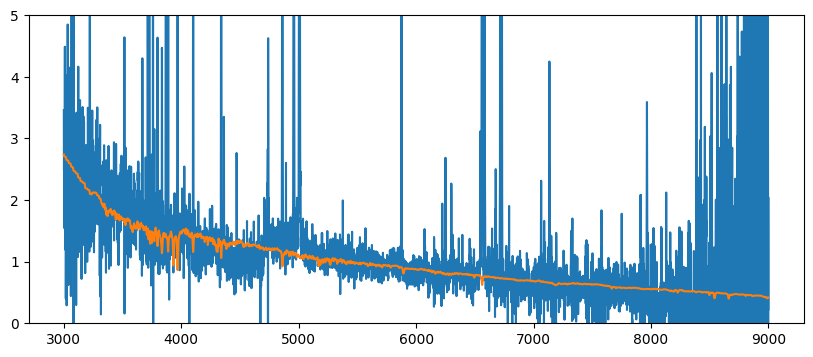

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(wl, input_flux)
plt.plot(wl, best_model)
#plt.xlim(4500, 5000)
plt.ylim(0, 5)

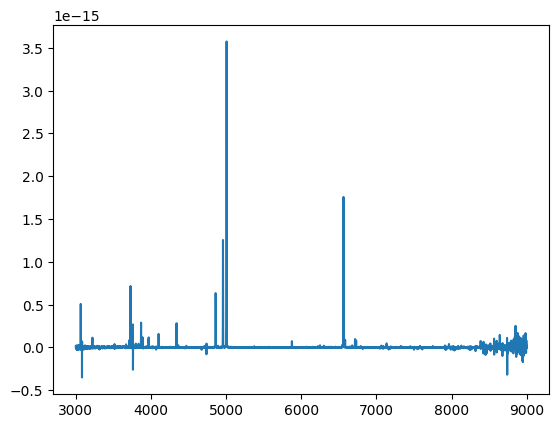

In [38]:
plt.plot(np.array(wl), (np.array(input_flux) - np.array(best_model)) * 1.287464E+00 * 1e-17)

In [39]:
np.log10(8.60332E+03 * 1e-17 * (1/3.826e33) * 4 * np.pi * ((2.666e+27)**2))

9.302851265246284

In [14]:
z_nar_oiii_4959

0.17735090032776832

In [15]:
FWHM(sigma_nar_oiii_4959, wave_cat['[OIII]4959'])

118.90581695051276